<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/baobab_personal_ssot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PERSONAL FINANCE SSOT

BLOCK 01
raw_sms_forwarded_gcb → parsed_sms_gcb

In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 01
# raw_sms_forwarded_gcb → parsed_sms_gcb
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re
from datetime import datetime


# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=1678276995#gid=1678276995"


RAW_TAB = "raw_sms_forwarded_gcb"
OUTPUT_TAB = "parsed_sms_gcb"


# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()


def to_amount(x):
    if not x:
        return None
    s = str(x)
    s = s.replace("GHS", "").replace("GH₵", "")
    s = s.replace(",", "").strip()
    try:
        return float(s)
    except:
        return None


def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean_text(m.group(1)) if m else ""


def parse_direction(text):
    t = text.lower()
    if "credited" in t or "credit" in t:
        return "cash_in"
    if "debited" in t or "debit" in t:
        return "cash_out"
    return "unknown"


def category_hint_from_description(desc):
    d = desc.lower()


    if "bolt" in d:
        return "mobility_or_food_app"
    if "alipay" in d or "alibaba" in d:
        return "international_procurement"
    if "food" in d:
        return "food"
    if "laundry" in d:
        return "laundry"
    if "bundle" in d or "service charge" in d or "charge" in d:
        return "bank_or_service_fee"
    if "wallet" in d:
        return "wallet_transfer"


    return "unclassified"


def merchant_hint_from_description(desc):
    d = desc.lower()


    if "bolt" in d:
        return "Bolt"
    if "alipay" in d:
        return "Alipay"
    if "alibaba" in d:
        return "Alibaba"
    if "mtn" in d:
        return "MTN Mobile Money"


    return ""


# ------------------------------------------------
# 4. LOAD RAW GCB SMS SHEET
# ------------------------------------------------
ws = sh.worksheet(RAW_TAB)


raw_df = get_as_dataframe(
    ws,
    evaluate_formulas=True,
    header=0,
    dtype=str
)


raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]


print(f"Loaded {RAW_TAB}: {len(raw_df)} rows")
display(raw_df.head())


# ------------------------------------------------
# 5. PARSE ROWS
# ------------------------------------------------
parsed_rows = []


for _, row in raw_df.iterrows():
    raw_body = clean_text(row.get("raw_body", ""))
    clean_body = clean_text(row.get("clean_body", "")) or raw_body


    body = clean_body


    account_masked = first_match(r"A/C\s*No[:\s]*([A-Z0-9Xx\*\-]+)", body)


    amount = first_match(
        r"(?:debited|credited)\s*GHS\s*([\d,]+(?:\.\d+)?)",
        body
    )


    fees = first_match(
        r"Fees:\s*GHS\s*([\d,]+(?:\.\d+)?)",
        body
    )


    description = first_match(
        r"Desc:\s*(.*?)(?:Date:|Bal:|$)",
        body,
        flags=re.I
    )


    transaction_datetime = first_match(
        r"Date:\s*([0-9\-]+\s+[0-9:]+)",
        body
    )


    balance_after = first_match(
        r"Bal:\s*GHS\s*([\d,]+(?:\.\d+)?)",
        body
    )


    counterparty_phone = first_match(
        r"\b(0\d{9})\b",
        body
    )


    direction = parse_direction(body)


    amount_ghs = to_amount(amount)
    fees_ghs = to_amount(fees) or 0.0


    if direction == "cash_out":
        total_outflow_ghs = (amount_ghs or 0.0) + fees_ghs
    else:
        total_outflow_ghs = 0.0


    parsed_rows.append({
        "transaction_id": row.get("message_hash") or row.get("gmail_message_id"),
        "source_id": row.get("source_id"),
        "source_sheet": RAW_TAB,
        "source_channel": "sms_forwarded",
        "institution": "GCB",
        "account_masked": account_masked,
        "transaction_datetime": transaction_datetime,
        "email_date": row.get("email_date"),
        "direction": direction,
        "amount_ghs": amount_ghs,
        "fees_ghs": fees_ghs,
        "total_outflow_ghs": total_outflow_ghs,
        "description": description,
        "balance_after_ghs": to_amount(balance_after),
        "counterparty_phone": counterparty_phone,
        "merchant_hint": merchant_hint_from_description(description),
        "category_hint": category_hint_from_description(description),
        "gmail_message_id": row.get("gmail_message_id"),
        "thread_id": row.get("thread_id"),
        "message_hash": row.get("message_hash"),
        "parse_confidence": 0.92,
        "parse_status": "parsed",
        "raw_body": raw_body
    })


parsed_sms_gcb_df = pd.DataFrame(parsed_rows)


# ------------------------------------------------
# 6. WRITE TO GSHEET
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=40)


set_with_dataframe(out_ws, parsed_sms_gcb_df, include_index=False)


# ------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------
print(f"\nWritten to: {OUTPUT_TAB}")
display(parsed_sms_gcb_df)


print("\nCategory hint summary:")
display(
    parsed_sms_gcb_df
    .groupby(["category_hint", "merchant_hint"], dropna=False)
    .size()
    .reset_index(name="count")
)



Loaded raw_sms_forwarded_gcb: 19 rows


,source_id,source_name,source_type,gmail_label,email_date,sender,subject,gmail_message_id,thread_id,raw_body,clean_body,raw_snippet,has_attachments,message_hash,ingested_at,parse_status
0,gcb_sms,GCB SMS,sms_forwarded,ssot/sms_forwarded,01/05/2026 17:34:02,Habib Mohammed Nazif <hmnaz213@gmail.com>,SMS_GCB,19de49ac33c4df95,19de49a8c843e9e8,Hi Mohammed Nazif\r\nYour A/C No:XXXX6465\r\nh...,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,"MIME-Version: 1.0\r\nDate: Fri, 1 May 2026 17:...",False,cexktd0/CWpTQbG/dkQGhg==,01/05/2026 19:06:21,raw_ingested
1,gcb_sms,GCB SMS,sms_forwarded,ssot/sms_forwarded,01/05/2026 15:56:39,Habib Mohammed Nazif <hmnaz213@gmail.com>,SMS_GCB,19de4419ab8f4ec0,19de44175e093759,Hi Mohammed Nazif\r\nYour A/C No:XXXX6465\r\nh...,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,"MIME-Version: 1.0\r\nDate: Fri, 1 May 2026 15:...",False,XqcZozqdMl/JUHJkQTb3rQ==,01/05/2026 19:06:21,raw_ingested
2,gcb_sms,GCB SMS,sms_forwarded,ssot/sms_forwarded,01/05/2026 15:56:18,Habib Mohammed Nazif <hmnaz213@gmail.com>,SMS_GCB,19de4414ace2e91b,19de441263178c42,Hi Mohammed Nazif\r\nYour A/C No:XXXX6465\r\nh...,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,"MIME-Version: 1.0\r\nDate: Fri, 1 May 2026 15:...",False,oTV1OEdPq/qzxuBMVAVwvg==,01/05/2026 19:06:21,raw_ingested
3,gcb_sms,GCB SMS,sms_forwarded,ssot/sms_forwarded,01/05/2026 15:55:54,Habib Mohammed Nazif <hmnaz213@gmail.com>,SMS_GCB,19de440ed468f4c9,19de440c8cb93621,Hi Mohammed Nazif\r\nYour A/C No:XXXX6465\r\nh...,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,"MIME-Version: 1.0\r\nDate: Fri, 1 May 2026 15:...",False,6TgsuM+tGYgzV+w7NmIXkw==,01/05/2026 19:06:22,raw_ingested
4,gcb_sms,GCB SMS,sms_forwarded,ssot/sms_forwarded,01/05/2026 15:55:32,Habib Mohammed Nazif <hmnaz213@gmail.com>,SMS_GCB,19de440962d0c077,19de44076b2d1aed,Hi Mohammed Nazif\r\nYour A/C No:XXXX6465\r\nh...,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,"MIME-Version: 1.0\r\nDate: Fri, 1 May 2026 15:...",False,QVFvW34uJAvfWHBlexjwjA==,01/05/2026 19:06:22,raw_ingested



Written to: parsed_sms_gcb


,transaction_id,source_id,source_sheet,source_channel,institution,account_masked,transaction_datetime,email_date,direction,amount_ghs,...,balance_after_ghs,counterparty_phone,merchant_hint,category_hint,gmail_message_id,thread_id,message_hash,parse_confidence,parse_status,raw_body
0,cexktd0/CWpTQbG/dkQGhg==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-01 17:28,01/05/2026 17:34:02,cash_out,3159.18,...,686.57,,Alipay,international_procurement,19de49ac33c4df95,19de49a8c843e9e8,cexktd0/CWpTQbG/dkQGhg==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
1,XqcZozqdMl/JUHJkQTb3rQ==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-01 13:47,01/05/2026 15:56:39,cash_out,130.00,...,3845.75,0244416834,,wallet_transfer,19de4419ab8f4ec0,19de44175e093759,XqcZozqdMl/JUHJkQTb3rQ==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
2,oTV1OEdPq/qzxuBMVAVwvg==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-01 12:40,01/05/2026 15:56:18,cash_out,119.00,...,3977.05,,Bolt,mobility_or_food_app,19de4414ace2e91b,19de441263178c42,oTV1OEdPq/qzxuBMVAVwvg==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
3,6TgsuM+tGYgzV+w7NmIXkw==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-01 10:12,01/05/2026 15:55:54,cash_out,130.00,...,4096.05,0547989581,,laundry,19de440ed468f4c9,19de440c8cb93621,6TgsuM+tGYgzV+w7NmIXkw==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
4,QVFvW34uJAvfWHBlexjwjA==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-01 10:03,01/05/2026 15:55:32,cash_out,55.00,...,4227.35,0542257377,,food,19de440962d0c077,19de44076b2d1aed,QVFvW34uJAvfWHBlexjwjA==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
5,bxNdolx9jQAf3rq3CA3ryg==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-04-30 23:59,01/05/2026 15:55:04,cash_out,12.00,...,4282.90,,,bank_or_service_fee,19de44026e910dc5,19de43fc086073d2,bxNdolx9jQAf3rq3CA3ryg==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
6,KdQnXogG4/TnanmSVKieyg==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-04-30 20:14,30/04/2026 21:04:07,cash_out,93.72,...,4294.90,,Bolt,mobility_or_food_app,19de034c60c1bd87,19de0340eee9569f,KdQnXogG4/TnanmSVKieyg==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
7,D1EV5/PFdcFq2q/w7EMJSQ==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-02 09:38,02/05/2026 12:14:06,cash_out,30.00,...,425.22,0556178798,Bolt,mobility_or_food_app,19de89c3499dc076,19de89c0bc5fac27,D1EV5/PFdcFq2q/w7EMJSQ==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
8,7O4X3QnIW5vjXPBpb/AXcw==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-02 08:51,02/05/2026 12:13:46,cash_out,230.85,...,455.72,,Bolt,mobility_or_food_app,19de89be451dd7d5,19de89bb73ece2a5,7O4X3QnIW5vjXPBpb/AXcw==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...
9,ghGtQco1OQxAPSVVblPOjQ==,gcb_sms,raw_sms_forwarded_gcb,sms_forwarded,GCB,XXXX6465,2026-05-02 21:06,03/05/2026 11:08:29,cash_out,131.96,...,199.54,,,unclassified,19ded8688003f966,19ded86556fe0b5b,ghGtQco1OQxAPSVVblPOjQ==,0.92,parsed,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...



Category hint summary:


,category_hint,merchant_hint,count
0,bank_or_service_fee,,1
1,food,,1
2,international_procurement,Alipay,1
3,laundry,,1
4,mobility_or_food_app,Bolt,8
5,unclassified,,6
6,wallet_transfer,,1


PERSONAL FINANCE SSOT - BLOCK 03
RECEIPTS PARSE + SIMPLE MATCH

In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 02
# parsed_sms_gcb → dashboard_gcb_v1 tables
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=493188322#gid=493188322"


INPUT_TAB = "parsed_sms_gcb"


OUTPUT_TABS = {
    "category_summary": "dashboard_gcb_category_summary",
    "fee_summary": "dashboard_gcb_fee_summary",
    "wallet_summary": "dashboard_gcb_wallet_transfer_summary",
    "daily_spend": "dashboard_gcb_daily_spend",
    "merchant_visibility": "dashboard_gcb_merchant_visibility"
}


# ------------------------------------------------
# 2. AUTHORIZE + LOAD
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


ws = sh.worksheet(INPUT_TAB)


df = get_as_dataframe(ws, evaluate_formulas=True, header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]


# ------------------------------------------------
# 3. CLEAN TYPES
# ------------------------------------------------
for col in ["amount_ghs", "fees_ghs", "total_outflow_ghs", "balance_after_ghs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"], errors="coerce")
df["transaction_date"] = df["transaction_datetime"].dt.date.astype(str)


# ------------------------------------------------
# 4. CATEGORY SUMMARY
# ------------------------------------------------
category_summary_df = (
    df.groupby("category_hint", dropna=False)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_amount_ghs=("amount_ghs", "sum"),
        total_fees_ghs=("fees_ghs", "sum"),
        total_outflow_ghs=("total_outflow_ghs", "sum")
    )
    .reset_index()
    .sort_values("total_outflow_ghs", ascending=False)
)


# ------------------------------------------------
# 5. FEE SUMMARY
# ------------------------------------------------
total_outflow = df["total_outflow_ghs"].sum()
total_fees = df["fees_ghs"].sum()
tx_count = len(df)
fee_tx_count = (df["fees_ghs"] > 0).sum()


fee_summary_df = pd.DataFrame([{
    "transaction_count": tx_count,
    "fee_transaction_count": int(fee_tx_count),
    "total_outflow_ghs": total_outflow,
    "total_fees_ghs": total_fees,
    "avg_fee_per_transaction_ghs": total_fees / tx_count if tx_count else 0,
    "avg_fee_per_fee_transaction_ghs": total_fees / fee_tx_count if fee_tx_count else 0,
    "fee_leakage_percent_of_outflow": (total_fees / total_outflow * 100) if total_outflow else 0
}])


# ------------------------------------------------
# 6. WALLET TRANSFER SUMMARY
# ------------------------------------------------
wallet_df = df[
    df["description"].astype(str).str.contains("bank to wallet", case=False, na=False)
].copy()


wallet_summary_df = pd.DataFrame([{
    "wallet_transfer_count": len(wallet_df),
    "wallet_transfer_amount_ghs": wallet_df["amount_ghs"].sum(),
    "wallet_transfer_fees_ghs": wallet_df["fees_ghs"].sum(),
    "wallet_transfer_total_outflow_ghs": wallet_df["total_outflow_ghs"].sum(),
    "avg_wallet_transfer_amount_ghs": wallet_df["amount_ghs"].mean() if len(wallet_df) else 0,
    "avg_wallet_transfer_fee_ghs": wallet_df["fees_ghs"].mean() if len(wallet_df) else 0,
    "wallet_fee_leakage_percent": (
        wallet_df["fees_ghs"].sum() / wallet_df["total_outflow_ghs"].sum() * 100
        if wallet_df["total_outflow_ghs"].sum() else 0
    )
}])


# ------------------------------------------------
# 7. DAILY SPEND
# ------------------------------------------------
daily_spend_df = (
    df.groupby("transaction_date", dropna=False)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_amount_ghs=("amount_ghs", "sum"),
        total_fees_ghs=("fees_ghs", "sum"),
        total_outflow_ghs=("total_outflow_ghs", "sum")
    )
    .reset_index()
    .sort_values("transaction_date")
)

# ------------------------------------------------
# 7B. DAILY CATEGORY BREAKDOWN
# ------------------------------------------------
daily_category_df = (
    df.groupby(["transaction_date", "category_hint"], dropna=False)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_amount_ghs=("amount_ghs", "sum"),
        total_fees_ghs=("fees_ghs", "sum"),
        total_outflow_ghs=("total_outflow_ghs", "sum")
    )
    .reset_index()
    .sort_values(["transaction_date", "total_outflow_ghs"], ascending=[True, False])
)



# ------------------------------------------------
# 8. MERCHANT VISIBILITY
# ------------------------------------------------
df["merchant_resolved"] = df["merchant_hint"].astype(str).str.strip() != ""


merchant_visibility_df = pd.DataFrame([{
    "total_transactions": len(df),
    "merchant_resolved_count": int(df["merchant_resolved"].sum()),
    "merchant_unresolved_count": int((~df["merchant_resolved"]).sum()),
    "merchant_resolution_percent": (
        df["merchant_resolved"].sum() / len(df) * 100 if len(df) else 0
    )
}])


# ------------------------------------------------
# 9. WRITE OUTPUTS
# ------------------------------------------------
def write_tab(tab_name, out_df):
    try:
        ws = sh.worksheet(tab_name)
        ws.clear()
    except gspread.WorksheetNotFound:
        ws = sh.add_worksheet(title=tab_name, rows=1000, cols=30)


    set_with_dataframe(ws, out_df, include_index=False)


write_tab(OUTPUT_TABS["category_summary"], category_summary_df)
write_tab(OUTPUT_TABS["fee_summary"], fee_summary_df)
write_tab(OUTPUT_TABS["wallet_summary"], wallet_summary_df)
write_tab(OUTPUT_TABS["daily_spend"], daily_spend_df)
write_tab("dashboard_gcb_daily_category", daily_category_df)
write_tab(OUTPUT_TABS["merchant_visibility"], merchant_visibility_df)


# ------------------------------------------------
# 10. DISPLAY
# ------------------------------------------------
print("Dashboard tables created.")


print("\nCATEGORY SUMMARY")
display(category_summary_df)


print("\nFEE SUMMARY")
display(fee_summary_df)


print("\nWALLET TRANSFER SUMMARY")
display(wallet_summary_df)


print("\nDAILY SPEND")
display(daily_spend_df)


print("\nMERCHANT VISIBILITY")
display(merchant_visibility_df)

print("\nDAILY CATEGORY BREAKDOWN")
display(daily_category_df)


Dashboard tables created.

CATEGORY SUMMARY


,category_hint,transaction_count,total_amount_ghs,total_fees_ghs,total_outflow_ghs
2,international_procurement,1,3159.18,0.00,3159.18
4,mobility_or_food_app,8,852.01,0.50,852.51
5,unclassified,6,633.28,0.00,396.48
3,laundry,1,130.00,1.30,131.30
6,wallet_transfer,1,130.00,1.30,131.30
1,food,1,55.00,0.55,55.55
0,bank_or_service_fee,1,12.00,0.00,12.00



FEE SUMMARY


,transaction_count,fee_transaction_count,total_outflow_ghs,total_fees_ghs,avg_fee_per_transaction_ghs,avg_fee_per_fee_transaction_ghs,fee_leakage_percent_of_outflow
0,19,4,4738.32,3.65,0.192105,0.9125,0.077032



WALLET TRANSFER SUMMARY


...

,transaction_date,transaction_count,total_amount_ghs,total_fees_ghs,total_outflow_ghs
0,2026-04-30,2,105.72,0.00,105.72
1,2026-05-01,5,3593.18,3.15,3596.33
2,2026-05-02,4,486.53,0.50,487.03
3,2026-05-03,1,93.72,0.00,93.72
4,2026-05-04,1,95.00,0.00,95.00
5,2026-05-05,4,429.20,0.00,192.40
6,2026-05-06,1,72.12,0.00,72.12
7,2026-05-07,1,96.00,0.00,96.00



MERCHANT VISIBILITY


,total_transactions,merchant_resolved_count,merchant_unresolved_count,merchant_resolution_percent
0,19,19,0,100.0



DAILY CATEGORY BREAKDOWN


,transaction_date,category_hint,transaction_count,total_amount_ghs,total_fees_ghs,total_outflow_ghs
1,2026-04-30,mobility_or_food_app,1,93.72,0.00,93.72
0,2026-04-30,bank_or_service_fee,1,12.00,0.00,12.00
3,2026-05-01,international_procurement,1,3159.18,0.00,3159.18
4,2026-05-01,laundry,1,130.00,1.30,131.30
6,2026-05-01,wallet_transfer,1,130.00,1.30,131.30
5,2026-05-01,mobility_or_food_app,1,119.00,0.00,119.00
2,2026-05-01,food,1,55.00,0.55,55.55
7,2026-05-02,mobility_or_food_app,3,354.57,0.50,355.07
8,2026-05-02,unclassified,1,131.96,0.00,131.96
9,2026-05-03,mobility_or_food_app,1,93.72,0.00,93.72


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 03 REVISED
# raw_sms_forwarded_tcash → parsed_sms_tcash
# Adds:
# - network_type
# - destination_network
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

RAW_TAB = "raw_sms_forwarded_tcash"
PARSED_TAB = "parsed_sms_tcash"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_amount(x):
    if not x:
        return 0.0
    s = str(x).replace("GHS", "").replace("GH₵", "").replace(",", "").strip()
    try:
        return float(s)
    except:
        return 0.0

def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean_text(m.group(1)) if m else ""

def detect_network_type(body):
    b = str(body).lower()

    if "mtn mobile money" in b:
        return "cross_network", "mtn_momo"

    if "telecel cash" in b:
        return "intra_network", "telecel_cash"

    return "unknown", "unknown"

def classify_tcash(body, reference):
    b = body.lower()
    r = str(reference).lower()

    if "bundle purchase" in b:
        return "telecom_bundle"

    if "deposit of" in b or "was made to your account" in b:
        return "wallet_deposit"

    if "sent to" in b:
        if "remittance" in r:
            return "family_remittance"
        if "mum" in r or "dad" in r:
            return "family_support"
        return "wallet_transfer"

    return "unclassified"

# ------------------------------------------------
# 4. PARSER
# ------------------------------------------------
def parse_tcash_row(row):
    body = clean_text(row.get("clean_body", row.get("raw_body", "")))

    network_type, destination_network = detect_network_type(body)

    sms_tx_id = first_match(r"^(\d+)\s+confirmed", body)
    reference = first_match(r"Reference:\s*([A-Za-z0-9_\-]+)", body)

    # Sent money pattern
    sent_amount = first_match(r"GHS\s*([\d,]+(?:\.\d+)?)\s+sent to", body)
    sent_phone = first_match(r"sent to\s+(\d+)", body)
    sent_name = first_match(r"sent to\s+\d+\s*-\s*(.+?)\s+on", body)

    # Deposit pattern
    deposit_amount = first_match(r"deposit of\s*GHS\s*([\d,]+(?:\.\d+)?)", body)
    deposit_from = first_match(r"from\s+(.+?)(?:\.\.|\.|$)", body)

    # Bundle pattern
    bundle_amount = first_match(
        r"bundle purchase request of\s*GHS\s*([\d,]+(?:\.\d+)?)",
        body
    )
    bundle_recipient = first_match(
        r"bundle purchase request of\s*GHS\s*[\d,]+(?:\.\d+)?\s+to\s+(\d+)",
        body
    )

    fees = first_match(r"charged\s*GHS\s*([\d,]+(?:\.\d+)?)", body)
    elevy = first_match(r"E-levy charge is\s*GHS\s*([\d,]+(?:\.\d+)?)", body)

    balance = first_match(
        r"(?:Telecel Cash balance is|balance is)\s*GHS\s*([\d,]+(?:\.\d+)?)",
        body
    )

    dt = first_match(r"on\s+([0-9\-]+\s+at\s+[0-9:]+)", body)
    dt = dt.replace(" at ", " ") if dt else ""

    if sent_amount:
        direction = "cash_out"
        amount_ghs = to_amount(sent_amount)
        counterparty_phone = sent_phone
        counterparty_name = sent_name
        merchant_hint = "MoMo Recipient"
        description = reference or f"Sent to {sent_name}"

    elif bundle_amount:
        direction = "cash_out"
        amount_ghs = to_amount(bundle_amount)
        counterparty_phone = bundle_recipient
        counterparty_name = ""
        merchant_hint = "Telecom Bundle"
        description = "Bundle purchase"

    elif deposit_amount:
        direction = "cash_in"
        amount_ghs = to_amount(deposit_amount)
        counterparty_phone = ""
        counterparty_name = deposit_from
        merchant_hint = "Wallet Deposit Source"
        description = f"Deposit from {deposit_from}"

    else:
        direction = "unknown"
        amount_ghs = 0.0
        counterparty_phone = ""
        counterparty_name = ""
        merchant_hint = ""
        description = ""

    fees_ghs = to_amount(fees)
    elevy_ghs = to_amount(elevy)

    total_outflow_ghs = (
        amount_ghs + fees_ghs + elevy_ghs
        if direction == "cash_out"
        else 0.0
    )

    category_hint = classify_tcash(body, reference)

    return {
        "transaction_id": sms_tx_id or row.get("message_hash") or row.get("gmail_message_id"),
        "source_id": row.get("source_id"),
        "source_sheet": RAW_TAB,
        "source_channel": "sms_forwarded",
        "institution": "Telecel Cash",

        "transaction_datetime": dt,
        "email_date": row.get("email_date"),
        "direction": direction,

        "amount_ghs": amount_ghs,
        "fees_ghs": fees_ghs,
        "elevy_ghs": elevy_ghs,
        "total_outflow_ghs": total_outflow_ghs,

        "description": description,
        "reference": reference,

        "counterparty_phone": counterparty_phone,
        "counterparty_name": counterparty_name,

        "merchant_hint": merchant_hint,
        "category_hint": category_hint,

        "network_type": network_type,
        "destination_network": destination_network,

        "balance_after_ghs": to_amount(balance),

        "gmail_message_id": row.get("gmail_message_id"),
        "thread_id": row.get("thread_id"),
        "message_hash": row.get("message_hash"),

        "parse_confidence": 0.92,
        "parse_status": "parsed",
        "raw_body": body
    }

# ------------------------------------------------
# 5. LOAD RAW
# ------------------------------------------------
raw_ws = sh.worksheet(RAW_TAB)

raw_df = get_as_dataframe(
    raw_ws,
    evaluate_formulas=True,
    header=0,
    dtype=str
)

raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

print(f"Loaded {RAW_TAB}: {len(raw_df)} rows")

# ------------------------------------------------
# 6. PARSE
# ------------------------------------------------
parsed_df = pd.DataFrame([
    parse_tcash_row(row.to_dict())
    for _, row in raw_df.iterrows()
])

# ------------------------------------------------
# 7. WRITE PARSED SHEET
# ------------------------------------------------
def write_tab(tab, df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except gspread.WorksheetNotFound:
        ws = sh.add_worksheet(title=tab, rows=1000, cols=60)

    set_with_dataframe(ws, df, include_index=False)

write_tab(PARSED_TAB, parsed_df)

# ------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------
print(f"Written to: {PARSED_TAB}")
display(parsed_df)

print("\nNetwork summary")
display(
    parsed_df
    .groupby(["network_type", "destination_network"], dropna=False)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_amount_ghs=("amount_ghs", "sum"),
        total_fees_ghs=("fees_ghs", "sum"),
        total_outflow_ghs=("total_outflow_ghs", "sum")
    )
    .reset_index()
)


Loaded raw_sms_forwarded_tcash: 19 rows
Written to: parsed_sms_tcash


,transaction_id,source_id,source_sheet,source_channel,institution,transaction_datetime,email_date,direction,amount_ghs,fees_ghs,...,category_hint,network_type,destination_network,balance_after_ghs,gmail_message_id,thread_id,message_hash,parse_confidence,parse_status,raw_body
0,0000012880564080,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-01 16:40:21,01/05/2026 16:42:35,cash_out,500.0,3.75,...,family_support,cross_network,mtn_momo,1147.27,19de46ba9d4e1fd3,19de46b4e41bf896,SUcVASRaruhEiBfew7lSWg==,0.92,parsed,0000012880564080 Confirmed. GHS500.00 sent to ...
1,0000012880545631,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-01 16:38:34,01/05/2026 16:41:33,cash_out,1500.0,7.00,...,family_remittance,cross_network,mtn_momo,2658.52,19de46ab977fddda,19de46a85ffecf03,1dnyxbiv/dlVWmd0/Rnfow==,0.92,parsed,"0000012880545631 Confirmed. GHS1,500.00 sent t..."
2,0000012880196172,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-01 16:03:57,01/05/2026 16:04:39,cash_in,4160.0,0.00,...,wallet_deposit,unknown,unknown,4165.52,19de448ef767842f,19de448b28bfc8a1,yB6nUm35QXAl4InRcYajiA==,0.92,parsed,0000012880196172 Confirmed. On 2026-05-01 at 1...
3,0000012886050840,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,,02/05/2026 12:13:17,cash_out,100.0,0.00,...,telecom_bundle,intra_network,telecel_cash,1017.27,19de89b720a65a21,19de89b4dea29f18,4wkLnlo3eXbqe4C8uLxVLg==,0.92,parsed,0000012886050840 confirmed. Your bundle purcha...
4,0000012881976646,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,,01/05/2026 18:58:53,cash_out,15.0,0.00,...,telecom_bundle,intra_network,telecel_cash,1132.27,19de4e8702906dd7,19de4e83fa54b39a,ndxNDDI6bHJ7z+CUp2IOpw==,0.92,parsed,0000012881976646 confirmed. Your bundle purcha...
5,0000012893365431,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-02 19:01:06,03/05/2026 11:07:35,unknown,0.0,0.00,...,unclassified,cross_network,mtn_momo,1517.27,19ded85b5d8bd82e,19ded8573fbfbcf3,JPC6oTaEFEJUzveHGxToBg==,0.92,parsed,0000012893365431 Confirmed. You have received ...
6,0000012909059114,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-04 09:10:27,04/05/2026 09:35:17,cash_out,150.0,0.75,...,wallet_transfer,intra_network,telecel_cash,1245.62,19df25788a24b20c,19df25751dc65e3d,cUxbNP8aP2qFGfD79tJBvg==,0.92,parsed,0000012909059114 Confirmed. GHS150.00 sent to ...
7,0000012899733074,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-03 11:42:47,03/05/2026 11:44:51,cash_out,120.0,0.90,...,wallet_transfer,cross_network,mtn_momo,1396.37,19deda7d1a5fc878,19deda7a1d95622f,AmDP/U5F/9r+MkFDiN18GQ==,0.92,parsed,0000012899733074 Confirmed. GHS120.00 sent to ...
8,0000012919999479,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-05 09:15:57,05/05/2026 09:19:35,cash_out,97.0,0.58,...,wallet_transfer,cross_network,mtn_momo,1007.98,19df76f80415b8df,19df76f3e9b829ea,UeHUDd1lnNbYcR75gF9p0A==,0.92,parsed,0000012919999479 Confirmed. GHS97.00 sent to 0...
9,0000012916019301,tcash_sms,raw_sms_forwarded_tcash,sms_forwarded,Telecel Cash,2026-05-04 19:56:01,04/05/2026 20:10:05,unknown,0.0,0.00,...,unclassified,intra_network,telecel_cash,1105.56,19df49cb48e7ceae,19df49c8476e0b49,2SiIGIyp1Cfd/v5Iuay3tQ==,0.92,parsed,0000012916019301 Confirmed. GHS140.06 paid to ...



Network summary


,network_type,destination_network,transaction_count,total_amount_ghs,total_fees_ghs,total_outflow_ghs
0,cross_network,mtn_momo,9,2536.0,13.84,2549.84
1,intra_network,telecel_cash,9,280.0,0.75,280.75
2,unknown,unknown,1,4160.0,0.00,0.00


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 04
# UNIFIED TRANSACTIONS V1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=597024667#gid=597024667"

GCB_TAB = "parsed_sms_gcb"
TCASH_TAB = "parsed_sms_tcash"

OUTPUT_TAB = "unified_transactions_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------
def load_sheet(tab):
    ws = sh.worksheet(tab)
    df = get_as_dataframe(ws, evaluate_formulas=True, header=0, dtype=str)
    df = df.dropna(how="all").copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

gcb_df = load_sheet(GCB_TAB)
tcash_df = load_sheet(TCASH_TAB)

# ------------------------------------------------
# NORMALIZE NUMERIC FIELDS
# ------------------------------------------------
def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    return df

gcb_df = to_num(gcb_df, ["amount_ghs", "fees_ghs", "total_outflow_ghs"])
tcash_df = to_num(tcash_df, ["amount_ghs", "fees_ghs", "elevy_ghs", "total_outflow_ghs"])

# Ensure elevy exists in GCB
if "elevy_ghs" not in gcb_df.columns:
    gcb_df["elevy_ghs"] = 0.0

# ------------------------------------------------
# ALIGN SCHEMA
# ------------------------------------------------
common_cols = [
    "transaction_id",
    "transaction_datetime",
    "email_date",
    "institution",
    "source_channel",
    "source_sheet",
    "direction",
    "amount_ghs",
    "fees_ghs",
    "elevy_ghs",
    "total_outflow_ghs",
    "description",
    "reference",
    "counterparty_name",
    "counterparty_phone",
    "merchant_hint",
    "category_hint",
    "balance_after_ghs",
    "raw_body"
]

for col in common_cols:
    if col not in gcb_df.columns:
        gcb_df[col] = ""
    if col not in tcash_df.columns:
        tcash_df[col] = ""

# ------------------------------------------------
# ADD LINK TYPE
# ------------------------------------------------
gcb_df["link_type"] = "funding"
gcb_df["link_id"] = ""

tcash_df["link_type"] = "consumption"
tcash_df["link_id"] = ""

# ------------------------------------------------
# SELECT + CONCAT
# ------------------------------------------------
gcb_df = gcb_df[common_cols + ["link_type", "link_id"]]
tcash_df = tcash_df[common_cols + ["link_type", "link_id"]]

unified_df = pd.concat([gcb_df, tcash_df], ignore_index=True)

# ------------------------------------------------
# SORT
# ------------------------------------------------
unified_df["transaction_datetime"] = pd.to_datetime(
    unified_df["transaction_datetime"], errors="coerce"
)

unified_df = unified_df.sort_values("transaction_datetime")

# ------------------------------------------------
# WRITE OUTPUT
# ------------------------------------------------
def write_tab(tab, df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except:
        ws = sh.add_worksheet(title=tab, rows=2000, cols=40)

    set_with_dataframe(ws, df, include_index=False)

write_tab(OUTPUT_TAB, unified_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Unified layer created.")

display(unified_df.head())


Unified layer created.


,transaction_id,transaction_datetime,email_date,institution,source_channel,source_sheet,direction,amount_ghs,fees_ghs,elevy_ghs,...,description,reference,counterparty_name,counterparty_phone,merchant_hint,category_hint,balance_after_ghs,raw_body,link_type,link_id
6,KdQnXogG4/TnanmSVKieyg==,2026-04-30 20:14:00,30/04/2026 21:04:07,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,93.72,0.00,0.0,...,BOLT_DL ACCRA,,,NaN,Bolt,mobility_or_food_app,4294.9,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,
5,bxNdolx9jQAf3rq3CA3ryg==,2026-04-30 23:59:00,01/05/2026 15:55:04,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,12.00,0.00,0.0,...,E-SERVICE BUNDLE CHARGE,,,NaN,NaN,bank_or_service_fee,4282.9,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,
4,QVFvW34uJAvfWHBlexjwjA==,2026-05-01 10:03:00,01/05/2026 15:55:32,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,55.00,0.55,0.0,...,Bank to Wallet 0542257377 food T260,,,542257377,NaN,food,4227.35,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,
3,6TgsuM+tGYgzV+w7NmIXkw==,2026-05-01 10:12:00,01/05/2026 15:55:54,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,130.00,1.30,0.0,...,Bank to Wallet 0547989581 laundry T,,,547989581,NaN,laundry,4096.05,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,
2,oTV1OEdPq/qzxuBMVAVwvg==,2026-05-01 12:40:00,01/05/2026 15:56:18,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,119.00,0.00,0.0,...,BOLT_DL ACCRA,,,NaN,Bolt,mobility_or_food_app,3977.05,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 05 (REVISED)
# LINK TCASH CASH_OUT ↔ CASH_IN
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import numpy as np

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=821517513#gid=821517513"

UNIFIED_TAB = "unified_transactions_v1"
OUTPUT_TAB = "funding_consumption_links_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
ws = sh.worksheet(UNIFIED_TAB)
df = get_as_dataframe(ws, evaluate_formulas=True, header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
df["amount_ghs"] = pd.to_numeric(df["amount_ghs"], errors="coerce").fillna(0)

df["transaction_datetime"] = pd.to_datetime(
    df["transaction_datetime"], errors="coerce"
)

# ------------------------------------------------
# FILTER TCASH
# ------------------------------------------------
tcash_df = df[
    df["institution"].str.contains("telecel", case=False, na=False)
].copy()

cash_out_df = tcash_df[
    tcash_df["direction"] == "cash_out"
].copy()

cash_in_df = tcash_df[
    tcash_df["direction"] == "cash_in"
].copy()

# ------------------------------------------------
# MATCHING
# ------------------------------------------------
matches = []

TOLERANCE = 0.01
TIME_WINDOW_HOURS = 6

used_cash_in_ids = set()

for _, out_tx in cash_out_df.iterrows():
    out_amt = out_tx["amount_ghs"]
    out_time = out_tx["transaction_datetime"]

    candidates = cash_in_df[
        (np.abs(cash_in_df["amount_ghs"] - out_amt) <= TOLERANCE) &
        (~cash_in_df["transaction_id"].isin(used_cash_in_ids))
    ].copy()

    if candidates.empty:
        continue

    candidates["time_diff_hours"] = (
        (candidates["transaction_datetime"] - out_time)
        .dt.total_seconds() / 3600
    ).abs()

    candidates = candidates[
        candidates["time_diff_hours"] <= TIME_WINDOW_HOURS
    ]

    if candidates.empty:
        continue

    best = candidates.sort_values("time_diff_hours").iloc[0]

    used_cash_in_ids.add(best["transaction_id"])

    matches.append({
        "cash_out_transaction_id": out_tx["transaction_id"],
        "cash_in_transaction_id": best["transaction_id"],
        "amount_ghs": out_amt,
        "cash_out_time": out_time,
        "cash_in_time": best["transaction_datetime"],
        "time_gap_hours": best["time_diff_hours"],
        "amount_diff": abs(out_amt - best["amount_ghs"]),
        "match_type": "wallet_to_wallet",
        "match_status": "matched",
        "match_confidence": 0.95
    })

links_df = pd.DataFrame(matches)

# ------------------------------------------------
# WRITE OUTPUT
# ------------------------------------------------
def write_tab(tab, df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except:
        ws = sh.add_worksheet(title=tab, rows=1000, cols=30)

    set_with_dataframe(ws, df, include_index=False)

write_tab(OUTPUT_TAB, links_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("TCASH wallet-to-wallet links created")
display(links_df)


TCASH wallet-to-wallet links created


""


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BLOCK 06 REVISED
# WALLET FUNDING → DEPLETION INTELLIGENCE
#
# Source:
# parsed_sms_tcash
#
# Outputs:
# wallet_funding_cycles_v1
# wallet_depletion_after_funding_v1
# wallet_funding_recommendation_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
from datetime import datetime

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=1273117629#gid=1273117629"

SOURCE_TAB = "parsed_sms_tcash"

OUTPUT_CYCLES = "wallet_funding_cycles_v1"
OUTPUT_DEPLETION = "wallet_depletion_after_funding_v1"
OUTPUT_RECOMMENDATION = "wallet_funding_recommendation_v1"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. LOAD SOURCE
# ------------------------------------------------
ws = sh.worksheet(SOURCE_TAB)

df = get_as_dataframe(
    ws,
    evaluate_formulas=True,
    header=0,
    dtype=str
)

df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# 4. CLEAN TYPES
# ------------------------------------------------
for col in ["amount_ghs", "fees_ghs", "elevy_ghs", "total_outflow_ghs", "balance_after_ghs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["transaction_datetime"] = pd.to_datetime(
    df["transaction_datetime"],
    errors="coerce"
)

df = df.sort_values("transaction_datetime").reset_index(drop=True)

# ------------------------------------------------
# 5. SPLIT FUNDING + DEPLETION
# ------------------------------------------------
funding_df = df[
    df["direction"].astype(str).str.lower() == "cash_in"
].copy().sort_values("transaction_datetime")

depletion_df = df[
    df["direction"].astype(str).str.lower() == "cash_out"
].copy().sort_values("transaction_datetime")

# ------------------------------------------------
# 6. GLOBAL FUNDING / DEPLETION METRICS
# ------------------------------------------------
total_funding_ghs = funding_df["amount_ghs"].sum()
total_depletion_ghs = depletion_df["total_outflow_ghs"].sum()

latest_balance_ghs = (
    df.sort_values("transaction_datetime")["balance_after_ghs"].replace(0, pd.NA).dropna().iloc[-1]
    if df["balance_after_ghs"].replace(0, pd.NA).dropna().shape[0] > 0
    else 0
)

funding_count = len(funding_df)
depletion_count = len(depletion_df)

first_tx_time = df["transaction_datetime"].min()
last_tx_time = df["transaction_datetime"].max()

observed_days = (
    (last_tx_time - first_tx_time).total_seconds() / (3600 * 24)
    if pd.notna(first_tx_time) and pd.notna(last_tx_time) and last_tx_time > first_tx_time
    else 0
)

overall_burn_rate_ghs_per_day = (
    total_depletion_ghs / observed_days
    if observed_days > 0
    else 0
)

remaining_proxy_ghs = total_funding_ghs - total_depletion_ghs

# ------------------------------------------------
# 7. CREATE FUNDING CYCLES
# ------------------------------------------------
cycles = []

if funding_df.empty:
    cycles_df = pd.DataFrame([{
        "cycle_id": "unfunded_period",
        "funding_transaction_id": "",
        "funding_time": "",
        "next_funding_time": "",
        "funding_amount_ghs": 0,
        "cycle_depletion_ghs": total_depletion_ghs,
        "remaining_proxy_ghs": remaining_proxy_ghs,
        "duration_days": observed_days,
        "burn_rate_ghs_per_day": overall_burn_rate_ghs_per_day,
        "cycle_status": "no_cash_in_found"
    }])
else:
    for i in range(len(funding_df)):
        current = funding_df.iloc[i]
        next_funding = funding_df.iloc[i + 1] if i < len(funding_df) - 1 else None

        start_time = current["transaction_datetime"]
        end_time = (
            next_funding["transaction_datetime"]
            if next_funding is not None
            else last_tx_time
        )

        window_depletion = depletion_df[
            (depletion_df["transaction_datetime"] >= start_time) &
            (depletion_df["transaction_datetime"] <= end_time)
        ].copy()

        cycle_depletion = window_depletion["total_outflow_ghs"].sum()

        duration_days = (
            (end_time - start_time).total_seconds() / (3600 * 24)
            if pd.notna(start_time) and pd.notna(end_time) and end_time > start_time
            else 0
        )

        burn_rate = cycle_depletion / duration_days if duration_days > 0 else 0
        remaining = current["amount_ghs"] - cycle_depletion

        cycles.append({
            "cycle_id": f"cycle_{i+1}",
            "funding_transaction_id": current["transaction_id"],
            "funding_time": start_time,
            "next_funding_time": end_time,
            "funding_amount_ghs": current["amount_ghs"],
            "cycle_depletion_ghs": cycle_depletion,
            "remaining_proxy_ghs": remaining,
            "duration_days": duration_days,
            "burn_rate_ghs_per_day": burn_rate,
            "cycle_status": "active" if next_funding is None else "closed"
        })

    cycles_df = pd.DataFrame(cycles)

# ------------------------------------------------
# 8. DEPLETION TABLE
# All cash_out rows must appear, with cycle assigned if possible
# ------------------------------------------------
depletion_rows = []

for _, d in depletion_df.iterrows():
    tx_time = d["transaction_datetime"]

    assigned_cycle_id = "unassigned"
    assigned_funding_amount = 0
    assigned_funding_time = ""

    if not funding_df.empty and pd.notna(tx_time):
        for _, c in cycles_df.iterrows():
            start = pd.to_datetime(c["funding_time"], errors="coerce")
            end = pd.to_datetime(c["next_funding_time"], errors="coerce")

            if pd.notna(start) and pd.notna(end):
                if tx_time >= start and tx_time <= end:
                    assigned_cycle_id = c["cycle_id"]
                    assigned_funding_amount = c["funding_amount_ghs"]
                    assigned_funding_time = c["funding_time"]
                    break

    depletion_rows.append({
        "cycle_id": assigned_cycle_id,
        "funding_time": assigned_funding_time,
        "funding_amount_ghs": assigned_funding_amount,

        "transaction_id": d["transaction_id"],
        "transaction_time": tx_time,
        "direction": d["direction"],
        "category_hint": d.get("category_hint", ""),
        "merchant_hint": d.get("merchant_hint", ""),
        "counterparty_name": d.get("counterparty_name", ""),
        "counterparty_phone": d.get("counterparty_phone", ""),
        "description": d.get("description", ""),
        "reference": d.get("reference", ""),

        "amount_ghs": d["amount_ghs"],
        "fees_ghs": d.get("fees_ghs", 0),
        "elevy_ghs": d.get("elevy_ghs", 0),
        "total_outflow_ghs": d["total_outflow_ghs"],

        "total_funding_ghs": total_funding_ghs,
        "total_depletion_ghs": total_depletion_ghs,
        "remaining_proxy_ghs": remaining_proxy_ghs,
        "overall_burn_rate_ghs_per_day": overall_burn_rate_ghs_per_day,
        "latest_balance_ghs": latest_balance_ghs
    })

depletion_after_funding_df = pd.DataFrame(depletion_rows)

# ------------------------------------------------
# 9. RECOMMENDATION TABLE
# ------------------------------------------------
recommendation_df = pd.DataFrame([{
    "generated_at": datetime.now().isoformat(),
    "source_tab": SOURCE_TAB,

    "funding_count": funding_count,
    "depletion_count": depletion_count,
    "total_funding_ghs": total_funding_ghs,
    "total_depletion_ghs": total_depletion_ghs,
    "remaining_proxy_ghs": remaining_proxy_ghs,
    "latest_balance_ghs": latest_balance_ghs,

    "observed_days": observed_days,
    "overall_burn_rate_ghs_per_day": overall_burn_rate_ghs_per_day,

    "recommended_3_day_funding_ghs": overall_burn_rate_ghs_per_day * 3,
    "recommended_5_day_funding_ghs": overall_burn_rate_ghs_per_day * 5,
    "recommended_7_day_funding_ghs": overall_burn_rate_ghs_per_day * 7,

    "note": "Uses parsed_sms_tcash cash_in as funding and cash_out as wallet depletion."
}])

# ------------------------------------------------
# 10. WRITE OUTPUTS
# ------------------------------------------------
def write_tab(tab, out_df):
    try:
        out_ws = sh.worksheet(tab)
        out_ws.clear()
    except gspread.WorksheetNotFound:
        out_ws = sh.add_worksheet(title=tab, rows=1000, cols=60)

    set_with_dataframe(out_ws, out_df, include_index=False)

write_tab(OUTPUT_CYCLES, cycles_df)
write_tab(OUTPUT_DEPLETION, depletion_after_funding_df)
write_tab(OUTPUT_RECOMMENDATION, recommendation_df)

# ------------------------------------------------
# 11. DISPLAY
# ------------------------------------------------
print("Wallet funding/depletion intelligence created.")

print("\nWALLET FUNDING CYCLES")
display(cycles_df)

print("\nWALLET DEPLETION AFTER FUNDING")
display(depletion_after_funding_df)

print("\nWALLET FUNDING RECOMMENDATION")
display(recommendation_df)


Wallet funding/depletion intelligence created.

WALLET FUNDING CYCLES


,cycle_id,funding_transaction_id,funding_time,next_funding_time,funding_amount_ghs,cycle_depletion_ghs,remaining_proxy_ghs,duration_days,burn_rate_ghs_per_day,cycle_status
0,cycle_1,12880196172,2026-05-01 16:03:57,2026-05-07 09:06:35,4160,2700.59,1459.41,5.710162,472.944547,active



WALLET DEPLETION AFTER FUNDING


,cycle_id,funding_time,funding_amount_ghs,transaction_id,transaction_time,direction,category_hint,merchant_hint,counterparty_name,counterparty_phone,...,reference,amount_ghs,fees_ghs,elevy_ghs,total_outflow_ghs,total_funding_ghs,total_depletion_ghs,remaining_proxy_ghs,overall_burn_rate_ghs_per_day,latest_balance_ghs
0,cycle_1,2026-05-01 16:03:57,4160,12880545631,2026-05-01 16:38:34,cash_out,family_remittance,MoMo Recipient,ABIBU MOHAMMED ZIBLIM,244787892,...,dad_remittance,1500,7.00,0,1507.00,4160,2830.59,1329.41,495.710977,992.98
1,cycle_1,2026-05-01 16:03:57,4160,12880564080,2026-05-01 16:40:21,cash_out,family_support,MoMo Recipient,AMAMA KALEEM,244606624,...,mum_tests,500,3.75,0,503.75,4160,2830.59,1329.41,495.710977,992.98
2,cycle_1,2026-05-01 16:03:57,4160,12899733074,2026-05-03 11:42:47,cash_out,wallet_transfer,MoMo Recipient,SERISSA AMA ABOAGYE,547973215,...,Cleaning,120,0.90,0,120.90,4160,2830.59,1329.41,495.710977,992.98
3,cycle_1,2026-05-01 16:03:57,4160,12909059114,2026-05-04 09:10:27,cash_out,wallet_transfer,MoMo Recipient,BENJAMIN ZUGLO,206723347,...,Yango,150,0.75,0,150.75,4160,2830.59,1329.41,495.710977,992.98
4,cycle_1,2026-05-01 16:03:57,4160,12919999479,2026-05-05 09:15:57,cash_out,wallet_transfer,MoMo Recipient,FLORENCE ADDO-AGYIRI,558450418,...,Yango,97,0.58,0,97.58,4160,2830.59,1329.41,495.710977,992.98
5,cycle_1,2026-05-01 16:03:57,4160,12924310953,2026-05-05 16:39:12,cash_out,wallet_transfer,MoMo Recipient,MALON BROWN,552393463,...,yango,100,0.60,0,100.60,4160,2830.59,1329.41,495.710977,992.98
6,cycle_1,2026-05-01 16:03:57,4160,12930351975,2026-05-06 08:48:28,cash_out,wallet_transfer,MoMo Recipient,FREDERICK AMPONSAH,591774718,...,Yango,87,0.52,0,87.52,4160,2830.59,1329.41,495.710977,992.98
7,cycle_1,2026-05-01 16:03:57,4160,12935114520,2026-05-06 16:37:19,cash_out,wallet_transfer,MoMo Recipient,STEPHEN YAW ASARE,594517302,...,Yango,82,0.49,0,82.49,4160,2830.59,1329.41,495.710977,992.98
8,cycle_1,2026-05-01 16:03:57,4160,12941351378,2026-05-07 09:06:35,cash_out,wallet_transfer,MoMo Recipient,FREDRICK NTOW,242023739,...,Yango,50,0.00,0,50.00,4160,2830.59,1329.41,495.710977,992.98
9,unassigned,,0,12886050840,NaT,cash_out,telecom_bundle,Telecom Bundle,NaN,233547185392,...,NaN,100,0.00,0,100.00,4160,2830.59,1329.41,495.710977,992.98



WALLET FUNDING RECOMMENDATION


,generated_at,source_tab,funding_count,depletion_count,total_funding_ghs,total_depletion_ghs,remaining_proxy_ghs,latest_balance_ghs,observed_days,overall_burn_rate_ghs_per_day,recommended_3_day_funding_ghs,recommended_5_day_funding_ghs,recommended_7_day_funding_ghs,note
0,2026-05-07T09:39:51.371030,parsed_sms_tcash,1,12,4160,2830.59,1329.41,992.98,5.710162,495.710977,1487.13293,2478.554883,3469.976836,Uses parsed_sms_tcash cash_in as funding and c...


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BOLT FOOD PARSER V2
# raw_bolt_food_email → parsed_bolt_food
# Fixes total_charged_ghs parsing
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

RAW_TAB = "raw_bolt_food_email"
OUTPUT_TAB = "parsed_bolt_food"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_amount(x):
    if not x:
        return 0.0

    s = str(x)
    s = s.replace("GHS", "")
    s = s.replace("GH₵", "")
    s = s.replace("₵", "")
    s = s.replace(",", "")
    s = s.strip()

    try:
        return float(s)
    except:
        return 0.0

def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean(m.group(1)) if m else ""

def money_after(label, text):
    return to_amount(
        first_match(
            rf"{re.escape(label)}\s*(?:GH₵|GHS|₵)?\s*([\d,]+(?:\.\d+)?)",
            text,
            flags=re.I
        )
    )

def extract_total_charged(body):
    """
    Handles Bolt Food total charged patterns like:
    *Total charged:*
    *GH₵ 93.72*
    """


    body_clean = clean(body)


    # Strong pattern: Total charged ... GH₵ amount
    m = re.search(
        r"Total\s*charged.*?(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)",
        body_clean,
        flags=re.I | re.S
    )


    if m:
        return to_amount(m.group(1))


    # Fallback: last currency amount before card digits
    before_card = re.split(r"••••", body_clean)[0]


    candidates = re.findall(
        r"(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)",
        before_card,
        flags=re.I
    )


    if candidates:
        return to_amount(candidates[-1])


    return 0.0



def extract_items(body):
    """
    Extracts item lines like:
    1 × WAGASHI (Medium) Khebab/Suya powder GH₵ 85.00
    10 × Perla Water 500Ml GH₵ 15.00
    """

    item_pattern = r"(\d+)\s*[×x]\s*(.+?)\s+(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)"
    items = []

    for qty, desc, amount in re.findall(item_pattern, body, flags=re.I | re.S):
        desc_clean = clean(desc)

        if any(
            stop_word in desc_clean.lower()
            for stop_word in [
                "delivery fee",
                "service fee",
                "total charged",
                "total",
                "payment",
                "card"
            ]
        ):
            continue

        items.append({
            "quantity": int(qty),
            "item_description": desc_clean,
            "item_amount_ghs": to_amount(amount)
        })

    return items

def parse_bolt_food_row(row):
    body = clean(row.get("raw_body", ""))

    receipt_date = first_match(r"(\d{4}-\d{2}-\d{2})", body)

    merchant_name = first_match(
        r"From\s+(.+?)\s+(?:­|To\s+)",
        body,
        flags=re.I | re.S
    )

    merchant_location = first_match(
        r"From\s+.+?­(.+?)\s+To\s+",
        body,
        flags=re.I | re.S
    )

    delivery_address = first_match(
        r"To\s+(.+?)\s+\d+\s*[×x]",
        body,
        flags=re.I | re.S
    )

    delivery_fee_ghs = money_after("Delivery fee", body)
    service_fee_ghs = money_after("Service fee", body)
    total_charged_ghs = extract_total_charged(body)

    card_last4 = first_match(r"••••\s*(\d{4})", body)

    items = extract_items(body)
    item_count = len(items)
    items_total_ghs = sum(i["item_amount_ghs"] for i in items)
    item_summary = " | ".join([
        f'{i["quantity"]}x {i["item_description"]}'
        for i in items
    ])

    implied_total_ghs = items_total_ghs + delivery_fee_ghs + service_fee_ghs
    total_variance_ghs = total_charged_ghs - implied_total_ghs

    return {
        "receipt_id": row.get("gmail_message_id"),
        "transaction_id": row.get("gmail_message_id"),
        "service": "bolt_food",
        "platform": "Bolt Food",

        "receipt_date": receipt_date,
        "email_date": row.get("email_date"),

        "merchant_name": merchant_name,
        "merchant_location": merchant_location,
        "delivery_address": delivery_address,

        "item_count": item_count,
        "item_summary": item_summary,
        "items_total_ghs": items_total_ghs,

        "delivery_fee_ghs": delivery_fee_ghs,
        "service_fee_ghs": service_fee_ghs,
        "implied_total_ghs": implied_total_ghs,
        "total_charged_ghs": total_charged_ghs,
        "total_variance_ghs": total_variance_ghs,

        "card_last4": card_last4,

        "category_hint": "food_delivery",
        "subcategory_hint": "bolt_food",
        "merchant_hint": merchant_name or "Bolt Food",

        "source_channel": "email_receipt",
        "source_sheet": RAW_TAB,
        "gmail_message_id": row.get("gmail_message_id"),

        "parse_confidence": 0.92,
        "raw_body": body
    }

# ------------------------------------------------
# 4. LOAD RAW
# ------------------------------------------------
ws = sh.worksheet(RAW_TAB)

raw_df = get_as_dataframe(ws, header=0, dtype=str)
raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

print(f"Loaded {RAW_TAB}: {len(raw_df)} rows")

# ------------------------------------------------
# 5. PARSE
# ------------------------------------------------
parsed_df = pd.DataFrame([
    parse_bolt_food_row(row.to_dict())
    for _, row in raw_df.iterrows()
])

# ------------------------------------------------
# 6. WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=60)

set_with_dataframe(out_ws, parsed_df, include_index=False)

# ------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------
print(f"Written to: {OUTPUT_TAB}")
display(parsed_df)

print("\nBolt Food summary")
display(
    pd.DataFrame([{
        "receipt_count": len(parsed_df),
        "total_items_value_ghs": parsed_df["items_total_ghs"].sum(),
        "total_delivery_fee_ghs": parsed_df["delivery_fee_ghs"].sum(),
        "total_service_fee_ghs": parsed_df["service_fee_ghs"].sum(),
        "total_implied_ghs": parsed_df["implied_total_ghs"].sum(),
        "total_charged_ghs": parsed_df["total_charged_ghs"].sum(),
        "total_variance_ghs": parsed_df["total_variance_ghs"].sum(),
        "avg_order_value_ghs": parsed_df["total_charged_ghs"].mean()
    }])
)


Loaded raw_bolt_food_email: 128 rows
Written to: parsed_bolt_food


,receipt_id,transaction_id,service,platform,receipt_date,email_date,merchant_name,merchant_location,delivery_address,item_count,...,total_variance_ghs,card_last4,category_hint,subcategory_hint,merchant_hint,source_channel,source_sheet,gmail_message_id,parse_confidence,raw_body
0,19ddb41e039d2166,19ddb41e039d2166,bolt_food,Bolt Food,2026-04-29,29/04/2026 22:00:20,Juls Fresh Fruit & Wagashi,"JPMV+3V4 Nii Okaiman East 5.632777018731451, -...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Juls Fresh Fruit & Wagashi,email_receipt,raw_bolt_food_email,19ddb41e039d2166,0.92,"­2026-04-29 *Hello, Habib!* This is your recei..."
1,19dd4b2c015ed90e,19dd4b2c015ed90e,bolt_food,Bolt Food,2026-04-28,28/04/2026 15:26:17,Sizzle with Suzzy,"Efua Sutherland Road, Opposite Marvels Mini Go...","­George Bush Highway 71, Accra",1,...,0.0,6533,food_delivery,bolt_food,Sizzle with Suzzy,email_receipt,raw_bolt_food_email,19dd4b2c015ed90e,0.92,"­2026-04-28 *Hello, Habib!* This is your recei..."
2,19dcf135e3d1ce13,19dcf135e3d1ce13,bolt_food,Bolt Food,2026-04-27,27/04/2026 13:14:05,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,7,...,0.0,6533,food_delivery,bolt_food,Fair Way Minimarket East Legon,email_receipt,raw_bolt_food_email,19dcf135e3d1ce13,0.92,"­2026-04-27 *Hello, Habib!* This is your recei..."
3,19dc67a27d57f420,19dc67a27d57f420,bolt_food,Bolt Food,2026-04-25,25/04/2026 21:09:46,Obaa Regi’s Special Indomie,"JPGQ+H83 Nii Okaiman West 5.62639193021858, -0...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Obaa Regi’s Special Indomie,email_receipt,raw_bolt_food_email,19dc67a27d57f420,0.92,"­2026-04-25 *Hello, Habib!* This is your recei..."
4,19db5544ec21df97,19db5544ec21df97,bolt_food,Bolt Food,2026-04-22,22/04/2026 13:14:53,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,5,...,0.0,6533,food_delivery,bolt_food,Fair Way Minimarket East Legon,email_receipt,raw_bolt_food_email,19db5544ec21df97,0.92,"­2026-04-22 *Hello, Habib!* This is your recei..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,19954970dced2c52,19954970dced2c52,bolt_food,Bolt Food,2025-09-16,16/09/2025 22:13:28,Mr Wu's Chinese Restaurant Awoshie,"JR44+J24, Awoshie","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Mr Wu's Chinese Restaurant Awoshie,email_receipt,raw_bolt_food_email,19954970dced2c52,0.92,"­2025-09-16 *Hello, Habib!* This is your recei..."
124,1994e04854e82104,1994e04854e82104,bolt_food,Bolt Food,2025-09-15,15/09/2025 15:35:42,Sizzle with Suzzy,"Efua Sutherland Road, Opposite Marvels Mini Go...","­Deloitte, George Bush Highway, Accra",1,...,0.0,6533,food_delivery,bolt_food,Sizzle with Suzzy,email_receipt,raw_bolt_food_email,1994e04854e82104,0.92,"­2025-09-15 *Hello, Mohammed Nazif!* This is y..."
125,19945031bb5dd7cd,19945031bb5dd7cd,bolt_food,Bolt Food,2025-09-13,13/09/2025 21:37:34,The Little Eatery,Starsign Fashion & Ventures,"­Nii Ayi Kushie Street 69, Ga North Municipal",2,...,0.0,6533,food_delivery,bolt_food,The Little Eatery,email_receipt,raw_bolt_food_email,19945031bb5dd7cd,0.92,"­2025-09-13 *Hello, Habib!* This is your recei..."
126,1993e3845d6f0af8,1993e3845d6f0af8,bolt_food,Bolt Food,2025-09-12,12/09/2025 13:58:18,Pizza Hut - Achimota,Melcom Achimota Branch,"­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Pizza Hut - Achimota,email_receipt,raw_bolt_food_email,1993e3845d6f0af8,0.92,"­2025-09-12 *Hello, Habib!* This is your recei..."



Bolt Food summary


,receipt_count,total_items_value_ghs,total_delivery_fee_ghs,total_service_fee_ghs,total_implied_ghs,total_charged_ghs,total_variance_ghs,avg_order_value_ghs
0,128,14988.98,2000.09,171.79,17160.86,16915.86,-245.0,132.155156


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# STEP 2
# TCASH NETWORK FEE ANALYSIS
# Source: parsed_sms_tcash
# Output: tcash_network_fee_analysis_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

SOURCE_TAB = "parsed_sms_tcash"
OUTPUT_TAB = "tcash_network_fee_analysis_v1"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. LOAD
# ------------------------------------------------
ws = sh.worksheet(SOURCE_TAB)

df = get_as_dataframe(
    ws,
    evaluate_formulas=True,
    header=0,
    dtype=str
)

df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# 4. CLEAN TYPES
# ------------------------------------------------
for col in ["amount_ghs", "fees_ghs", "elevy_ghs", "total_outflow_ghs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# ------------------------------------------------
# 5. CASH OUT ONLY
# ------------------------------------------------
out_df = df[
    df["direction"].astype(str).str.lower() == "cash_out"
].copy()

# ------------------------------------------------
# 6. NETWORK FEE ANALYSIS
# ------------------------------------------------
network_fee_df = (
    out_df
    .groupby(["network_type", "destination_network"], dropna=False)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transfer_ghs=("amount_ghs", "sum"),
        total_fees_ghs=("fees_ghs", "sum"),
        total_elevy_ghs=("elevy_ghs", "sum"),
        total_outflow_ghs=("total_outflow_ghs", "sum")
    )
    .reset_index()
)

network_fee_df["avg_fee_per_transaction_ghs"] = (
    network_fee_df["total_fees_ghs"] / network_fee_df["transaction_count"]
)

network_fee_df["fee_rate_percent"] = (
    network_fee_df["total_fees_ghs"] / network_fee_df["total_transfer_ghs"] * 100
).fillna(0)

network_fee_df["total_charge_leakage_ghs"] = (
    network_fee_df["total_fees_ghs"] + network_fee_df["total_elevy_ghs"]
)

network_fee_df["total_charge_leakage_percent"] = (
    network_fee_df["total_charge_leakage_ghs"] / network_fee_df["total_transfer_ghs"] * 100
).fillna(0)

network_fee_df = network_fee_df.sort_values(
    "total_charge_leakage_ghs",
    ascending=False
)

# ------------------------------------------------
# 7. WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=30)

set_with_dataframe(out_ws, network_fee_df, include_index=False)

# ------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------
print(f"Written to: {OUTPUT_TAB}")
display(network_fee_df)


Written to: tcash_network_fee_analysis_v1


,network_type,destination_network,transaction_count,total_transfer_ghs,total_fees_ghs,total_elevy_ghs,total_outflow_ghs,avg_fee_per_transaction_ghs,fee_rate_percent,total_charge_leakage_ghs,total_charge_leakage_percent
0,cross_network,mtn_momo,8,2536,13.84,0,2549.84,1.7300,0.545741,13.84,0.545741
1,intra_network,telecel_cash,4,280,0.75,0,280.75,0.1875,0.267857,0.75,0.267857


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# ROUTING RECOMMENDATION ENGINE V1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=1405627765#gid=1405627765"

SOURCE_TAB = "parsed_sms_tcash"
FEE_ANALYSIS_TAB = "tcash_network_fee_analysis_v1"
OUTPUT_TAB = "routing_recommendation_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------
tx_ws = sh.worksheet(SOURCE_TAB)
fee_ws = sh.worksheet(FEE_ANALYSIS_TAB)

tx_df = get_as_dataframe(tx_ws, header=0, dtype=str).dropna(how="all")
fee_df = get_as_dataframe(fee_ws, header=0, dtype=str).dropna(how="all")

tx_df.columns = [c.lower() for c in tx_df.columns]
fee_df.columns = [c.lower() for c in fee_df.columns]

# ------------------------------------------------
# CLEAN NUMBERS
# ------------------------------------------------
tx_df["amount_ghs"] = pd.to_numeric(tx_df["amount_ghs"], errors="coerce").fillna(0)
tx_df["fees_ghs"] = pd.to_numeric(tx_df["fees_ghs"], errors="coerce").fillna(0)

fee_df["fee_rate_percent"] = pd.to_numeric(fee_df["fee_rate_percent"], errors="coerce").fillna(0)

# ------------------------------------------------
# BUILD LOOKUP TABLE
# ------------------------------------------------
fee_lookup = fee_df.set_index("destination_network")["fee_rate_percent"].to_dict()

# ------------------------------------------------
# RECOMMENDATION FUNCTION
# ------------------------------------------------
def recommend_wallet(destination_network, amount):

    if destination_network == "mtn_momo":
        recommended = "mtn_wallet"
    elif destination_network == "telecel_cash":
        recommended = "tcash"
    else:
        # fallback: choose lowest fee network
        if "mtn_momo" in fee_lookup and "telecel_cash" in fee_lookup:
            recommended = (
                "mtn_wallet"
                if fee_lookup.get("mtn_momo", 999) < fee_lookup.get("telecel_cash", 999)
                else "tcash"
            )
        else:
            recommended = "unknown"

    # estimate fee if wrong routing used
    fee_rate = fee_lookup.get(destination_network, 0) / 100
    estimated_fee = amount * fee_rate

    return recommended, estimated_fee

# ------------------------------------------------
# APPLY TO TRANSACTIONS
# ------------------------------------------------
rows = []

for _, r in tx_df.iterrows():

    if str(r.get("direction")).lower() != "cash_out":
        continue

    destination = r.get("destination_network")
    amount = r.get("amount_ghs")

    recommended_wallet, estimated_fee = recommend_wallet(destination, amount)

    rows.append({
        "transaction_id": r.get("transaction_id"),
        "destination_network": destination,
        "amount_ghs": amount,
        "actual_wallet_used": "tcash",
        "recommended_wallet": recommended_wallet,
        "estimated_fee_if_wrong_wallet_ghs": estimated_fee,
        "network_type": r.get("network_type"),
        "category_hint": r.get("category_hint"),
        "merchant_hint": r.get("merchant_hint")
    })

recommendation_df = pd.DataFrame(rows)

# ------------------------------------------------
# WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=30)

set_with_dataframe(out_ws, recommendation_df, include_index=False)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Routing recommendation ready")
display(recommendation_df)


Routing recommendation ready


,transaction_id,destination_network,amount_ghs,actual_wallet_used,recommended_wallet,estimated_fee_if_wrong_wallet_ghs,network_type,category_hint,merchant_hint
0,12880564080,mtn_momo,500,tcash,mtn_wallet,2.728707,cross_network,family_support,MoMo Recipient
1,12880545631,mtn_momo,1500,tcash,mtn_wallet,8.186120,cross_network,family_remittance,MoMo Recipient
2,12886050840,telecel_cash,100,tcash,tcash,0.267857,intra_network,telecom_bundle,Telecom Bundle
3,12881976646,telecel_cash,15,tcash,tcash,0.040179,intra_network,telecom_bundle,Telecom Bundle
4,12909059114,telecel_cash,150,tcash,tcash,0.401786,intra_network,wallet_transfer,MoMo Recipient
5,12899733074,mtn_momo,120,tcash,mtn_wallet,0.654890,cross_network,wallet_transfer,MoMo Recipient
6,12919999479,mtn_momo,97,tcash,mtn_wallet,0.529369,cross_network,wallet_transfer,MoMo Recipient
7,12930351975,mtn_momo,87,tcash,mtn_wallet,0.474795,cross_network,wallet_transfer,MoMo Recipient
8,12924310953,mtn_momo,100,tcash,mtn_wallet,0.545741,cross_network,wallet_transfer,MoMo Recipient
9,12921340009,telecel_cash,15,tcash,tcash,0.040179,intra_network,telecom_bundle,Telecom Bundle


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BOLT FOOD PARSER - REVISED
# raw_bolt_food_email → parsed_bolt_food
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re


# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"


RAW_TAB = "raw_bolt_food_email"
OUTPUT_TAB = "parsed_bolt_food"


# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()


def to_amount(x):
    if not x:
        return 0.0
    s = str(x)
    s = s.replace("GHS", "").replace("GH₵", "").replace("₵", "")
    s = s.replace(",", "").strip()
    try:
        return float(s)
    except:
        return 0.0


def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean(m.group(1)) if m else ""


def money_after(label, text):
    return to_amount(
        first_match(
            rf"{re.escape(label)}.*?(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)",
            text,
            flags=re.I | re.S
        )
    )


def extract_total_charged(body):
    body_clean = clean(body)


    m = re.search(
        r"Total\s*charged.*?(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)",
        body_clean,
        flags=re.I | re.S
    )
    if m:
        return to_amount(m.group(1))


    before_card = re.split(r"••••", body_clean)[0]
    candidates = re.findall(
        r"(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)",
        before_card,
        flags=re.I
    )
    return to_amount(candidates[-1]) if candidates else 0.0


def extract_items(body):
    item_pattern = r"(\d+)\s*[×x]\s*(.+?)\s+(?:GH₵|GHS|₵)\s*([\d,]+(?:\.\d+)?)"
    items = []


    for qty, desc, amount in re.findall(item_pattern, body, flags=re.I | re.S):
        desc_clean = clean(desc)


        if any(x in desc_clean.lower() for x in ["delivery fee", "service fee", "total charged", "payment"]):
            continue


        items.append({
            "quantity": int(qty),
            "item_description": desc_clean,
            "item_amount_ghs": to_amount(amount)
        })


    return items


def parse_bolt_food_row(row):
    body = clean(row.get("raw_body", ""))


    receipt_date = first_match(r"(\d{4}-\d{2}-\d{2})", body)


    merchant_name = first_match(
        r"From\s+(.+?)\s+(?:­|To\s+)",
        body,
        flags=re.I | re.S
    )


    merchant_location = first_match(
        r"From\s+.+?­(.+?)\s+To\s+",
        body,
        flags=re.I | re.S
    )


    delivery_address = first_match(
        r"To\s+(.+?)\s+\d+\s*[×x]",
        body,
        flags=re.I | re.S
    )


    delivery_fee_ghs = money_after("Delivery fee", body)
    service_fee_ghs = money_after("Service fee", body)
    total_charged_ghs = extract_total_charged(body)


    card_last4 = first_match(r"••••\s*(\d{4})", body)


    items = extract_items(body)
    item_count = len(items)
    items_total_ghs = sum(i["item_amount_ghs"] for i in items)
    item_summary = " | ".join([f'{i["quantity"]}x {i["item_description"]}' for i in items])


    implied_total_ghs = items_total_ghs + delivery_fee_ghs + service_fee_ghs
    total_variance_ghs = total_charged_ghs - implied_total_ghs


    return {
        "receipt_id": row.get("gmail_message_id"),
        "transaction_id": row.get("gmail_message_id"),
        "service": "bolt_food",
        "platform": "Bolt Food",


        "receipt_date": receipt_date,
        "email_date": row.get("email_date"),


        "merchant_name": merchant_name,
        "merchant_location": merchant_location,
        "delivery_address": delivery_address,


        "item_count": item_count,
        "item_summary": item_summary,
        "items_total_ghs": items_total_ghs,


        "delivery_fee_ghs": delivery_fee_ghs,
        "service_fee_ghs": service_fee_ghs,
        "implied_total_ghs": implied_total_ghs,
        "total_charged_ghs": total_charged_ghs,
        "total_variance_ghs": total_variance_ghs,


        "card_last4": card_last4,


        "category_hint": "food_delivery",
        "subcategory_hint": "bolt_food",
        "merchant_hint": merchant_name or "Bolt Food",


        "source_channel": "email_receipt",
        "source_sheet": RAW_TAB,
        "gmail_message_id": row.get("gmail_message_id"),
        "parse_confidence": 0.92,
        "raw_body": body
    }


# ------------------------------------------------
# 4. LOAD RAW
# ------------------------------------------------
ws = sh.worksheet(RAW_TAB)


raw_df = get_as_dataframe(ws, header=0, dtype=str)
raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]


print(f"Loaded {RAW_TAB}: {len(raw_df)} rows")


# ------------------------------------------------
# 5. PARSE
# ------------------------------------------------
parsed_df = pd.DataFrame([
    parse_bolt_food_row(row.to_dict())
    for _, row in raw_df.iterrows()
])


# ------------------------------------------------
# 6. WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=60)


set_with_dataframe(out_ws, parsed_df, include_index=False)


# ------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------
print(f"Written to: {OUTPUT_TAB}")
display(parsed_df)


print("\nBolt Food summary")
display(pd.DataFrame([{
    "receipt_count": len(parsed_df),
    "total_items_value_ghs": parsed_df["items_total_ghs"].sum(),
    "total_delivery_fee_ghs": parsed_df["delivery_fee_ghs"].sum(),
    "total_service_fee_ghs": parsed_df["service_fee_ghs"].sum(),
    "total_implied_ghs": parsed_df["implied_total_ghs"].sum(),
    "total_charged_ghs": parsed_df["total_charged_ghs"].sum(),
    "total_variance_ghs": parsed_df["total_variance_ghs"].sum(),
    "avg_order_value_ghs": parsed_df["total_charged_ghs"].mean()
}]))



Loaded raw_bolt_food_email: 128 rows
Written to: parsed_bolt_food


,receipt_id,transaction_id,service,platform,receipt_date,email_date,merchant_name,merchant_location,delivery_address,item_count,...,total_variance_ghs,card_last4,category_hint,subcategory_hint,merchant_hint,source_channel,source_sheet,gmail_message_id,parse_confidence,raw_body
0,19ddb41e039d2166,19ddb41e039d2166,bolt_food,Bolt Food,2026-04-29,29/04/2026 22:00:20,Juls Fresh Fruit & Wagashi,"JPMV+3V4 Nii Okaiman East 5.632777018731451, -...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Juls Fresh Fruit & Wagashi,email_receipt,raw_bolt_food_email,19ddb41e039d2166,0.92,"­2026-04-29 *Hello, Habib!* This is your recei..."
1,19dd4b2c015ed90e,19dd4b2c015ed90e,bolt_food,Bolt Food,2026-04-28,28/04/2026 15:26:17,Sizzle with Suzzy,"Efua Sutherland Road, Opposite Marvels Mini Go...","­George Bush Highway 71, Accra",1,...,0.0,6533,food_delivery,bolt_food,Sizzle with Suzzy,email_receipt,raw_bolt_food_email,19dd4b2c015ed90e,0.92,"­2026-04-28 *Hello, Habib!* This is your recei..."
2,19dcf135e3d1ce13,19dcf135e3d1ce13,bolt_food,Bolt Food,2026-04-27,27/04/2026 13:14:05,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,7,...,0.0,6533,food_delivery,bolt_food,Fair Way Minimarket East Legon,email_receipt,raw_bolt_food_email,19dcf135e3d1ce13,0.92,"­2026-04-27 *Hello, Habib!* This is your recei..."
3,19dc67a27d57f420,19dc67a27d57f420,bolt_food,Bolt Food,2026-04-25,25/04/2026 21:09:46,Obaa Regi’s Special Indomie,"JPGQ+H83 Nii Okaiman West 5.62639193021858, -0...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Obaa Regi’s Special Indomie,email_receipt,raw_bolt_food_email,19dc67a27d57f420,0.92,"­2026-04-25 *Hello, Habib!* This is your recei..."
4,19db5544ec21df97,19db5544ec21df97,bolt_food,Bolt Food,2026-04-22,22/04/2026 13:14:53,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,5,...,0.0,6533,food_delivery,bolt_food,Fair Way Minimarket East Legon,email_receipt,raw_bolt_food_email,19db5544ec21df97,0.92,"­2026-04-22 *Hello, Habib!* This is your recei..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,19954970dced2c52,19954970dced2c52,bolt_food,Bolt Food,2025-09-16,16/09/2025 22:13:28,Mr Wu's Chinese Restaurant Awoshie,"JR44+J24, Awoshie","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Mr Wu's Chinese Restaurant Awoshie,email_receipt,raw_bolt_food_email,19954970dced2c52,0.92,"­2025-09-16 *Hello, Habib!* This is your recei..."
124,1994e04854e82104,1994e04854e82104,bolt_food,Bolt Food,2025-09-15,15/09/2025 15:35:42,Sizzle with Suzzy,"Efua Sutherland Road, Opposite Marvels Mini Go...","­Deloitte, George Bush Highway, Accra",1,...,0.0,6533,food_delivery,bolt_food,Sizzle with Suzzy,email_receipt,raw_bolt_food_email,1994e04854e82104,0.92,"­2025-09-15 *Hello, Mohammed Nazif!* This is y..."
125,19945031bb5dd7cd,19945031bb5dd7cd,bolt_food,Bolt Food,2025-09-13,13/09/2025 21:37:34,The Little Eatery,Starsign Fashion & Ventures,"­Nii Ayi Kushie Street 69, Ga North Municipal",2,...,0.0,6533,food_delivery,bolt_food,The Little Eatery,email_receipt,raw_bolt_food_email,19945031bb5dd7cd,0.92,"­2025-09-13 *Hello, Habib!* This is your recei..."
126,1993e3845d6f0af8,1993e3845d6f0af8,bolt_food,Bolt Food,2025-09-12,12/09/2025 13:58:18,Pizza Hut - Achimota,Melcom Achimota Branch,"­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,0.0,6533,food_delivery,bolt_food,Pizza Hut - Achimota,email_receipt,raw_bolt_food_email,1993e3845d6f0af8,0.92,"­2025-09-12 *Hello, Habib!* This is your recei..."



Bolt Food summary


,receipt_count,total_items_value_ghs,total_delivery_fee_ghs,total_service_fee_ghs,total_implied_ghs,total_charged_ghs,total_variance_ghs,avg_order_value_ghs
0,128,14988.98,2000.09,171.79,17160.86,16915.86,-245.0,132.155156


In [ ]:
import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import numpy as np

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

SOURCE_TAB = "parsed_bolt_food"

OUTPUT_SUMMARY = "dashboard_bolt_food_summary"
OUTPUT_MERCHANT = "dashboard_bolt_food_merchant_summary"
OUTPUT_FEES = "dashboard_bolt_food_fee_summary"
OUTPUT_ITEMS = "dashboard_bolt_food_items_summary"
OUTPUT_DAILY = "dashboard_bolt_food_daily_spend"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
ws = sh.worksheet(SOURCE_TAB)

df = get_as_dataframe(ws, header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
money_cols = [
    "items_total_ghs",
    "delivery_fee_ghs",
    "service_fee_ghs",
    "implied_total_ghs",
    "total_charged_ghs",
    "total_variance_ghs",
    "item_count"
]

for col in money_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["receipt_date"] = pd.to_datetime(df["receipt_date"], errors="coerce")
df["receipt_day"] = df["receipt_date"].dt.date.astype(str)

# ------------------------------------------------
# 1. OVERALL SUMMARY
# ------------------------------------------------
summary_df = pd.DataFrame([{
    "receipt_count": len(df),
    "total_charged_ghs": df["total_charged_ghs"].sum(),
    "total_items_value_ghs": df["items_total_ghs"].sum(),
    "total_delivery_fee_ghs": df["delivery_fee_ghs"].sum(),
    "total_service_fee_ghs": df["service_fee_ghs"].sum(),
    "total_platform_overhead_ghs": df["delivery_fee_ghs"].sum() + df["service_fee_ghs"].sum(),
    "avg_order_value_ghs": df["total_charged_ghs"].mean(),
    "avg_items_value_ghs": df["items_total_ghs"].mean(),
    "avg_delivery_fee_ghs": df["delivery_fee_ghs"].mean(),
    "avg_service_fee_ghs": df["service_fee_ghs"].mean(),
    "platform_overhead_percent": (
        (df["delivery_fee_ghs"].sum() + df["service_fee_ghs"].sum()) /
        df["total_charged_ghs"].sum() * 100
        if df["total_charged_ghs"].sum() else 0
    )
}])

# ------------------------------------------------
# 2. MERCHANT SUMMARY
# ------------------------------------------------
merchant_summary_df = (
    df.groupby("merchant_name", dropna=False)
    .agg(
        receipt_count=("receipt_id", "count"),
        total_charged_ghs=("total_charged_ghs", "sum"),
        total_items_value_ghs=("items_total_ghs", "sum"),
        total_delivery_fee_ghs=("delivery_fee_ghs", "sum"),
        total_service_fee_ghs=("service_fee_ghs", "sum"),
        avg_order_value_ghs=("total_charged_ghs", "mean")
    )
    .reset_index()
    .sort_values("total_charged_ghs", ascending=False)
)

merchant_summary_df["platform_overhead_ghs"] = (
    merchant_summary_df["total_delivery_fee_ghs"] +
    merchant_summary_df["total_service_fee_ghs"]
)

# Fix for 'inf' values when total_charged_ghs is 0
merchant_summary_df["platform_overhead_percent"] = merchant_summary_df.apply(
    lambda row: (row["platform_overhead_ghs"] / row["total_charged_ghs"] * 100)
    if row["total_charged_ghs"] != 0 else 0,
    axis=1
).fillna(0)

# ------------------------------------------------
# 3. FEE SUMMARY
# ------------------------------------------------
fee_summary_df = pd.DataFrame([{
    "receipt_count": len(df),
    "total_delivery_fee_ghs": df["delivery_fee_ghs"].sum(),
    "total_service_fee_ghs": df["service_fee_ghs"].sum(),
    "total_platform_overhead_ghs": df["delivery_fee_ghs"].sum() + df["service_fee_ghs"].sum(),
    "avg_delivery_fee_ghs": df["delivery_fee_ghs"].mean(),
    "avg_service_fee_ghs": df["service_fee_ghs"].mean(),
    "avg_platform_overhead_ghs": (
        (df["delivery_fee_ghs"] + df["service_fee_ghs"]).mean()
    ),
    "platform_overhead_percent": (
        (df["delivery_fee_ghs"].sum() + df["service_fee_ghs"].sum()) /
        df["total_charged_ghs"].sum() * 100
        if df["total_charged_ghs"].sum() else 0
    )
}])

# ------------------------------------------------
# 4. ITEMS SUMMARY
# ------------------------------------------------
items_summary_df = (
    df.groupby("item_summary", dropna=False)
    .agg(
        receipt_count=("receipt_id", "count"),
        total_items_value_ghs=("items_total_ghs", "sum"),
        total_charged_ghs=("total_charged_ghs", "sum"),
        avg_order_value_ghs=("total_charged_ghs", "mean")
    )
    .reset_index()
    .sort_values("total_charged_ghs", ascending=False)
)

# ------------------------------------------------
# 5. DAILY SPEND
# ------------------------------------------------
daily_df = (
    df.groupby("receipt_day", dropna=False)
    .agg(
        receipt_count=("receipt_id", "count"),
        total_charged_ghs=("total_charged_ghs", "sum"),
        total_items_value_ghs=("items_total_ghs", "sum"),
        total_delivery_fee_ghs=("delivery_fee_ghs", "sum"),
        total_service_fee_ghs=("service_fee_ghs", "sum")
    )
    .reset_index()
    .sort_values("receipt_day")
)

daily_df["platform_overhead_ghs"] = (
    daily_df["total_delivery_fee_ghs"] +
    daily_df["total_service_fee_ghs"]
)

# ------------------------------------------------
# WRITE OUTPUTS
# ------------------------------------------------
def write_tab(tab, out_df):
    try:
        out_ws = sh.worksheet(tab)
        out_ws.clear()
    except gspread.WorksheetNotFound:
        out_ws = sh.add_worksheet(title=tab, rows=1000, cols=40)

    set_with_dataframe(out_ws, out_df, include_index=False)

write_tab(OUTPUT_SUMMARY, summary_df)
write_tab(OUTPUT_MERCHANT, merchant_summary_df)
write_tab(OUTPUT_FEES, fee_summary_df)
write_tab(OUTPUT_ITEMS, items_summary_df)
write_tab(OUTPUT_DAILY, daily_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Bolt Food dashboard tables created.")

print("\nSUMMARY")
display(summary_df)

print("\nMERCHANT SUMMARY")
display(merchant_summary_df)

print("\nFEE SUMMARY")
display(fee_summary_df)

print("\nITEMS SUMMARY")
display(items_summary_df)

print("\nDAILY SPEND")
display(daily_df)


Bolt Food dashboard tables created.

SUMMARY


,receipt_count,total_charged_ghs,total_items_value_ghs,total_delivery_fee_ghs,total_service_fee_ghs,total_platform_overhead_ghs,avg_order_value_ghs,avg_items_value_ghs,avg_delivery_fee_ghs,avg_service_fee_ghs,platform_overhead_percent
0,128,16915.86,14988.98,2000.09,171.79,2171.88,132.155156,117.101406,15.625703,1.342109,12.839312



MERCHANT SUMMARY


,merchant_name,receipt_count,total_charged_ghs,total_items_value_ghs,total_delivery_fee_ghs,total_service_fee_ghs,avg_order_value_ghs,platform_overhead_ghs,platform_overhead_percent
3,Fair Way Minimarket East Legon,19,7704.65,6960.45,835.89,30.31,405.507895,866.20,11.242561
7,Juls Fresh Fruit & Wagashi,35,3126.90,2935.00,225.73,54.17,89.340000,279.90,8.951358
12,Obaa Regi’s Special Indomie,30,1333.73,1050.00,253.50,30.23,44.457667,283.73,21.273421
16,Sizzle with Suzzy,9,786.69,590.00,184.97,11.72,87.410000,196.69,25.002225
9,Melcom Dome,3,740.78,690.81,49.00,4.97,246.926667,53.97,7.285564
10,Mr Wu's Chinese Restaurant Awoshie,7,698.49,523.00,168.00,7.49,99.784286,175.49,25.124196
8,Melcom Achimota,2,571.50,540.52,28.00,2.98,285.750000,30.98,5.420822
4,Falash Bakery Cafe,4,389.96,350.00,34.00,5.96,97.490000,39.96,10.247205
18,The Little Eatery,2,355.98,335.00,18.00,2.98,177.990000,20.98,5.893590
14,Pizza Hut - Achimota,3,285.00,243.00,40.00,7.00,95.000000,47.00,16.491228



FEE SUMMARY


,receipt_count,total_delivery_fee_ghs,total_service_fee_ghs,total_platform_overhead_ghs,avg_delivery_fee_ghs,avg_service_fee_ghs,avg_platform_overhead_ghs,platform_overhead_percent
0,128,2000.09,171.79,2171.88,15.625703,1.342109,16.967813,12.839312



ITEMS SUMMARY


,item_summary,receipt_count,total_items_value_ghs,total_charged_ghs,avg_order_value_ghs
45,1x WAGASHI (Medium) Khebab/Suya powder,31,2615.00,2793.43,90.110645
8,1x Ceres Apple 1L | 1x Ceres Guava 1L | 1x Ahm...,1,791.00,838.99,838.990000
29,1x Indomie with Egg,17,595.00,758.00,44.588235
50,4x Extra Juice Pineapple 250Ml | 2x Coca Cola ...,1,619.00,620.49,620.490000
12,1x Ceres Guava 1L | 2x Coca Cola 1.5L | 1x Lis...,1,550.00,594.49,594.490000
39,1x Spaghetti with egg,13,455.00,575.73,44.286923
1,10x Dolait Nature Yoghurt 70G | 1x Alattar Cin...,1,486.00,529.49,529.490000
0,10x Dolait Nature Yoghurt 70G | 1x Ahmad Lemon...,1,474.00,517.49,517.490000
33,1x Noodles,6,342.00,492.00,82.000000
37,1x Rayan Nawat Anbari Malaki Dates 800G | 1x A...,1,435.00,478.49,478.490000



DAILY SPEND


,receipt_day,receipt_count,total_charged_ghs,total_items_value_ghs,total_delivery_fee_ghs,total_service_fee_ghs,platform_overhead_ghs
0,2025-09-12,2,195.49,170.0,21.00,4.49,25.49
1,2025-09-13,1,221.49,210.0,10.00,1.49,11.49
2,2025-09-15,1,88.00,70.0,17.00,1.00,18.00
3,2025-09-16,1,82.00,57.0,24.00,1.00,25.00
4,2025-09-17,1,82.00,57.0,24.00,1.00,25.00
...,...,...,...,...,...,...,...
96,2026-04-25,1,43.73,35.0,7.50,1.23,8.73
97,2026-04-27,1,338.88,317.0,19.89,1.99,21.88
98,2026-04-28,1,70.72,50.0,18.97,1.75,20.72
99,2026-04-29,1,93.72,85.0,6.73,1.99,8.72


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# UBER RIDE PARSER
# raw_uber_email → parsed_uber_ride
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

RAW_TAB = "raw_uber_email"
OUTPUT_TAB = "parsed_uber_ride"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_amount(x):
    if not x:
        return 0.0
    s = str(x)
    s = s.replace("GHS", "").replace("GH₵", "").replace("₵", "")
    s = s.replace(",", "").strip()
    try:
        return float(s)
    except:
        return 0.0

def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean(m.group(1)) if m else ""

def money_after(label, text):
    return to_amount(
        first_match(
            rf"{re.escape(label)}\s*(?:GHS|GH₵|₵)?\s*([\d,]+(?:\.\d+)?)",
            text,
            flags=re.I
        )
    )

def parse_duration_minutes(duration_text):
    if not duration_text:
        return None

    h = first_match(r"(\d+)\s*h", duration_text)
    m = first_match(r"(\d+)\s*min", duration_text)

    total = 0
    if h:
        total += int(h) * 60
    if m:
        total += int(m)

    return total if total > 0 else None

def classify_receipt_type(subject, body):
    text = f"{subject} {body}".lower()

    if "privacy notice" in text or "promo" in text or "off your next" in text:
        return "non_receipt"

    if "this is not a payment receipt" in text:
        return "trip_summary"

    if "payments" in text or "you rode with" in text or "total" in text:
        return "payment_receipt"

    return "unknown"

def extract_total(body):
    total = to_amount(
        first_match(
            r"\bTotal\b\s*(?:GHS|GH₵|₵)?\s*([\d,]+(?:\.\d+)?)",
            body,
            flags=re.I
        )
    )

    if total:
        return total

    candidates = re.findall(
        r"(?:GHS|GH₵|₵)\s*([\d,]+(?:\.\d+)?)",
        body,
        flags=re.I
    )

    return to_amount(candidates[0]) if candidates else 0.0

def parse_uber_row(row):
    body = clean(row.get("raw_body", ""))
    subject = clean(row.get("subject", ""))

    receipt_type = classify_receipt_type(subject, body)

    total_ghs = extract_total(body)

    payment_amount_ghs = to_amount(
        first_match(
            r"(?:Cash|Visa|Mastercard|Card).*?(?:GHS|GH₵|₵)\s*([\d,]+(?:\.\d+)?)",
            body,
            flags=re.I | re.S
        )
    )

    card_last4 = first_match(r"[•*]{2,}\s*(\d{4})", body)

    ride_date = first_match(
        r"(\d{1,2}\s+\w+\s+\d{4})",
        body
    )

    vehicle_type = first_match(
        r"\b(UberX|Comfort|Uber Comfort|Uber Black|Uber Green)\b",
        body
    )

    distance_km = first_match(r"([\d.]+)\s*kilometers?", body)
    if not distance_km:
        distance_km = first_match(r"([\d.]+)\s*km", body)

    duration_text = first_match(
        r"(\d+\s*h\s*\d*\s*min|\d+\s*min)",
        body
    )

    pickup_time = first_match(r"(\d{1,2}:\d{2}\s*(?:AM|PM)?)\s+Pickup", body)
    dropoff_time = first_match(r"(\d{1,2}:\d{2}\s*(?:AM|PM)?)\s+Dropoff", body)

    pickup_location = first_match(
        r"Pickup\s+(.+?)\s+(?:\d{1,2}:\d{2}\s*(?:AM|PM)?\s+Dropoff|Dropoff)",
        body,
        flags=re.I | re.S
    )

    dropoff_location = first_match(
        r"Dropoff\s+(.+?)(?:\s+You rode with|\s+Driver|\s+Payments|\s+Invoice|$)",
        body,
        flags=re.I | re.S
    )

    driver_name = first_match(
        r"You rode with\s+(.+?)(?:\s+Rated|\s+\d|\s+License|\s+Payments|$)",
        body,
        flags=re.I | re.S
    )

    driver_rating = first_match(r"Rated\s+([\d.]+)", body)

    license_plate = first_match(
        r"\b([A-Z]{1,3}\s*\d{1,4}\s*-\s*\d{2})\b",
        body
    )

    trip_fare_ghs = money_after("Trip fare", body)
    base_fare_ghs = money_after("Base fare", body)
    normal_fare_ghs = money_after("Normal fare", body)
    distance_fee_ghs = money_after("Distance", body)
    time_fee_ghs = money_after("Time", body)
    subtotal_ghs = money_after("Subtotal", body)
    booking_fee_ghs = money_after("Booking fee", body)
    wait_time_fee_ghs = money_after("Wait time", body)
    airport_surcharge_ghs = money_after("Airport surcharge", body)
    priority_fee_ghs = money_after("Priority", body)
    rounding_ghs = money_after("Rounding", body)
    temporary_hold_ghs = money_after("Temporary hold", body)

    duration_minutes = parse_duration_minutes(duration_text)
    distance_km_num = float(distance_km) if distance_km else None

    cost_per_km = (
        total_ghs / distance_km_num
        if total_ghs and distance_km_num
        else None
    )

    cost_per_minute = (
        total_ghs / duration_minutes
        if total_ghs and duration_minutes
        else None
    )

    return {
        "receipt_id": row.get("gmail_message_id"),
        "transaction_id": row.get("gmail_message_id"),
        "receipt_type": receipt_type,

        "email_date": row.get("email_date"),
        "subject": subject,
        "ride_date": ride_date,

        "payment_method": "card" if card_last4 else "",
        "card_last4": card_last4,

        "total_ghs": total_ghs,
        "payment_amount_ghs": payment_amount_ghs,

        "trip_fare_ghs": trip_fare_ghs,
        "base_fare_ghs": base_fare_ghs,
        "normal_fare_ghs": normal_fare_ghs,
        "distance_fee_ghs": distance_fee_ghs,
        "time_fee_ghs": time_fee_ghs,
        "subtotal_ghs": subtotal_ghs,
        "booking_fee_ghs": booking_fee_ghs,
        "wait_time_fee_ghs": wait_time_fee_ghs,
        "airport_surcharge_ghs": airport_surcharge_ghs,
        "priority_fee_ghs": priority_fee_ghs,
        "rounding_ghs": rounding_ghs,
        "temporary_hold_ghs": temporary_hold_ghs,

        "vehicle_type": vehicle_type,
        "distance_km": distance_km_num,
        "duration_text": duration_text,
        "duration_minutes": duration_minutes,

        "pickup_time": pickup_time,
        "pickup_location": pickup_location,
        "dropoff_time": dropoff_time,
        "dropoff_location": dropoff_location,

        "driver_name": driver_name,
        "driver_rating": driver_rating,
        "license_plate": license_plate,

        "cost_per_km": cost_per_km,
        "cost_per_minute": cost_per_minute,

        "category_hint": "mobility_transport",
        "subcategory_hint": "ride_hailing",
        "merchant_hint": "Uber",

        "source_channel": "email_receipt",
        "source_sheet": RAW_TAB,
        "gmail_message_id": row.get("gmail_message_id"),
        "thread_id": row.get("thread_id"),

        "parse_confidence": 0.88 if receipt_type != "non_receipt" else 0.4,
        "raw_body": body
    }

# ------------------------------------------------
# 4. LOAD RAW
# ------------------------------------------------
ws = sh.worksheet(RAW_TAB)

raw_df = get_as_dataframe(ws, header=0, dtype=str)
raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

print(f"Loaded {RAW_TAB}: {len(raw_df)} rows")

# ------------------------------------------------
# 5. PARSE
# ------------------------------------------------
parsed_df = pd.DataFrame([
    parse_uber_row(row.to_dict())
    for _, row in raw_df.iterrows()
])

# ------------------------------------------------
# 6. WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=80)

set_with_dataframe(out_ws, parsed_df, include_index=False)

# ------------------------------------------------
# 7. DISPLAY
# ------------------------------------------------
print(f"Written to: {OUTPUT_TAB}")
display(parsed_df)

print("\nUber summary")
display(
    parsed_df
    .groupby("receipt_type", dropna=False)
    .agg(
        receipt_count=("receipt_id", "count"),
        total_ghs=("total_ghs", "sum"),
        avg_total_ghs=("total_ghs", "mean"),
        avg_cost_per_km=("cost_per_km", "mean"),
        avg_cost_per_minute=("cost_per_minute", "mean")
    )
    .reset_index()
)


Loaded raw_uber_email: 51 rows
Written to: parsed_uber_ride


,receipt_id,transaction_id,receipt_type,email_date,subject,ride_date,payment_method,card_last4,total_ghs,payment_amount_ghs,...,cost_per_minute,category_hint,subcategory_hint,merchant_hint,source_channel,source_sheet,gmail_message_id,thread_id,parse_confidence,raw_body
0,19a9a9d606da3eaf,19a9a9d606da3eaf,non_receipt,19/11/2025 05:36:36,We’ve updated our Privacy Notices,,,,6.00,0.0,...,NaN,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,19a9a9d606da3eaf,19a9a9d606da3eaf,0.40,Read the latest information about our data pra...
1,19a068821a50edd0,19a068821a50edd0,payment_receipt,21/10/2025 11:29:35,Your Tuesday morning trip with Uber,,,,59.00,59.0,...,1.282609,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,19a068821a50edd0,19a068821a50edd0,0.88,"Oct 21, 2025 10:32 AM Oct 21, 2025 , 10:32 AM ..."
2,198fca1d86f0b584,198fca1d86f0b584,trip_summary,30/08/2025 20:18:42,Your Saturday evening trip with Uber,,,,167.06,0.0,...,33.412000,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,198fca1d86f0b584,198fca1d86f0b584,0.88,"Total GHS 167.06 August 30, 2025 Thanks for ri..."
3,198feb06769a2708,198feb06769a2708,payment_receipt,31/08/2025 05:53:49,Your Saturday evening trip with Uber,,card,6533,167.06,0.0,...,33.412000,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,198feb06769a2708,198fca1d86f0b584,0.88,"Total GHS 167.06 August 30, 2025 Thanks for ri..."
4,198727227ce0776c,198727227ce0776c,trip_summary,04/08/2025 00:18:59,Your Sunday evening trip with Uber,,,,89.72,0.0,...,4.272381,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,198727227ce0776c,198727227ce0776c,0.88,"Total GHS 89.72 August 3, 2025 Thanks for ridi..."
5,19874c7b427ab05d,19874c7b427ab05d,payment_receipt,04/08/2025 11:11:40,Your Sunday evening trip with Uber,,card,6533,89.72,0.0,...,4.272381,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,19874c7b427ab05d,198727227ce0776c,0.88,"Total GHS 89.72 August 3, 2025 Thanks for ridi..."
6,194b6fcc39d1a42d,194b6fcc39d1a42d,non_receipt,30/01/2025 11:33:23,We’ve updated our Privacy Notices,,,,0.00,0.0,...,NaN,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,194b6fcc39d1a42d,194b6fcc39d1a42d,0.40,Read the latest information about our data pra...
7,194847deab955f09,194847deab955f09,unknown,20/01/2025 16:13:51,New device sign-in,,,,0.00,0.0,...,NaN,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,194847deab955f09,194847deab955f09,0.88,Your Uber account has been signed into from a ...
8,19483be29d679f6e,19483be29d679f6e,payment_receipt,20/01/2025 12:44:24,Your Monday morning trip with Uber,,,,118.00,118.0,...,1.735294,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,19483be29d679f6e,19483be29d679f6e,0.88,"Total GHS 118.00 January 20, 2025 Thanks for r..."
9,1944119995f115bb,1944119995f115bb,unknown,07/01/2025 14:09:42,👩👨👵🧔 Create your Family profile today,,,,0.00,0.0,...,NaN,mobility_transport,ride_hailing,Uber,email_receipt,raw_uber_email,1944119995f115bb,1944119995f115bb,0.88,Stay in the know when loved ones are on the go...



Uber summary


,receipt_type,receipt_count,total_ghs,avg_total_ghs,avg_cost_per_km,avg_cost_per_minute
0,non_receipt,7,157.00,22.428571,7.486908,1.940860
1,payment_receipt,15,957.78,63.852000,5.423965,4.558145
2,trip_summary,2,256.78,128.390000,5.550494,18.842190
3,unknown,27,8.00,0.296296,NaN,NaN


In [ ]:
parsed_df = parsed_df[parsed_df["receipt_type"] == "payment_receipt"]

print("Total rows:", len(parsed_df))
print("Total spend:", parsed_df["total_ghs"].sum())
print("Avg cost/km:", parsed_df["cost_per_km"].mean())
print("Avg cost/min:", parsed_df["cost_per_minute"].mean())


Total rows: 15
Total spend: 957.78
Avg cost/km: 5.423965116192108
Avg cost/min: 4.558145144180004


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# UBER DASHBOARD TABLES
# Source: parsed_uber_ride
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

SOURCE_TAB = "parsed_uber_ride"

OUT_SUMMARY = "dashboard_uber_summary"
OUT_VEHICLE = "dashboard_uber_vehicle_summary"
OUT_DAILY = "dashboard_uber_daily"
OUT_EFF = "dashboard_uber_efficiency"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# FILTER ONLY VALID RECEIPTS
# ------------------------------------------------
df = df[df["receipt_type"] == "payment_receipt"].copy()

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
num_cols = [
    "total_ghs",
    "payment_amount_ghs",
    "distance_km",
    "duration_minutes",
    "cost_per_km",
    "cost_per_minute"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["email_date"] = pd.to_datetime(df["email_date"], errors="coerce")
df["ride_day"] = df["email_date"].dt.date.astype(str)

# ------------------------------------------------
# 1. SUMMARY
# ------------------------------------------------
summary_df = pd.DataFrame([{
    "ride_count": len(df),
    "total_spend_ghs": df["total_ghs"].sum(),
    "avg_ride_cost_ghs": df["total_ghs"].mean(),
    "total_distance_km": df["distance_km"].sum(),
    "total_duration_minutes": df["duration_minutes"].sum(),
    "avg_distance_km": df["distance_km"].mean(),
    "avg_duration_minutes": df["duration_minutes"].mean(),
    "avg_cost_per_km": df["cost_per_km"].mean(),
    "avg_cost_per_minute": df["cost_per_minute"].mean()
}])

# ------------------------------------------------
# 2. VEHICLE SUMMARY
# ------------------------------------------------
vehicle_df = (
    df.groupby("vehicle_type", dropna=False)
    .agg(
        ride_count=("receipt_id", "count"),
        total_spend_ghs=("total_ghs", "sum"),
        avg_ride_cost_ghs=("total_ghs", "mean"),
        avg_distance_km=("distance_km", "mean"),
        avg_duration_minutes=("duration_minutes", "mean"),
        avg_cost_per_km=("cost_per_km", "mean"),
        avg_cost_per_minute=("cost_per_minute", "mean")
    )
    .reset_index()
    .sort_values("total_spend_ghs", ascending=False)
)

# ------------------------------------------------
# 3. DAILY
# ------------------------------------------------
daily_df = (
    df.groupby("ride_day", dropna=False)
    .agg(
        ride_count=("receipt_id", "count"),
        total_spend_ghs=("total_ghs", "sum"),
        total_distance_km=("distance_km", "sum"),
        total_duration_minutes=("duration_minutes", "sum")
    )
    .reset_index()
    .sort_values("ride_day")
)

daily_df["avg_cost_per_ride"] = (
    daily_df["total_spend_ghs"] / daily_df["ride_count"]
).fillna(0)

# ------------------------------------------------
# 4. EFFICIENCY TABLE
# ------------------------------------------------
eff_df = df[[
    "receipt_id",
    "vehicle_type",
    "distance_km",
    "duration_minutes",
    "total_ghs",
    "cost_per_km",
    "cost_per_minute"
]].copy()

eff_df = eff_df.sort_values("total_ghs", ascending=False)

# ------------------------------------------------
# WRITE
# ------------------------------------------------
def write_tab(tab, out_df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except:
        ws = sh.add_worksheet(title=tab, rows=1000, cols=40)

    set_with_dataframe(ws, out_df, include_index=False)

write_tab(OUT_SUMMARY, summary_df)
write_tab(OUT_VEHICLE, vehicle_df)
write_tab(OUT_DAILY, daily_df)
write_tab(OUT_EFF, eff_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Uber dashboard tables created")

print("\nSUMMARY")
display(summary_df)

print("\nVEHICLE SUMMARY")
display(vehicle_df)

print("\nDAILY")
display(daily_df)

print("\nEFFICIENCY")
display(eff_df.head())


/tmp/ipykernel_8378/2060736926.py:58: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["email_date"] = pd.to_datetime(df["email_date"], errors="coerce")


Uber dashboard tables created

SUMMARY


,ride_count,total_spend_ghs,avg_ride_cost_ghs,total_distance_km,total_duration_minutes,avg_distance_km,avg_duration_minutes,avg_cost_per_km,avg_cost_per_minute
0,15,957.78,63.852,203.55,433.0,13.57,28.866667,4.70077,3.950392



VEHICLE SUMMARY


,vehicle_type,ride_count,total_spend_ghs,avg_ride_cost_ghs,avg_distance_km,avg_duration_minutes,avg_cost_per_km,avg_cost_per_minute
1,UberX,10,729.78,72.978,15.871000,32.600000,5.051634,5.162480
0,Comfort,3,228.00,76.000,14.946667,35.666667,6.665070,2.543694
2,NaN,2,0.00,0.000,0.000000,0.000000,0.000000,0.000000



DAILY


,ride_day,ride_count,total_spend_ghs,total_distance_km,total_duration_minutes,avg_cost_per_ride
0,2023-10-27,1,82.00,15.13,65.0,82.00
1,2024-08-26,1,37.00,8.32,13.0,37.00
2,2024-08-27,1,0.00,0.00,0.0,0.00
3,2024-08-28,1,42.00,8.31,17.0,42.00
4,2024-08-29,1,43.00,8.08,35.0,43.00
5,2024-08-31,1,63.00,16.81,36.0,63.00
6,2024-09-15,1,34.00,9.52,18.0,34.00
7,2024-10-06,1,0.00,0.00,0.0,0.00
8,2024-12-31,1,29.00,2.82,9.0,29.00
9,2025-01-04,1,37.00,7.09,19.0,37.00



EFFICIENCY


,receipt_id,vehicle_type,distance_km,duration_minutes,total_ghs,cost_per_km,cost_per_minute
3,198feb06769a2708,UberX,40.40,5.0,167.06,4.135149,33.412000
10,19436f5dada12b23,Comfort,33.71,81.0,157.00,4.657372,1.938272
8,19483be29d679f6e,UberX,33.23,68.0,118.00,3.551008,1.735294
5,19874c7b427ab05d,UberX,12.88,21.0,89.72,6.965839,4.272381
33,18b72cba9fc5ebf2,UberX,15.13,65.0,82.00,5.419696,1.261538


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY UNIFIED
# Bolt + Uber → mobility_unified_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=525597437#gid=525597437"

BOLT_TAB = "parsed_bolt_ride"
UBER_TAB = "parsed_uber_ride"
OUTPUT_TAB = "mobility_unified_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
bolt_df = get_as_dataframe(sh.worksheet(BOLT_TAB), header=0, dtype=str).dropna(how="all")
uber_df = get_as_dataframe(sh.worksheet(UBER_TAB), header=0, dtype=str).dropna(how="all")

bolt_df.columns = [c.lower() for c in bolt_df.columns]
uber_df.columns = [c.lower() for c in uber_df.columns]

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    return df

bolt_df = to_num(bolt_df, ["total_charged_ghs", "distance_km", "duration_minutes", "cost_per_km", "cost_per_minute"])
uber_df = to_num(uber_df, ["total_ghs", "distance_km", "duration_minutes", "cost_per_km", "cost_per_minute"])

# ------------------------------------------------
# FILTER VALID
# ------------------------------------------------
uber_df = uber_df[uber_df["receipt_type"] == "payment_receipt"]

# ------------------------------------------------
# STANDARDIZE
# ------------------------------------------------
bolt_std = pd.DataFrame({
    "ride_id": bolt_df["receipt_id"],
    "platform": "Bolt",
    "vehicle_type": "",
    "ride_date": bolt_df["email_date"],
    "total_ghs": bolt_df["total_charged_ghs"],
    "distance_km": bolt_df["distance_km"],
    "duration_minutes": bolt_df["duration_minutes"],
    "cost_per_km": bolt_df["cost_per_km"],
    "cost_per_minute": bolt_df["cost_per_minute"],
    "pickup_location": bolt_df["pickup_location"],
    "dropoff_location": bolt_df["dropoff_location"],
    "category_hint": "mobility_transport"
})

uber_std = pd.DataFrame({
    "ride_id": uber_df["receipt_id"],
    "platform": "Uber",
    "vehicle_type": uber_df["vehicle_type"],
    "ride_date": uber_df["email_date"],
    "total_ghs": uber_df["total_ghs"],
    "distance_km": uber_df["distance_km"],
    "duration_minutes": uber_df["duration_minutes"],
    "cost_per_km": uber_df["cost_per_km"],
    "cost_per_minute": uber_df["cost_per_minute"],
    "pickup_location": uber_df["pickup_location"],
    "dropoff_location": uber_df["dropoff_location"],
    "category_hint": "mobility_transport"
})

# ------------------------------------------------
# UNION
# ------------------------------------------------
mobility_df = pd.concat([bolt_std, uber_std], ignore_index=True)

# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=40)

set_with_dataframe(ws, mobility_df, include_index=False)

print("mobility_unified_v1 created")
display(mobility_df.head())


mobility_unified_v1 created


,ride_id,platform,vehicle_type,ride_date,total_ghs,distance_km,duration_minutes,cost_per_km,cost_per_minute,pickup_location,dropoff_location,category_hint
0,19dd8ee0fa2ff16a,Bolt,,29/04/2026 11:09:32,106.0,11.7,52.30,9.059829,2.026769,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",mobility_transport
1,19dd3cac98066aa6,Bolt,,28/04/2026 11:12:55,109.0,12.8,59.88,8.515625,1.820307,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",mobility_transport
2,19dd05b5aff8a151,Bolt,,27/04/2026 19:12:21,111.0,12.1,30.92,9.173554,3.589909,"George W. Bush Highway 70, Accra 16:41 Stop: W...","Nii Ayi Kushie Street 69, Ga North Municipal",mobility_transport
3,19dcaf4c0848478c,Bolt,,26/04/2026 18:02:10,73.0,12.9,25.47,5.658915,2.866117,"Nii Ayi Kushie Street 69, Ga North Municipal","Hajj Village, Accra",mobility_transport
4,19dcbf14ec4153ef,Bolt,,26/04/2026 22:38:01,82.0,15.5,26.93,5.290323,3.044931,"Hajj Village, Accra","Nii Ayi Kushie Street 69, Ga North Municipal",mobility_transport


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY DASHBOARD TABLES
# Source: mobility_unified_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

SOURCE_TAB = "mobility_unified_v1"

OUT_SUMMARY = "dashboard_mobility_summary"
OUT_PLATFORM = "dashboard_mobility_platform_summary"
OUT_DAILY = "dashboard_mobility_daily"
OUT_OUTLIERS = "dashboard_mobility_efficiency_outliers"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
num_cols = [
    "total_ghs",
    "distance_km",
    "duration_minutes",
    "cost_per_km",
    "cost_per_minute"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["ride_date"] = pd.to_datetime(df["ride_date"], errors="coerce")
df["ride_day"] = df["ride_date"].dt.date.astype(str)

# ------------------------------------------------
# 1. SUMMARY
# ------------------------------------------------
summary_df = pd.DataFrame([{
    "ride_count": len(df),
    "total_spend_ghs": df["total_ghs"].sum(),
    "avg_ride_cost_ghs": df["total_ghs"].mean(),
    "total_distance_km": df["distance_km"].sum(),
    "total_duration_minutes": df["duration_minutes"].sum(),
    "avg_cost_per_km": df["cost_per_km"].mean(),
    "avg_cost_per_minute": df["cost_per_minute"].mean()
}])

# ------------------------------------------------
# 2. PLATFORM SUMMARY
# ------------------------------------------------
platform_df = (
    df.groupby("platform", dropna=False)
    .agg(
        ride_count=("ride_id", "count"),
        total_spend_ghs=("total_ghs", "sum"),
        avg_ride_cost_ghs=("total_ghs", "mean"),
        avg_distance_km=("distance_km", "mean"),
        avg_duration_minutes=("duration_minutes", "mean"),
        avg_cost_per_km=("cost_per_km", "mean"),
        avg_cost_per_minute=("cost_per_minute", "mean")
    )
    .reset_index()
    .sort_values("total_spend_ghs", ascending=False)
)

# ------------------------------------------------
# 3. DAILY
# ------------------------------------------------
daily_df = (
    df.groupby("ride_day", dropna=False)
    .agg(
        ride_count=("ride_id", "count"),
        total_spend_ghs=("total_ghs", "sum"),
        total_distance_km=("distance_km", "sum"),
        total_duration_minutes=("duration_minutes", "sum")
    )
    .reset_index()
    .sort_values("ride_day")
)

daily_df["avg_cost_per_ride"] = (
    daily_df["total_spend_ghs"] / daily_df["ride_count"]
).fillna(0)

# ------------------------------------------------
# 4. OUTLIERS (TOP INEFFICIENCY)
# ------------------------------------------------
outliers_df = df[[
    "ride_id",
    "platform",
    "total_ghs",
    "distance_km",
    "duration_minutes",
    "cost_per_km",
    "cost_per_minute"
]].copy()

outliers_df = outliers_df.sort_values("cost_per_km", ascending=False).head(20)

# ------------------------------------------------
# WRITE OUTPUT
# ------------------------------------------------
def write_tab(tab, out_df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except:
        ws = sh.add_worksheet(title=tab, rows=1000, cols=40)

    set_with_dataframe(ws, out_df, include_index=False)

write_tab(OUT_SUMMARY, summary_df)
write_tab(OUT_PLATFORM, platform_df)
write_tab(OUT_DAILY, daily_df)
write_tab(OUT_OUTLIERS, outliers_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Mobility dashboard tables created")

print("\nSUMMARY")
display(summary_df)

print("\nPLATFORM SUMMARY")
display(platform_df)

print("\nDAILY")
display(daily_df)

print("\nOUTLIERS")
display(outliers_df)


/tmp/ipykernel_8378/3775640628.py:52: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["ride_date"] = pd.to_datetime(df["ride_date"], errors="coerce")


Mobility dashboard tables created

SUMMARY


,ride_count,total_spend_ghs,avg_ride_cost_ghs,total_distance_km,total_duration_minutes,avg_cost_per_km,avg_cost_per_minute
0,107,8641.78,80.764299,1242.55,3576.02,7.53658,2.879668



PLATFORM SUMMARY


,platform,ride_count,total_spend_ghs,avg_ride_cost_ghs,avg_distance_km,avg_duration_minutes,avg_cost_per_km,avg_cost_per_minute
0,Bolt,92,7684.00,83.521739,11.293478,34.163261,7.99894,2.705094
1,Uber,15,957.78,63.852000,13.570000,28.866667,4.70077,3.950392



DAILY


,ride_day,ride_count,total_spend_ghs,total_distance_km,total_duration_minutes,avg_cost_per_ride
0,2023-10-27,1,82.0,15.13,65.00,82.0
1,2024-08-26,1,37.0,8.32,13.00,37.0
2,2024-08-27,1,0.0,0.00,0.00,0.0
3,2024-08-28,1,42.0,8.31,17.00,42.0
4,2024-08-29,1,43.0,8.08,35.00,43.0
...,...,...,...,...,...,...
63,2026-04-26,2,155.0,28.40,52.40,77.5
64,2026-04-27,1,111.0,12.10,30.92,111.0
65,2026-04-28,1,109.0,12.80,59.88,109.0
66,2026-04-29,1,106.0,11.70,52.30,106.0



OUTLIERS


,ride_id,platform,total_ghs,distance_km,duration_minutes,cost_per_km,cost_per_minute
41,19cf2cbf08cadf6c,Bolt,22.0,1.10,5.73,20.000000,3.839442
67,19b8f550553fb66f,Bolt,205.0,11.70,28.47,17.521368,7.200562
84,1971d405356159c8,Bolt,51.0,3.00,15.63,17.000000,3.262956
80,199e8ec93067422b,Bolt,27.0,1.60,8.40,16.875000,3.214286
5,19dc3fe696132bfc,Bolt,24.0,1.70,4.40,14.117647,5.454545
62,19c0e8e89b461ed7,Bolt,39.0,3.20,10.00,12.187500,3.900000
39,19cf656bdb982c92,Bolt,128.0,11.60,81.25,11.034483,1.575385
15,19d678fbdcdafb8a,Bolt,129.0,12.20,51.60,10.573770,2.500000
98,1941d63f7f510881,Uber,29.0,2.82,9.00,10.283688,3.222222
81,199e1e4fea3ee566,Bolt,119.0,11.80,55.38,10.084746,2.148790


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY RECOMMENDATION ENGINE V1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=430339042#gid=430339042"

SOURCE_TAB = "mobility_unified_v1"
OUTPUT_TAB = "mobility_recommendation_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]

# ------------------------------------------------
# CLEAN
# ------------------------------------------------
for col in ["distance_km", "duration_minutes", "cost_per_km", "cost_per_minute"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["total_ghs"] = pd.to_numeric(df["total_ghs"], errors="coerce").fillna(0)
# ------------------------------------------------
# PLATFORM AVERAGES (YOUR TRUE MODEL)
# ------------------------------------------------
platform_stats = (
    df.groupby("platform")
    .agg(
        avg_cost_per_km=("cost_per_km", "mean"),
        avg_cost_per_min=("cost_per_minute", "mean")
    )
    .to_dict()
)

# Extract values
bolt_km = platform_stats["avg_cost_per_km"].get("Bolt", 0)
uber_km = platform_stats["avg_cost_per_km"].get("Uber", 0)

bolt_min = platform_stats["avg_cost_per_min"].get("Bolt", 0)
uber_min = platform_stats["avg_cost_per_min"].get("Uber", 0)

# ------------------------------------------------
# RECOMMENDATION FUNCTION
# ------------------------------------------------
def recommend(distance, duration):

    # estimate cost for each platform
    bolt_est = (distance * bolt_km) + (duration * bolt_min)
    uber_est = (distance * uber_km) + (duration * uber_min)

    if bolt_est < uber_est:
        return "Bolt", bolt_est, uber_est
    else:
        return "Uber", bolt_est, uber_est

# ------------------------------------------------
# APPLY
# ------------------------------------------------
rows = []

for _, r in df.iterrows():

    dist = r["distance_km"]
    dur = r["duration_minutes"]

    rec, bolt_est, uber_est = recommend(dist, dur)

    # ensure numeric
    actual_cost = float(r["distance_km"])

    #model comparison (Bolt vs Uber)
    cheaper_est = min(bolt_est, uber_est)
    higher_est = max(bolt_est, uber_est)

    recommended_platform = "Bolt" if bolt_est < uber_est else "Uber"

    rows.append({
        "ride_id": r["ride_id"],
        "actual_platform": r["platform"],
        "distance_km": dist,
        "duration_minutes": dur,
     #MODEL OUTPUT
        "recommended_platform": recommended_platform,
        "estimated_bolt_cost": bolt_est,
        "estimated_uber_cost": uber_est,

      #ACTUAL
        "actual_cost": actual_cost,

      #METRICS
        "potential_savings_model_ghs": higher_est - cheaper_est,"actual_vs_recommended_gap_ghs": actual_cost - cheaper_est,

      })

rec_df = pd.DataFrame(rows)

# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=30)

set_with_dataframe(ws, rec_df, include_index=False)

print("Mobility recommendation engine ready")
display(rec_df.head())


Mobility recommendation engine ready


,ride_id,actual_platform,distance_km,duration_minutes,recommended_platform,estimated_bolt_cost,estimated_uber_cost,actual_cost,potential_savings_model_ghs,actual_vs_recommended_gap_ghs
0,19dd8ee0fa2ff16a,Bolt,11.7,52.30,Bolt,235.063992,261.604532,11.7,26.540540,-223.363992
1,19dd3cac98066aa6,Bolt,12.8,59.88,Bolt,264.367435,296.719353,12.8,32.351918,-251.567435
2,19dd05b5aff8a151,Bolt,12.1,30.92,Uber,180.428669,179.025449,12.1,1.403220,-166.925449
3,19dcaf4c0848478c,Bolt,12.9,25.47,Uber,172.085062,161.256426,12.9,10.828636,-148.356426
4,19dcbf14ec4153ef,Bolt,15.5,26.93,Uber,196.831743,179.246000,15.5,17.585743,-163.746000


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY LIVE EXPERIMENT SHEET
# Creates: mobility_live_experiment_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import set_with_dataframe
import pandas as pd
from datetime import datetime

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

OUTPUT_TAB = "mobility_live_experiment_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

columns = [
    # manual inputs
    "experiment_id",
    "entry_datetime",
    "origin",
    "destination",
    "distance_km",
    "google_duration_min",
    "waze_duration_min",
    "estimated_duration_min",
    "bolt_live_price_ghs",
    "uber_live_price_ghs",
    "actual_platform_chosen",
    "actual_paid_ghs",
    "notes",

    # model outputs
    "model_recommended_platform",
    "model_estimated_bolt_cost_ghs",
    "model_estimated_uber_cost_ghs",
    "live_cheapest_platform",
    "live_price_gap_ghs",
    "model_correct_vs_live",
    "actual_vs_live_best_gap_ghs",
    "experiment_status"
]

template_df = pd.DataFrame(columns=columns)

# create 30 blank rows for this week's experiment
for i in range(1, 31):
    template_df.loc[len(template_df)] = {
        "experiment_id": f"mob_exp_{i:03d}",
        "entry_datetime": "",
        "origin": "",
        "destination": "",
        "distance_km": "",
        "google_duration_min": "",
        "waze_duration_min": "",
        "estimated_duration_min": "",
        "bolt_live_price_ghs": "",
        "uber_live_price_ghs": "",
        "actual_platform_chosen": "",
        "actual_paid_ghs": "",
        "notes": "",
        "model_recommended_platform": "",
        "model_estimated_bolt_cost_ghs": "",
        "model_estimated_uber_cost_ghs": "",
        "live_cheapest_platform": "",
        "live_price_gap_ghs": "",
        "model_correct_vs_live": "",
        "actual_vs_live_best_gap_ghs": "",
        "experiment_status": "pending"
    }

try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except gspread.WorksheetNotFound:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=40)

set_with_dataframe(ws, template_df, include_index=False)

print(f"{OUTPUT_TAB} created.")
display(template_df.head())


mobility_live_experiment_v1 created.


,experiment_id,entry_datetime,origin,destination,distance_km,google_duration_min,waze_duration_min,estimated_duration_min,bolt_live_price_ghs,uber_live_price_ghs,...,actual_paid_ghs,notes,model_recommended_platform,model_estimated_bolt_cost_ghs,model_estimated_uber_cost_ghs,live_cheapest_platform,live_price_gap_ghs,model_correct_vs_live,actual_vs_live_best_gap_ghs,experiment_status
0,mob_exp_001,,,,,,,,,,...,,,,,,,,,,pending
1,mob_exp_002,,,,,,,,,,...,,,,,,,,,,pending
2,mob_exp_003,,,,,,,,,,...,,,,,,,,,,pending
3,mob_exp_004,,,,,,,,,,...,,,,,,,,,,pending
4,mob_exp_005,,,,,,,,,,...,,,,,,,,,,pending


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY LIVE EXPERIMENT SHEET
# Creates: mobility_live_experiment_v1
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import set_with_dataframe
import pandas as pd
from datetime import datetime

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"

OUTPUT_TAB = "mobility_live_experiment_v1"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

columns = [
    # manual inputs
    "experiment_id",
    "entry_datetime",
    "origin",
    "destination",
    "distance_km",
    "google_duration_min",
    "waze_duration_min",
    "estimated_duration_min",
    "bolt_live_price_ghs",
    "uber_live_price_ghs",
    "actual_platform_chosen",
    "actual_paid_ghs",
    "notes",

    # model outputs
    "model_recommended_platform",
    "model_estimated_bolt_cost_ghs",
    "model_estimated_uber_cost_ghs",
    "live_cheapest_platform",
    "live_price_gap_ghs",
    "model_correct_vs_live",
    "actual_vs_live_best_gap_ghs",
    "experiment_status"
]

template_df = pd.DataFrame(columns=columns)

# create 30 blank rows for this week's experiment
for i in range(1, 31):
    template_df.loc[len(template_df)] = {
        "experiment_id": f"mob_exp_{i:03d}",
        "entry_datetime": "",
        "origin": "",
        "destination": "",
        "distance_km": "",
        "google_duration_min": "",
        "waze_duration_min": "",
        "estimated_duration_min": "",
        "bolt_live_price_ghs": "",
        "uber_live_price_ghs": "",
        "actual_platform_chosen": "",
        "actual_paid_ghs": "",
        "notes": "",
        "model_recommended_platform": "",
        "model_estimated_bolt_cost_ghs": "",
        "model_estimated_uber_cost_ghs": "",
        "live_cheapest_platform": "",
        "live_price_gap_ghs": "",
        "model_correct_vs_live": "",
        "actual_vs_live_best_gap_ghs": "",
        "experiment_status": "pending"
    }

try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except gspread.WorksheetNotFound:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=40)

set_with_dataframe(ws, template_df, include_index=False)

print(f"{OUTPUT_TAB} created.")
display(template_df.head())


mobility_live_experiment_v1 created.


,experiment_id,entry_datetime,origin,destination,distance_km,google_duration_min,waze_duration_min,estimated_duration_min,bolt_live_price_ghs,uber_live_price_ghs,...,actual_paid_ghs,notes,model_recommended_platform,model_estimated_bolt_cost_ghs,model_estimated_uber_cost_ghs,live_cheapest_platform,live_price_gap_ghs,model_correct_vs_live,actual_vs_live_best_gap_ghs,experiment_status
0,mob_exp_001,,,,,,,,,,...,,,,,,,,,,pending
1,mob_exp_002,,,,,,,,,,...,,,,,,,,,,pending
2,mob_exp_003,,,,,,,,,,...,,,,,,,,,,pending
3,mob_exp_004,,,,,,,,,,...,,,,,,,,,,pending
4,mob_exp_005,,,,,,,,,,...,,,,,,,,,,pending


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# ENERGY EROSION PARSER
# raw energy balance log → parsed_energy_erosion_events
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
ENERGY_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1K3YEYfMHhYbdvSl6YedLKNO3wxO4nbUKiqB81yLPAm4/edit?gid=0#gid=0"

RAW_TAB = "Sheet1"
OUTPUT_TAB = "parsed_energy_erosion_events"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(ENERGY_GSHEET_URL)

# ------------------------------------------------
# 3. HELPERS
# ------------------------------------------------
def clean_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_number(x):
    if pd.isna(x) or x == "":
        return None
    s = str(x).replace("GHS", "").replace(",", "").strip()
    try:
        return float(s)
    except:
        return None

def load_hint(notes):
    n = clean_text(notes).lower()

    if "ac" in n and "fan" in n:
        return "fan_assisted_ac"
    if "ac" in n:
        return "ac"
    if "fan" in n:
        return "fan"
    if "left" in n or "leaving" in n:
        return "leaving_home"
    if "return" in n or "came back" in n:
        return "returning_home"
    if "bed" in n or "sleep" in n:
        return "bedtime"
    if "wake" in n or "morning" in n:
        return "morning"

    return "unspecified"

# ------------------------------------------------
# 4. LOAD RAW
# ------------------------------------------------
ws = sh.worksheet(RAW_TAB)

raw_df = get_as_dataframe(ws, header=0, dtype=str)
raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

print("Raw rows loaded:", len(raw_df))
display(raw_df)

# ------------------------------------------------
# 5. CLEAN RAW
# ------------------------------------------------
required_cols = ["date", "time", "balance"]

missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for col in raw_df.columns:
    raw_df[col] = raw_df[col].apply(clean_text)

raw_df["balance_ghs"] = raw_df["balance"].apply(to_number)

raw_df["reading_datetime"] = pd.to_datetime(
    raw_df["date"] + " " + raw_df["time"],
    errors="coerce"
)

raw_df = raw_df.dropna(subset=["reading_datetime", "balance_ghs"]).copy()
raw_df = raw_df.sort_values("reading_datetime").reset_index(drop=True)

# ------------------------------------------------
# 6. BUILD EROSION EVENTS
# ------------------------------------------------
events = []

for i in range(1, len(raw_df)):
    prev = raw_df.iloc[i - 1]
    curr = raw_df.iloc[i]

    start_balance = prev["balance_ghs"]
    end_balance = curr["balance_ghs"]

    erosion = start_balance - end_balance
    duration_hours = (
        (curr["reading_datetime"] - prev["reading_datetime"]).total_seconds() / 3600
    )

    erosion_rate = erosion / duration_hours if duration_hours > 0 else 0

    events.append({
        "event_id": f"energy_event_{i:03d}",

        "start_datetime": prev["reading_datetime"],
        "end_datetime": curr["reading_datetime"],

        "start_date": prev["reading_datetime"].date().isoformat(),
        "end_date": curr["reading_datetime"].date().isoformat(),

        "start_time": prev["reading_datetime"].time().isoformat(timespec="minutes"),
        "end_time": curr["reading_datetime"].time().isoformat(timespec="minutes"),

        "start_period": prev.get("period", ""),
        "end_period": curr.get("period", ""),

        "start_day_of_week": prev.get("day of week", ""),
        "end_day_of_week": curr.get("day of week", ""),

        "start_balance_ghs": start_balance,
        "end_balance_ghs": end_balance,
        "erosion_ghs": erosion,

        "duration_hours": duration_hours,
        "erosion_rate_ghs_per_hour": erosion_rate,

        "start_notes": prev.get("notes", ""),
        "end_notes": curr.get("notes", ""),

        "dominant_load_hint": load_hint(
            str(prev.get("notes", "")) + " " + str(curr.get("notes", ""))
        ),

        "event_status": "normal" if erosion >= 0 else "balance_increase_or_topup"
    })

events_df = pd.DataFrame(events)

# ------------------------------------------------
# 7. WRITE OUTPUT
# ------------------------------------------------
try:
    out_ws = sh.worksheet(OUTPUT_TAB)
    out_ws.clear()
except gspread.WorksheetNotFound:
    out_ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=40)

set_with_dataframe(out_ws, events_df, include_index=False)

# ------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------
print(f"Written to: {OUTPUT_TAB}")
display(events_df)

print("\nEnergy erosion summary")
display(pd.DataFrame([{
    "event_count": len(events_df),
    "total_erosion_ghs": events_df["erosion_ghs"].sum(),
    "avg_erosion_rate_ghs_per_hour": events_df["erosion_rate_ghs_per_hour"].mean(),
    "max_event_erosion_ghs": events_df["erosion_ghs"].max(),
    "max_erosion_rate_ghs_per_hour": events_df["erosion_rate_ghs_per_hour"].max()
}]))


Raw rows loaded: 13


,date,time,period,day of week,balance,erosion,erosion_percent,notes
0,30/04/26,21:55,bedtime,weekday,415.76,=E2-E3,=(F2/E2)*100,"bed_fan_setting_1, bed_ac_setting_27, fridge, ..."
1,01/05/26,07:16,morning,weekday,401.13,=E3-E4,=(F3/E3)*100,"bed_fan_setting_2, hall_fan_setting_2, fridge,..."
2,01/05/26,14:18,afternoon,weekday,395.07,=E4-E5,=(F4/E4)*100,outage
3,01/05/26,17:58,evening,weekday,384.47,=E5-E6,=(F5/E5)*100,"hall_ac, soundbar, sub_woofer, pixel, iphone, ..."
4,01/05/26,20:14,bedtime,weekday,378.52,=E6-E7,=(F6/E6)*100,"bed_ac, bed_fan, soundbar_off_idle, subwoofer_..."
5,02/05/26,07:50,morning,weekend,359.21,=E7-E8,=(F7/E7)*100,"bed_fan_setting_1, bed_ac_setting_27, fridge, ..."
6,02/05/26,23:30,bedtime,weekend,316.92,=E8-E9,=(F8/E8)*100,"bed_ac, bed_fan, soundbar_off_idle, subwoofer_..."
7,03/05/26,07:50,morning,weekend,303.97,=E9-E10,=(F9/E9)*100,"hall_fan, hall_ac, soundbar, subwoofer, lights"
8,04/05/26,06:56,morning,weekend,258.17,=E10-E11,=(F10/E10)*100,"bed_fan_setting_1, bed_ac_setting_27"
9,04/05/26,17:18,evening,weekday,255.99,=E11-E12,=(F11/E11)*100,"bed_fan_setting_1, bed_ac_setting_27, fridge, ..."


/tmp/ipykernel_8378/3286836260.py:96: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_df["reading_datetime"] = pd.to_datetime(


Written to: parsed_energy_erosion_events


,event_id,start_datetime,end_datetime,start_date,end_date,start_time,end_time,start_period,end_period,start_day_of_week,end_day_of_week,start_balance_ghs,end_balance_ghs,erosion_ghs,duration_hours,erosion_rate_ghs_per_hour,start_notes,end_notes,dominant_load_hint,event_status
0,energy_event_001,2026-01-05 07:16:00,2026-01-05 14:18:00,2026-01-05,2026-01-05,07:16,14:18,morning,afternoon,weekday,weekday,401.13,395.07,6.06,7.033333,0.861611,"bed_fan_setting_2, hall_fan_setting_2, fridge,...",outage,fan,normal
1,energy_event_002,2026-01-05 14:18:00,2026-01-05 17:58:00,2026-01-05,2026-01-05,14:18,17:58,afternoon,evening,weekday,weekday,395.07,384.47,10.60,3.666667,2.890909,outage,"hall_ac, soundbar, sub_woofer, pixel, iphone, ...",ac,normal
2,energy_event_003,2026-01-05 17:58:00,2026-01-05 20:14:00,2026-01-05,2026-01-05,17:58,20:14,evening,bedtime,weekday,weekday,384.47,378.52,5.95,2.266667,2.625000,"hall_ac, soundbar, sub_woofer, pixel, iphone, ...","bed_ac, bed_fan, soundbar_off_idle, subwoofer_...",fan_assisted_ac,normal
3,energy_event_004,2026-01-05 20:14:00,2026-02-05 07:50:00,2026-01-05,2026-02-05,20:14,07:50,bedtime,morning,weekday,weekend,378.52,359.21,19.31,731.600000,0.026394,"bed_ac, bed_fan, soundbar_off_idle, subwoofer_...","bed_fan_setting_1, bed_ac_setting_27, fridge, ...",fan_assisted_ac,normal
4,energy_event_005,2026-02-05 07:50:00,2026-02-05 23:30:00,2026-02-05,2026-02-05,07:50,23:30,morning,bedtime,weekend,weekend,359.21,316.92,42.29,15.666667,2.699362,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...","bed_ac, bed_fan, soundbar_off_idle, subwoofer_...",fan_assisted_ac,normal
5,energy_event_006,2026-02-05 23:30:00,2026-03-05 07:50:00,2026-02-05,2026-03-05,23:30,07:50,bedtime,morning,weekend,weekend,316.92,303.97,12.95,656.333333,0.019731,"bed_ac, bed_fan, soundbar_off_idle, subwoofer_...","hall_fan, hall_ac, soundbar, subwoofer, lights",fan_assisted_ac,normal
6,energy_event_007,2026-03-05 07:50:00,2026-04-05 06:56:00,2026-03-05,2026-04-05,07:50,06:56,morning,morning,weekend,weekend,303.97,258.17,45.80,743.100000,0.061634,"hall_fan, hall_ac, soundbar, subwoofer, lights","bed_fan_setting_1, bed_ac_setting_27",fan_assisted_ac,normal
7,energy_event_008,2026-04-05 06:56:00,2026-04-05 17:18:00,2026-04-05,2026-04-05,06:56,17:18,morning,evening,weekend,weekday,258.17,255.99,2.18,10.366667,0.210289,"bed_fan_setting_1, bed_ac_setting_27","bed_fan_setting_1, bed_ac_setting_27, fridge, ...",fan_assisted_ac,normal
8,energy_event_009,2026-04-05 17:18:00,2026-04-05 22:14:00,2026-04-05,2026-04-05,17:18,22:14,evening,bedtime,weekday,weekday,255.99,240.87,15.12,4.933333,3.064865,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...",,fan_assisted_ac,normal
9,energy_event_010,2026-04-05 22:14:00,2026-04-30 21:55:00,2026-04-05,2026-04-30,22:14,21:55,bedtime,bedtime,weekday,weekday,240.87,415.76,-174.89,599.683333,-0.291637,,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...",fan_assisted_ac,balance_increase_or_topup



Energy erosion summary


,event_count,total_erosion_ghs,avg_erosion_rate_ghs_per_hour,max_event_erosion_ghs,max_erosion_rate_ghs_per_hour
0,12,169.89,1.171658,183.07,3.064865


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# ENERGY DASHBOARD TABLES
# Source: parsed_energy_erosion_events
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

ENERGY_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1K3YEYfMHhYbdvSl6YedLKNO3wxO4nbUKiqB81yLPAm4/edit?gid=1788915501#gid=1788915501"

SOURCE_TAB = "parsed_energy_erosion_events"

OUT_SUMMARY = "dashboard_energy_summary"
OUT_DAILY = "dashboard_energy_daily"
OUT_PERIOD = "dashboard_energy_period"
OUT_LOAD = "dashboard_energy_load_hint"
OUT_OUTLIERS = "dashboard_energy_outliers"

creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(ENERGY_GSHEET_URL)

# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
num_cols = [
    "erosion_ghs",
    "duration_hours",
    "erosion_rate_ghs_per_hour"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["start_datetime"] = pd.to_datetime(df["start_datetime"], errors="coerce")
df["start_day"] = df["start_datetime"].dt.date.astype(str)

# ------------------------------------------------
# 1. SUMMARY
# ------------------------------------------------
summary_df = pd.DataFrame([{
    "event_count": len(df),
    "total_erosion_ghs": df["erosion_ghs"].sum(),
    "avg_erosion_ghs": df["erosion_ghs"].mean(),
    "avg_erosion_rate_ghs_per_hour": df["erosion_rate_ghs_per_hour"].mean(),
    "max_erosion_ghs": df["erosion_ghs"].max(),
    "max_erosion_rate_ghs_per_hour": df["erosion_rate_ghs_per_hour"].max()
}])

# ------------------------------------------------
# 2. DAILY
# ------------------------------------------------
daily_df = (
    df.groupby("start_day", dropna=False)
    .agg(
        event_count=("event_id", "count"),
        total_erosion_ghs=("erosion_ghs", "sum"),
        total_duration_hours=("duration_hours", "sum")
    )
    .reset_index()
    .sort_values("start_day")
)

daily_df["avg_rate_ghs_per_hour"] = (
    daily_df["total_erosion_ghs"] / daily_df["total_duration_hours"]
).fillna(0)

# ------------------------------------------------
# 3. PERIOD SUMMARY
# ------------------------------------------------
period_df = (
    df.groupby("start_period", dropna=False)
    .agg(
        event_count=("event_id", "count"),
        total_erosion_ghs=("erosion_ghs", "sum"),
        avg_rate_ghs_per_hour=("erosion_rate_ghs_per_hour", "mean")
    )
    .reset_index()
    .sort_values("total_erosion_ghs", ascending=False)
)

# ------------------------------------------------
# 4. LOAD HINT SUMMARY
# ------------------------------------------------
load_df = (
    df.groupby("dominant_load_hint", dropna=False)
    .agg(
        event_count=("event_id", "count"),
        total_erosion_ghs=("erosion_ghs", "sum"),
        avg_rate_ghs_per_hour=("erosion_rate_ghs_per_hour", "mean")
    )
    .reset_index()
    .sort_values("total_erosion_ghs", ascending=False)
)

# ------------------------------------------------
# 5. OUTLIERS (HIGH EROSION EVENTS)
# ------------------------------------------------
outliers_df = df[[
    "event_id",
    "start_datetime",
    "end_datetime",
    "erosion_ghs",
    "duration_hours",
    "erosion_rate_ghs_per_hour",
    "dominant_load_hint",
    "start_notes",
    "end_notes"
]].copy()

outliers_df = outliers_df.sort_values(
    "erosion_rate_ghs_per_hour",
    ascending=False
).head(20)

# ------------------------------------------------
# WRITE
# ------------------------------------------------
def write_tab(tab, out_df):
    try:
        ws = sh.worksheet(tab)
        ws.clear()
    except:
        ws = sh.add_worksheet(title=tab, rows=1000, cols=40)

    set_with_dataframe(ws, out_df, include_index=False)

write_tab(OUT_SUMMARY, summary_df)
write_tab(OUT_DAILY, daily_df)
write_tab(OUT_PERIOD, period_df)
write_tab(OUT_LOAD, load_df)
write_tab(OUT_OUTLIERS, outliers_df)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------
print("Energy dashboard tables created")

print("\nSUMMARY")
display(summary_df)

print("\nDAILY")
display(daily_df)

print("\nPERIOD")
display(period_df)

print("\nLOAD HINT")
display(load_df)

print("\nOUTLIERS")
display(outliers_df)


Energy dashboard tables created

SUMMARY


,event_count,total_erosion_ghs,avg_erosion_ghs,avg_erosion_rate_ghs_per_hour,max_erosion_ghs,max_erosion_rate_ghs_per_hour
0,12,169.89,14.1575,1.171658,183.07,3.064865



DAILY


,start_day,event_count,total_erosion_ghs,total_duration_hours,avg_rate_ghs_per_hour
0,2026-01-05,4,41.92,744.566667,0.056301
1,2026-02-05,2,55.24,672.000000,0.082202
2,2026-03-05,1,45.80,743.100000,0.061634
3,2026-04-05,3,-157.59,614.983333,-0.256251
4,2026-04-30,1,183.07,105.000000,1.743524
5,2026-05-05,1,1.45,9.783333,0.148211



PERIOD


,start_period,event_count,total_erosion_ghs,avg_rate_ghs_per_hour
3,morning,5,97.78,0.796221
1,bedtime,4,40.44,0.374503
2,evening,2,21.07,2.844932
0,afternoon,1,10.60,2.890909



LOAD HINT


,dominant_load_hint,event_count,total_erosion_ghs,avg_rate_ghs_per_hour
2,fan_assisted_ac,9,151.78,1.128796
0,ac,1,10.60,2.890909
1,fan,1,6.06,0.861611
3,unspecified,1,1.45,0.148211



OUTLIERS


,event_id,start_datetime,end_datetime,erosion_ghs,duration_hours,erosion_rate_ghs_per_hour,dominant_load_hint,start_notes,end_notes
8,energy_event_009,2026-04-05 17:18:00,2026-04-05 22:14:00,15.12,4.933333,3.064865,fan_assisted_ac,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...",NaN
1,energy_event_002,2026-01-05 14:18:00,2026-01-05 17:58:00,10.60,3.666667,2.890909,ac,outage,"hall_ac, soundbar, sub_woofer, pixel, iphone, ..."
4,energy_event_005,2026-02-05 07:50:00,2026-02-05 23:30:00,42.29,15.666667,2.699362,fan_assisted_ac,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...","bed_ac, bed_fan, soundbar_off_idle, subwoofer_..."
2,energy_event_003,2026-01-05 17:58:00,2026-01-05 20:14:00,5.95,2.266667,2.625000,fan_assisted_ac,"hall_ac, soundbar, sub_woofer, pixel, iphone, ...","bed_ac, bed_fan, soundbar_off_idle, subwoofer_..."
10,energy_event_011,2026-04-30 21:55:00,2026-05-05 06:55:00,183.07,105.000000,1.743524,fan_assisted_ac,"bed_fan_setting_1, bed_ac_setting_27, fridge, ...",NaN
0,energy_event_001,2026-01-05 07:16:00,2026-01-05 14:18:00,6.06,7.033333,0.861611,fan,"bed_fan_setting_2, hall_fan_setting_2, fridge,...",outage
7,energy_event_008,2026-04-05 06:56:00,2026-04-05 17:18:00,2.18,10.366667,0.210289,fan_assisted_ac,"bed_fan_setting_1, bed_ac_setting_27","bed_fan_setting_1, bed_ac_setting_27, fridge, ..."
11,energy_event_012,2026-05-05 06:55:00,2026-05-05 16:42:00,1.45,9.783333,0.148211,unspecified,NaN,NaN
6,energy_event_007,2026-03-05 07:50:00,2026-04-05 06:56:00,45.80,743.100000,0.061634,fan_assisted_ac,"hall_fan, hall_ac, soundbar, subwoofer, lights","bed_fan_setting_1, bed_ac_setting_27"
3,energy_event_004,2026-01-05 20:14:00,2026-02-05 07:50:00,19.31,731.600000,0.026394,fan_assisted_ac,"bed_ac, bed_fan, soundbar_off_idle, subwoofer_...","bed_fan_setting_1, bed_ac_setting_27, fridge, ..."


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# LIFESTYLE COST UNIFIED V1
# Energy + Mobility + Bolt Food
# ============================================

!pip -q install gspread gspread-dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd

SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=821517513#gid=821517513"
ENERGY_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1K3YEYfMHhYbdvSl6YedLKNO3wxO4nbUKiqB81yLPAm4/edit?gid=1788915501#gid=1788915501"

ENERGY_TAB = "parsed_energy_erosion_events"
MOBILITY_TAB = "mobility_unified_v1"
FOOD_TAB = "parsed_bolt_food"

OUTPUT_TAB = "lifestyle_cost_unified_v1"

creds, _ = default()
gc = gspread.authorize(creds)

finance_sh = gc.open_by_url(SSOT_GSHEET_URL)
energy_sh = gc.open_by_url(ENERGY_GSHEET_URL)

def load_sheet(sh, tab):
    df = get_as_dataframe(sh.worksheet(tab), header=0, dtype=str)
    df = df.dropna(how="all").copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

energy_df = load_sheet(energy_sh, ENERGY_TAB)
mobility_df = load_sheet(finance_sh, MOBILITY_TAB)
food_df = load_sheet(finance_sh, FOOD_TAB)

# -----------------------------
# Energy events
# -----------------------------
for col in ["erosion_ghs", "duration_hours"]:
    energy_df[col] = pd.to_numeric(energy_df[col], errors="coerce").fillna(0)

energy_std = pd.DataFrame({
    "event_id": energy_df["event_id"],
    "event_type": "energy",
    "event_datetime": pd.to_datetime(energy_df["start_datetime"], errors="coerce"),
    "cost_ghs": energy_df["erosion_ghs"],
    "duration_hours": energy_df["duration_hours"],
    "distance_km": 0,
    "context_tag": energy_df["dominant_load_hint"],
    "source": "energy_meter_balance",
    "detail": energy_df["start_notes"].fillna("") + " → " + energy_df["end_notes"].fillna("")
})

# -----------------------------
# Mobility events
# -----------------------------
for col in ["total_ghs", "duration_minutes", "distance_km"]:
    mobility_df[col] = pd.to_numeric(mobility_df[col], errors="coerce").fillna(0)

mobility_std = pd.DataFrame({
    "event_id": mobility_df["ride_id"],
    "event_type": "mobility",
    "event_datetime": pd.to_datetime(mobility_df["ride_date"], errors="coerce"),
    "cost_ghs": mobility_df["total_ghs"],
    "duration_hours": mobility_df["duration_minutes"] / 60,
    "distance_km": mobility_df["distance_km"],
    "context_tag": mobility_df["platform"],
    "source": mobility_df["platform"],
    "detail": mobility_df["pickup_location"].fillna("") + " → " + mobility_df["dropoff_location"].fillna("")
})

# -----------------------------
# Food events
# -----------------------------
for col in ["total_charged_ghs"]:
    food_df[col] = pd.to_numeric(food_df[col], errors="coerce").fillna(0)

food_std = pd.DataFrame({
    "event_id": food_df["receipt_id"],
    "event_type": "food_delivery",
    "event_datetime": pd.to_datetime(food_df["email_date"], errors="coerce"),
    "cost_ghs": food_df["total_charged_ghs"],
    "duration_hours": 0,
    "distance_km": 0,
    "context_tag": food_df["merchant_name"],
    "source": "Bolt Food",
    "detail": food_df["item_summary"]
})

# -----------------------------
# Combine
# -----------------------------
lifestyle_df = pd.concat(
    [energy_std, mobility_std, food_std],
    ignore_index=True
)

lifestyle_df["day"] = lifestyle_df["event_datetime"].dt.date.astype(str)
lifestyle_df["hour"] = lifestyle_df["event_datetime"].dt.hour
lifestyle_df["weekday"] = lifestyle_df["event_datetime"].dt.day_name()

lifestyle_df = lifestyle_df.sort_values("event_datetime").reset_index(drop=True)

# -----------------------------
# Write output
# -----------------------------
try:
    ws = finance_sh.worksheet(OUTPUT_TAB)
    ws.clear()
except gspread.WorksheetNotFound:
    ws = finance_sh.add_worksheet(title=OUTPUT_TAB, rows=3000, cols=40)

set_with_dataframe(ws, lifestyle_df, include_index=False)

print(f"Written to: {OUTPUT_TAB}")
display(lifestyle_df.head(20))


/tmp/ipykernel_8378/1257484055.py:69: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(mobility_df["ride_date"], errors="coerce"),
/tmp/ipykernel_8378/1257484055.py:87: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(food_df["email_date"], errors="coerce"),


Written to: lifestyle_cost_unified_v1


,event_id,event_type,event_datetime,cost_ghs,duration_hours,distance_km,context_tag,source,detail,day,hour,weekday
0,18b72cba9fc5ebf2,mobility,2023-10-27 20:20:31,82.0,1.083333,15.13,Uber,Uber,→,2023-10-27,20,Friday
1,19190d8a18df9bc4,mobility,2024-08-26 22:40:01,37.0,0.216667,8.32,Uber,Uber,→,2024-08-26,22,Monday
2,191936bb83b89768,mobility,2024-08-27 10:39:55,0.0,0.000000,0.00,Uber,Uber,→,2024-08-27,10,Tuesday
3,1919b2ad8bc67c95,mobility,2024-08-28 22:46:01,42.0,0.283333,8.31,Uber,Uber,→,2024-08-28,22,Wednesday
4,1919d4585ae97c09,mobility,2024-08-29 08:34:24,43.0,0.583333,8.08,Uber,Uber,→,2024-08-29,8,Thursday
5,191aa880fe515cce,mobility,2024-08-31 22:22:06,63.0,0.600000,16.81,Uber,Uber,→,2024-08-31,22,Saturday
6,191f7cbfa8a7520f,mobility,2024-09-15 22:27:04,34.0,0.300000,9.52,Uber,Uber,→,2024-09-15,22,Sunday
7,1926285a877db934,mobility,2024-10-06 15:49:39,0.0,0.000000,0.00,Uber,Uber,→,2024-10-06,15,Sunday
8,1941d63f7f510881,mobility,2024-12-31 15:44:37,29.0,0.150000,2.82,Uber,Uber,→,2024-12-31,15,Tuesday
9,19431b2ca720c458,mobility,2025-01-04 14:23:08,37.0,0.316667,7.09,Uber,Uber,→,2025-01-04,14,Saturday


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# BOLT FOOD ENRICHED (TIME INTELLIGENCE)
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
from datetime import datetime


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


SOURCE_TAB = "parsed_bolt_food"
OUTPUT_TAB = "bolt_food_enriched_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


# -------------------------
# TYPE CLEAN
# -------------------------
for col in ["total_charged_ghs", "items_total_ghs", "delivery_fee_ghs", "service_fee_ghs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


df["event_datetime"] = pd.to_datetime(df["email_date"], errors="coerce")


# -------------------------
# DATE DIMENSIONS
# -------------------------
today = pd.Timestamp.now()


df["date"] = df["event_datetime"].dt.date
df["year"] = df["event_datetime"].dt.year
df["month"] = df["event_datetime"].dt.month
df["week"] = df["event_datetime"].dt.isocalendar().week
df["day"] = df["event_datetime"].dt.day
df["weekday"] = df["event_datetime"].dt.day_name()


# -------------------------
# PERIOD FLAGS
# -------------------------
df["is_today"] = df["event_datetime"].dt.date == today.date()
df["is_ytd"] = df["event_datetime"].dt.year == today.year
df["is_mtd"] = (
    (df["event_datetime"].dt.year == today.year) &
    (df["event_datetime"].dt.month == today.month)
)


df["is_wtd"] = (
    (df["event_datetime"].dt.year == today.year) &
    (df["event_datetime"].dt.isocalendar().week == today.isocalendar().week)
)


# -------------------------
# WRITE
# -------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=40)


set_with_dataframe(ws, df, include_index=False)


print("bolt_food_enriched_v1 ready")
display(df.head())



/tmp/ipykernel_8378/1428144871.py:45: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["event_datetime"] = pd.to_datetime(df["email_date"], errors="coerce")


bolt_food_enriched_v1 ready


,receipt_id,transaction_id,service,platform,receipt_date,email_date,merchant_name,merchant_location,delivery_address,item_count,...,date,year,month,week,day,weekday,is_today,is_ytd,is_mtd,is_wtd
0,19ddb41e039d2166,19ddb41e039d2166,bolt_food,Bolt Food,2026-04-29,29/04/2026 22:00:20,Juls Fresh Fruit & Wagashi,"JPMV+3V4 Nii Okaiman East 5.632777018731451, -...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,2026-04-29,2026,4,18,29,Wednesday,False,True,False,False
1,19dd4b2c015ed90e,19dd4b2c015ed90e,bolt_food,Bolt Food,2026-04-28,28/04/2026 15:26:17,Sizzle with Suzzy,"Efua Sutherland Road, Opposite Marvels Mini Go...","­George Bush Highway 71, Accra",1,...,2026-04-28,2026,4,18,28,Tuesday,False,True,False,False
2,19dcf135e3d1ce13,19dcf135e3d1ce13,bolt_food,Bolt Food,2026-04-27,27/04/2026 13:14:05,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,7,...,2026-04-27,2026,4,18,27,Monday,False,True,False,False
3,19dc67a27d57f420,19dc67a27d57f420,bolt_food,Bolt Food,2026-04-25,25/04/2026 21:09:46,Obaa Regi’s Special Indomie,"JPGQ+H83 Nii Okaiman West 5.62639193021858, -0...","­Nii Ayi Kushie Street 69, Ga North Municipal",1,...,2026-04-25,2026,4,17,25,Saturday,False,True,False,False
4,19db5544ec21df97,19db5544ec21df97,bolt_food,Bolt Food,2026-04-22,22/04/2026 13:14:53,Fair Way Minimarket East Legon,JRRM+38 Accra,­Harlequin International Ghana Limited / Harle...,5,...,2026-04-22,2026,4,17,22,Wednesday,False,True,False,False


In [ ]:
# ============================================
# FLEXIBLE DASHBOARD TABLE
# ============================================


SOURCE_TAB = "bolt_food_enriched_v1"
OUTPUT_TAB = "dashboard_bolt_food_flexible_v1"


df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


for col in ["total_charged_ghs", "items_total_ghs", "delivery_fee_ghs", "service_fee_ghs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


# GROUPING LEVELS
grouped = df.groupby(
    ["year", "month", "week", "date", "merchant_name"],
    dropna=False
).agg(
    total_spend=("total_charged_ghs", "sum"),
    food_value=("items_total_ghs", "sum"),
    delivery_fee=("delivery_fee_ghs", "sum"),
    service_fee=("service_fee_ghs", "sum"),
    orders=("receipt_id", "count")
).reset_index()


grouped["platform_overhead"] = grouped["delivery_fee"] + grouped["service_fee"]
grouped["overhead_pct"] = grouped["platform_overhead"] / grouped["total_spend"]


# WRITE
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=40)


set_with_dataframe(ws, grouped, include_index=False)


print("dashboard_bolt_food_flexible_v1 ready")
display(grouped.head())



dashboard_bolt_food_flexible_v1 ready


,year,month,week,date,merchant_name,total_spend,food_value,delivery_fee,service_fee,orders,platform_overhead,overhead_pct
0,2025,10,40,2025-10-01,Falash Bakery Cafe,119.49,110.0,8.0,1.49,1,9.49,0.079421
1,2025,10,40,2025-10-03,Fair Way Minimarket East Legon,383.49,344.0,38.0,1.49,1,39.49,0.102975
2,2025,10,40,2025-10-03,Juls Fresh Fruit & Wagashi,86.49,85.0,6.0,1.49,1,7.49,0.086600
3,2025,10,40,2025-10-05,Abena's Special Indomie,46.00,45.0,8.0,1.00,1,9.00,0.195652
4,2025,10,40,2025-10-05,Juls Fresh Fruit & Wagashi,86.49,85.0,8.0,1.49,1,9.49,0.109724


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# FLEXIBLE UNIFIED CONSUMER MODEL DASHBOARD
# consumer_model_dashboard_v1
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


# ------------------------------------------------
# INPUTS
# ------------------------------------------------
FINANCE_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=450735738#gid=450735738"
ENERGY_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1K3YEYfMHhYbdvSl6YedLKNO3wxO4nbUKiqB81yLPAm4/edit?gid=1788915501#gid=1788915501"


FOOD_TAB = "parsed_bolt_food"
MOBILITY_TAB = "mobility_unified_v1"
WALLET_TAB = "parsed_sms_tcash"
ENERGY_TAB = "parsed_energy_erosion_events"


OUTPUT_TAB = "consumer_model_dashboard_v1"


# ------------------------------------------------
# AUTH
# ------------------------------------------------
creds, _ = default()
gc = gspread.authorize(creds)


finance_sh = gc.open_by_url(FINANCE_GSHEET_URL)
energy_sh = gc.open_by_url(ENERGY_GSHEET_URL)


def load_sheet(sh, tab):
    df = get_as_dataframe(sh.worksheet(tab), header=0, dtype=str)
    df = df.dropna(how="all").copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def num(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0)
    return 0


# ------------------------------------------------
# LOAD
# ------------------------------------------------
food = load_sheet(finance_sh, FOOD_TAB)
mobility = load_sheet(finance_sh, MOBILITY_TAB)
wallet = load_sheet(finance_sh, WALLET_TAB)
energy = load_sheet(energy_sh, ENERGY_TAB)


# ------------------------------------------------
# FOOD STANDARDIZATION
# ------------------------------------------------
food_std = pd.DataFrame({
    "event_id": food["receipt_id"],
    "event_datetime": pd.to_datetime(food["email_date"], errors="coerce"),
    "event_type": "food_delivery",
    "source": "Bolt Food",
    "category": "food",
    "subcategory": "food_delivery",
    "merchant": food["merchant_name"],
    "cost_ghs": num(food, "total_charged_ghs"),
    "fees_ghs": num(food, "delivery_fee_ghs") + num(food, "service_fee_ghs"),
    "overhead_ghs": num(food, "delivery_fee_ghs") + num(food, "service_fee_ghs"),
    "quantity_metric": num(food, "item_count"),
    "quantity_unit": "items"
})


# ------------------------------------------------
# MOBILITY STANDARDIZATION
# ------------------------------------------------
mobility_std = pd.DataFrame({
    "event_id": mobility["ride_id"],
    "event_datetime": pd.to_datetime(mobility["ride_date"], errors="coerce"),
    "event_type": "mobility",
    "source": mobility["platform"],
    "category": "transport",
    "subcategory": "ride_hailing",
    "merchant": mobility["platform"],
    "cost_ghs": num(mobility, "total_ghs"),
    "fees_ghs": 0,
    "overhead_ghs": 0,
    "quantity_metric": num(mobility, "distance_km"),
    "quantity_unit": "km"
})


# ------------------------------------------------
# WALLET STANDARDIZATION
# ------------------------------------------------
wallet_std = pd.DataFrame({
    "event_id": wallet["transaction_id"],
    "event_datetime": pd.to_datetime(wallet["transaction_datetime"], errors="coerce"),
    "event_type": "wallet",
    "source": "Telecel Cash",
    "category": wallet["category_hint"],
    "subcategory": wallet["network_type"] if "network_type" in wallet.columns else "",
    "merchant": wallet["counterparty_name"] if "counterparty_name" in wallet.columns else wallet["merchant_hint"],
    "cost_ghs": num(wallet, "total_outflow_ghs"),
    "fees_ghs": num(wallet, "fees_ghs") + num(wallet, "elevy_ghs"),
    "overhead_ghs": num(wallet, "fees_ghs") + num(wallet, "elevy_ghs"),
    "quantity_metric": num(wallet, "amount_ghs"),
    "quantity_unit": "ghs_transfer"
})


wallet_std = wallet_std[wallet_std["cost_ghs"] > 0].copy()


# ------------------------------------------------
# ENERGY STANDARDIZATION
# ------------------------------------------------
energy_std = pd.DataFrame({
    "event_id": energy["event_id"],
    "event_datetime": pd.to_datetime(energy["start_datetime"], errors="coerce"),
    "event_type": "energy",
    "source": "Prepaid Meter",
    "category": "electricity",
    "subcategory": energy["dominant_load_hint"],
    "merchant": "Grid Energy",
    "cost_ghs": num(energy, "erosion_ghs"),
    "fees_ghs": 0,
    "overhead_ghs": 0,
    "quantity_metric": num(energy, "duration_hours"),
    "quantity_unit": "hours"
})


# ------------------------------------------------
# UNIFY
# ------------------------------------------------
consumer_df = pd.concat(
    [food_std, mobility_std, wallet_std, energy_std],
    ignore_index=True
)


consumer_df = consumer_df.dropna(subset=["event_datetime"]).copy()


# ------------------------------------------------
# TIME INTELLIGENCE
# ------------------------------------------------
today = pd.Timestamp.now()


consumer_df["date"] = consumer_df["event_datetime"].dt.date.astype(str)
consumer_df["year"] = consumer_df["event_datetime"].dt.year
consumer_df["month"] = consumer_df["event_datetime"].dt.month
consumer_df["month_name"] = consumer_df["event_datetime"].dt.month_name()
consumer_df["week"] = consumer_df["event_datetime"].dt.isocalendar().week.astype(int)
consumer_df["day"] = consumer_df["event_datetime"].dt.day
consumer_df["weekday"] = consumer_df["event_datetime"].dt.day_name()
consumer_df["hour"] = consumer_df["event_datetime"].dt.hour


consumer_df["is_today"] = consumer_df["event_datetime"].dt.date == today.date()
consumer_df["is_ytd"] = consumer_df["event_datetime"].dt.year == today.year
consumer_df["is_mtd"] = (
    (consumer_df["event_datetime"].dt.year == today.year) &
    (consumer_df["event_datetime"].dt.month == today.month)
)
consumer_df["is_wtd"] = (
    (consumer_df["event_datetime"].dt.year == today.year) &
    (consumer_df["event_datetime"].dt.isocalendar().week == today.isocalendar().week)
)


consumer_df["period_tag"] = "historical"
consumer_df.loc[consumer_df["is_ytd"], "period_tag"] = "YTD"
consumer_df.loc[consumer_df["is_mtd"], "period_tag"] = "MTD"
consumer_df.loc[consumer_df["is_wtd"], "period_tag"] = "WTD"
consumer_df.loc[consumer_df["is_today"], "period_tag"] = "Today"


consumer_df = consumer_df.sort_values("event_datetime").reset_index(drop=True)


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = finance_sh.worksheet(OUTPUT_TAB)
    ws.clear()
except gspread.WorksheetNotFound:
    ws = finance_sh.add_worksheet(title=OUTPUT_TAB, rows=5000, cols=60)


set_with_dataframe(ws, consumer_df, include_index=False)


print(f"Created: {OUTPUT_TAB}")
display(consumer_df.head(20))



/tmp/ipykernel_8378/2423234131.py:75: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(food["email_date"], errors="coerce"),
/tmp/ipykernel_8378/2423234131.py:94: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(mobility["ride_date"], errors="coerce"),


Created: consumer_model_dashboard_v1


,event_id,event_datetime,event_type,source,category,subcategory,merchant,cost_ghs,fees_ghs,overhead_ghs,...,month_name,week,day,weekday,hour,is_today,is_ytd,is_mtd,is_wtd,period_tag
0,18b72cba9fc5ebf2,2023-10-27 20:20:31,mobility,Uber,transport,ride_hailing,Uber,82.0,0.0,0.0,...,October,43,27,Friday,20,False,False,False,False,historical
1,19190d8a18df9bc4,2024-08-26 22:40:01,mobility,Uber,transport,ride_hailing,Uber,37.0,0.0,0.0,...,August,35,26,Monday,22,False,False,False,False,historical
2,191936bb83b89768,2024-08-27 10:39:55,mobility,Uber,transport,ride_hailing,Uber,0.0,0.0,0.0,...,August,35,27,Tuesday,10,False,False,False,False,historical
3,1919b2ad8bc67c95,2024-08-28 22:46:01,mobility,Uber,transport,ride_hailing,Uber,42.0,0.0,0.0,...,August,35,28,Wednesday,22,False,False,False,False,historical
4,1919d4585ae97c09,2024-08-29 08:34:24,mobility,Uber,transport,ride_hailing,Uber,43.0,0.0,0.0,...,August,35,29,Thursday,8,False,False,False,False,historical
5,191aa880fe515cce,2024-08-31 22:22:06,mobility,Uber,transport,ride_hailing,Uber,63.0,0.0,0.0,...,August,35,31,Saturday,22,False,False,False,False,historical
6,191f7cbfa8a7520f,2024-09-15 22:27:04,mobility,Uber,transport,ride_hailing,Uber,34.0,0.0,0.0,...,September,37,15,Sunday,22,False,False,False,False,historical
7,1926285a877db934,2024-10-06 15:49:39,mobility,Uber,transport,ride_hailing,Uber,0.0,0.0,0.0,...,October,40,6,Sunday,15,False,False,False,False,historical
8,1941d63f7f510881,2024-12-31 15:44:37,mobility,Uber,transport,ride_hailing,Uber,29.0,0.0,0.0,...,December,1,31,Tuesday,15,False,False,False,False,historical
9,19431b2ca720c458,2025-01-04 14:23:08,mobility,Uber,transport,ride_hailing,Uber,37.0,0.0,0.0,...,January,1,4,Saturday,14,False,False,False,False,historical


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# YANGO RIDE PARSER
# raw_yango_email → parsed_yango_ride
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd
import re


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=961884094#gid=961884094"


RAW_TAB = "raw_yango_email"
OUTPUT_TAB = "parsed_yango_ride"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


def clean(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()


def to_amount(x):
    if not x:
        return 0.0
    s = str(x).replace("GHS", "").replace("GH₵", "").replace("GH¢", "").replace("₵", "")
    s = s.replace(",", "").strip()
    try:
        return float(s)
    except:
        return 0.0


def first_match(pattern, text, flags=re.I):
    m = re.search(pattern, text, flags)
    return clean(m.group(1)) if m else ""


def parse_yango_row(row):
    body = clean(row.get("raw_body", ""))
    subject = clean(row.get("subject", ""))


    total_price = to_amount(
        first_match(
            r"Total\s+price\s+(?:GH₵|GHS|GH¢|₵)?\s*([\d,]+(?:\.\d+)?)",
            body
        )
    )


    payment_method = first_match(r"Payment\s+method\s+(.+?)\s+Payment\s+recipient", body)
    payment_recipient = first_match(r"Payment\s+recipient\s+(.+?)\s+Details", body)


    route_start = first_match(r"Route\s+(.+?)\s+\d{2}:\d{2}", body)
    pickup_time = first_match(r"Route\s+.+?\s+(\d{2}:\d{2})", body)


    route_end = first_match(
        r"\d{2}:\d{2}\s+(.+?)\s+\d{2}:\d{2}\s+Payment",
        body
    )
    dropoff_time = first_match(
        r"\d{2}:\d{2}\s+.+?\s+(\d{2}:\d{2})\s+Payment",
        body
    )


    car = first_match(r"Car\s+(.+?)\s+Service\s+class", body)
    service_class = first_match(r"Service\s+class\s+(.+?)\s+Date", body)
    ride_date = first_match(r"Date\s+(.+?)\s+Ride\s+duration", body)


    ride_duration_min = first_match(r"Ride\s+duration\s+(\d+)\s+min", body)
    distance_km = first_match(r"Ride\s+duration\s+\d+\s+min\s+([\d.]+)\s+km", body)


    partner = first_match(r"Partner\s+(.+?)\s+Driver", body)
    driver = first_match(r"Driver\s+(.+?)\s+Legal\s+address", body)
    legal_address = first_match(r"Legal\s+address\s+(.+?)\s+Unsubscribe", body)


    # license plate is usually after car model
    license_plate = first_match(r"\b([A-Z]{1,3}\d{3,4}-\d{2})\b", car)


    distance_km_num = float(distance_km) if distance_km else 0.0
    duration_min_num = float(ride_duration_min) if ride_duration_min else 0.0


    return {
        "receipt_id": row.get("gmail_message_id"),
        "transaction_id": row.get("gmail_message_id"),
        "platform": "Yango",
        "service": "yango_ride",


        "email_date": row.get("email_date"),
        "subject": subject,
        "ride_date": ride_date,


        "total_ghs": total_price,
        "payment_method": payment_method,
        "payment_recipient": payment_recipient,


        "pickup_location": route_start,
        "pickup_time": pickup_time,
        "dropoff_location": route_end,
        "dropoff_time": dropoff_time,


        "car": car,
        "license_plate": license_plate,
        "vehicle_type": service_class,
        "service_class": service_class,


        "duration_minutes": duration_min_num,
        "distance_km": distance_km_num,
        "cost_per_km": total_price / distance_km_num if distance_km_num else None,
        "cost_per_minute": total_price / duration_min_num if duration_min_num else None,


        "partner": partner,
        "driver_name": driver,
        "legal_address": legal_address,


        "category_hint": "mobility_transport",
        "subcategory_hint": "ride_hailing",
        "merchant_hint": "Yango",


        "source_channel": "email_receipt",
        "source_sheet": RAW_TAB,
        "gmail_message_id": row.get("gmail_message_id"),
        "thread_id": row.get("thread_id"),


        "parse_confidence": 0.9,
        "raw_body": body
    }


raw_df = get_as_dataframe(sh.worksheet(RAW_TAB), header=0, dtype=str)
raw_df = raw_df.dropna(how="all").copy()
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]


parsed_df = pd.DataFrame([
    parse_yango_row(row.to_dict())
    for _, row in raw_df.iterrows()
])


try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except gspread.WorksheetNotFound:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=60)


set_with_dataframe(ws, parsed_df, include_index=False)


print(f"Written to: {OUTPUT_TAB}")
display(parsed_df)



Written to: parsed_yango_ride


,receipt_id,transaction_id,platform,service,email_date,subject,ride_date,total_ghs,payment_method,payment_recipient,...,legal_address,category_hint,subcategory_hint,merchant_hint,source_channel,source_sheet,gmail_message_id,thread_id,parse_confidence,raw_body
0,19df76c0e4b9d5a1,19df76c0e4b9d5a1,Yango,yango_ride,05/05/2026 09:15:16,"Yango ride report for May 5, 2026","May 5, 2026",95.0,Mobile money,Foodstuff Home,...,Ghana Accra Adenta Housing Down N/A,mobility_transport,ride_hailing,Yango,email_receipt,raw_yango_email,19df76c0e4b9d5a1,19df76c0e4b9d5a1,0.9,Yandex Go — Ride report [image: Yango] <https:...
1,19df90111bd75990,19df90111bd75990,Yango,yango_ride,05/05/2026 16:38:09,"Yango ride report for May 5, 2026","May 5, 2026",100.0,Mobile money,DROPPING MOBILITY COMPANY LIMITED,...,"Ghana ACCRA OAK AVENUE, GLORY HILLS, FRAFRAHA,...",mobility_transport,ride_hailing,Yango,email_receipt,raw_yango_email,19df90111bd75990,19df76c0e4b9d5a1,0.9,Yandex Go — Ride report [image: Yango] <https:...


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY STANDARDIZATION (Bolt + Uber + Yango)
# → mobility_standardized_v1
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


BOLT_TAB = "parsed_bolt_ride"
UBER_TAB = "parsed_uber_ride"
YANGO_TAB = "parsed_yango_ride"


OUTPUT_TAB = "mobility_standardized_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


# ------------------------------------------------
# HELPERS
# ------------------------------------------------
def load(tab):
    df = get_as_dataframe(sh.worksheet(tab), header=0, dtype=str)
    df = df.dropna(how="all").copy()
    df.columns = [c.lower() for c in df.columns]
    return df


def num(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0)
    return 0


def derive_costs(df):
    df["cost_per_km"] = df.apply(
        lambda r: r["total_ghs"] / r["distance_km"] if r["distance_km"] > 0 else None,
        axis=1
    )
    df["cost_per_minute"] = df.apply(
        lambda r: r["total_ghs"] / r["duration_minutes"] if r["duration_minutes"] > 0 else None,
        axis=1
    )
    return df


# ------------------------------------------------
# LOAD
# ------------------------------------------------
bolt = load(BOLT_TAB)
uber = load(UBER_TAB)
yango = load(YANGO_TAB)


# ------------------------------------------------
# STANDARDIZE BOLT
# ------------------------------------------------
bolt_std = pd.DataFrame({
    "ride_id": bolt["receipt_id"],
    "platform": "Bolt",
    "event_datetime": pd.to_datetime(bolt["email_date"], errors="coerce"),


    "total_ghs": num(bolt, "total_charged_ghs"),
    "distance_km": num(bolt, "distance_km"),
    "duration_minutes": num(bolt, "duration_minutes"),


    "vehicle_type": "unknown",


    "pickup_location": bolt.get("pickup_location", ""),
    "dropoff_location": bolt.get("dropoff_location", ""),


    "payment_method": "",
    "payment_recipient": "",


    "driver_name": "",
    "partner": ""
})


bolt_std = derive_costs(bolt_std)


# ------------------------------------------------
# STANDARDIZE UBER
# ------------------------------------------------
uber_std = pd.DataFrame({
    "ride_id": uber["receipt_id"],
    "platform": "Uber",
    "event_datetime": pd.to_datetime(uber["email_date"], errors="coerce"),


    "total_ghs": num(uber, "total_ghs"),
    "distance_km": num(uber, "distance_km"),
    "duration_minutes": num(uber, "duration_minutes"),


    "vehicle_type": uber.get("vehicle_type", ""),


    "pickup_location": uber.get("pickup_location", ""),
    "dropoff_location": uber.get("dropoff_location", ""),


    "payment_method": "",
    "payment_recipient": "",


    "driver_name": "",
    "partner": ""
})


uber_std = derive_costs(uber_std)


# ------------------------------------------------
# STANDARDIZE YANGO
# ------------------------------------------------
yango_std = pd.DataFrame({
    "ride_id": yango["receipt_id"],
    "platform": "Yango",
    "event_datetime": pd.to_datetime(yango["email_date"], errors="coerce"),


    "total_ghs": num(yango, "total_ghs"),
    "distance_km": num(yango, "distance_km"),
    "duration_minutes": num(yango, "duration_minutes"),


    "vehicle_type": yango.get("service_class", ""),


    "pickup_location": yango.get("pickup_location", ""),
    "dropoff_location": yango.get("dropoff_location", ""),


    "payment_method": yango.get("payment_method", ""),
    "payment_recipient": yango.get("payment_recipient", ""),


    "driver_name": yango.get("driver_name", ""),
    "partner": yango.get("partner", "")
})


yango_std = derive_costs(yango_std)


# ------------------------------------------------
# UNIFY
# ------------------------------------------------
mobility_std = pd.concat(
    [bolt_std, uber_std, yango_std],
    ignore_index=True
)


# Remove invalid rows
mobility_std = mobility_std.dropna(subset=["event_datetime"]).copy()


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=3000, cols=40)


set_with_dataframe(ws, mobility_std, include_index=False)


print("mobility_standardized_v1 created")
display(mobility_std.head())



/tmp/ipykernel_8378/2996881465.py:79: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(bolt["email_date"], errors="coerce"),
/tmp/ipykernel_8378/2996881465.py:112: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "event_datetime": pd.to_datetime(uber["email_date"], errors="coerce"),


mobility_standardized_v1 created


,ride_id,platform,event_datetime,total_ghs,distance_km,duration_minutes,vehicle_type,pickup_location,dropoff_location,payment_method,payment_recipient,driver_name,partner,cost_per_km,cost_per_minute
0,19dd8ee0fa2ff16a,Bolt,2026-04-29 11:09:32,106.0,11.7,52.30,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",,,,,9.059829,2.026769
1,19dd3cac98066aa6,Bolt,2026-04-28 11:12:55,109.0,12.8,59.88,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",,,,,8.515625,1.820307
2,19dd05b5aff8a151,Bolt,2026-04-27 19:12:21,111.0,12.1,30.92,unknown,"George W. Bush Highway 70, Accra 16:41 Stop: W...","Nii Ayi Kushie Street 69, Ga North Municipal",,,,,9.173554,3.589909
3,19dcaf4c0848478c,Bolt,2026-04-26 18:02:10,73.0,12.9,25.47,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Hajj Village, Accra",,,,,5.658915,2.866117
4,19dcbf14ec4153ef,Bolt,2026-04-26 22:38:01,82.0,15.5,26.93,unknown,"Hajj Village, Accra","Nii Ayi Kushie Street 69, Ga North Municipal",,,,,5.290323,3.044931


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# MOBILITY DASHBOARD UNIFIED
# → dashboard_mobility_unified_v1
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


SOURCE_TAB = "mobility_standardized_v1"
OUTPUT_TAB = "dashboard_mobility_unified_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
for col in ["total_ghs", "distance_km", "duration_minutes", "cost_per_km", "cost_per_minute"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


df["event_datetime"] = pd.to_datetime(df["event_datetime"], errors="coerce")


# ------------------------------------------------
# TIME DIMENSIONS
# ------------------------------------------------
today = pd.Timestamp.now()


df["date"] = df["event_datetime"].dt.date.astype(str)
df["year"] = df["event_datetime"].dt.year
df["month"] = df["event_datetime"].dt.month
df["month_name"] = df["event_datetime"].dt.month_name()
df["week"] = df["event_datetime"].dt.isocalendar().week.astype(int)
df["weekday"] = df["event_datetime"].dt.day_name()
df["hour"] = df["event_datetime"].dt.hour


# ------------------------------------------------
# PERIOD FLAGS
# ------------------------------------------------
df["is_today"] = df["event_datetime"].dt.date == today.date()
df["is_ytd"] = df["event_datetime"].dt.year == today.year
df["is_mtd"] = (
    (df["event_datetime"].dt.year == today.year) &
    (df["event_datetime"].dt.month == today.month)
)
df["is_wtd"] = (
    (df["event_datetime"].dt.year == today.year) &
    (df["event_datetime"].dt.isocalendar().week == today.isocalendar().week)
)


# ------------------------------------------------
# AGGREGATION
# ------------------------------------------------
agg = df.groupby(
    ["platform", "year", "month", "week", "date"],
    dropna=False
).agg(
    total_spend_ghs=("total_ghs", "sum"),
    ride_count=("ride_id", "count"),
    total_distance_km=("distance_km", "sum"),
    total_duration_min=("duration_minutes", "sum"),
    avg_cost_per_km=("cost_per_km", "mean"),
    avg_cost_per_min=("cost_per_minute", "mean")
).reset_index()


# Derived
agg["avg_ride_cost"] = agg["total_spend_ghs"] / agg["ride_count"]


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=3000, cols=40)


set_with_dataframe(ws, agg, include_index=False)


print("dashboard_mobility_unified_v1 created")
display(agg.head())



dashboard_mobility_unified_v1 created


,platform,year,month,week,date,total_spend_ghs,ride_count,total_distance_km,total_duration_min,avg_cost_per_km,avg_cost_per_min,avg_ride_cost
0,Bolt,2025,5,20,2025-05-14,234.0,4,42.0,105.07,6.587500,2.557964,58.5
1,Bolt,2025,5,21,2025-05-22,71.0,2,9.0,21.68,8.025000,3.393566,35.5
2,Bolt,2025,5,22,2025-05-29,79.0,2,8.0,28.83,11.300000,2.692084,39.5
3,Bolt,2025,10,42,2025-10-14,209.0,2,22.8,99.73,9.133282,2.089051,104.5
4,Bolt,2025,10,42,2025-10-15,108.0,2,14.2,59.97,11.651786,2.392483,54.0


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# CONSUMER MOBILITY MODEL V1
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


SOURCE_TAB = "mobility_standardized_v1"
OUTPUT_TAB = "consumer_mobility_model_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


# CLEAN
for col in ["total_ghs", "distance_km", "duration_minutes", "cost_per_km", "cost_per_minute"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


df["event_datetime"] = pd.to_datetime(df["event_datetime"], errors="coerce")


# ------------------------------------------------
# CLASSIFICATION
# ------------------------------------------------
def classify_distance(x):
    if x < 3:
        return "short"
    elif x <= 8:
        return "medium"
    else:
        return "long"


def classify_duration(x):
    if x < 15:
        return "fast"
    elif x <= 40:
        return "traffic"
    else:
        return "heavy_traffic"


df["trip_distance_type"] = df["distance_km"].apply(classify_distance)
df["trip_time_type"] = df["duration_minutes"].apply(classify_duration)


# ------------------------------------------------
# AGGREGATION
# ------------------------------------------------
model = df.groupby(
    ["platform", "trip_distance_type", "trip_time_type"],
    dropna=False
).agg(
    ride_count=("ride_id", "count"),
    avg_cost=("total_ghs", "mean"),
    avg_cost_per_km=("cost_per_km", "mean"),
    avg_cost_per_min=("cost_per_minute", "mean")
).reset_index()


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=2000, cols=40)


set_with_dataframe(ws, model, include_index=False)


print("consumer_mobility_model_v1 created")
display(model)



consumer_mobility_model_v1 created


,platform,trip_distance_type,trip_time_type,ride_count,avg_cost,avg_cost_per_km,avg_cost_per_min
0,Bolt,long,heavy_traffic,29,106.517241,8.068629,2.067179
1,Bolt,long,traffic,44,89.818182,6.913419,2.922636
2,Bolt,medium,fast,12,33.583333,8.457132,3.148298
3,Bolt,medium,traffic,4,41.750000,11.310897,2.509146
4,Bolt,short,fast,3,24.333333,16.997549,4.169424
5,Uber,long,fast,5,74.224000,2.543482,13.934031
6,Uber,long,heavy_traffic,3,119.000000,4.542692,1.645035
7,Uber,long,traffic,7,62.920000,5.137869,2.633028
8,Uber,medium,fast,5,0.000000,0.000000,0.000000
9,Uber,medium,heavy_traffic,1,59.000000,8.137931,1.282609


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# PRODUCER MOBILITY MODEL V1
# Estimated driver earnings
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


SOURCE_TAB = "mobility_standardized_v1"
OUTPUT_TAB = "producer_mobility_model_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


# CLEAN
for col in ["total_ghs", "distance_km", "duration_minutes"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


# ------------------------------------------------
# COMMISSION ASSUMPTIONS
# ------------------------------------------------
def get_commission(platform):
    if platform == "Bolt":
        return 0.15
    elif platform == "Uber":
        return 0.25
    elif platform == "Yango":
        return 0.20
    else:
        return 0.20


df["commission_rate"] = df["platform"].apply(get_commission)


# ------------------------------------------------
# EARNINGS CALCULATION
# ------------------------------------------------
df["platform_fee_ghs"] = df["total_ghs"] * df["commission_rate"]
df["driver_earnings_ghs"] = df["total_ghs"] - df["platform_fee_ghs"]


df["earnings_per_km"] = df.apply(
    lambda r: r["driver_earnings_ghs"] / r["distance_km"] if r["distance_km"] > 0 else None,
    axis=1
)


df["earnings_per_min"] = df.apply(
    lambda r: r["driver_earnings_ghs"] / r["duration_minutes"] if r["duration_minutes"] > 0 else None,
    axis=1
)


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=3000, cols=40)


set_with_dataframe(ws, df, include_index=False)


print("producer_mobility_model_v1 created")
display(df.head())



producer_mobility_model_v1 created


,ride_id,platform,event_datetime,total_ghs,distance_km,duration_minutes,vehicle_type,pickup_location,dropoff_location,payment_method,payment_recipient,driver_name,partner,cost_per_km,cost_per_minute,commission_rate,platform_fee_ghs,driver_earnings_ghs,earnings_per_km,earnings_per_min
0,19dd8ee0fa2ff16a,Bolt,2026-04-29 11:09:32,106.0,11.7,52.30,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",NaN,NaN,NaN,NaN,9.05982905982906,2.026768642447419,0.15,15.90,90.10,7.700855,1.722753
1,19dd3cac98066aa6,Bolt,2026-04-28 11:12:55,109.0,12.8,59.88,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Deloitte, George Bush Highway, Accra",NaN,NaN,NaN,NaN,8.515625,1.8203072812291248,0.15,16.35,92.65,7.238281,1.547261
2,19dd05b5aff8a151,Bolt,2026-04-27 19:12:21,111.0,12.1,30.92,unknown,"George W. Bush Highway 70, Accra 16:41 Stop: W...","Nii Ayi Kushie Street 69, Ga North Municipal",NaN,NaN,NaN,NaN,9.173553719008265,3.5899094437257437,0.15,16.65,94.35,7.797521,3.051423
3,19dcaf4c0848478c,Bolt,2026-04-26 18:02:10,73.0,12.9,25.47,unknown,"Nii Ayi Kushie Street 69, Ga North Municipal","Hajj Village, Accra",NaN,NaN,NaN,NaN,5.658914728682171,2.866117000392619,0.15,10.95,62.05,4.810078,2.436199
4,19dcbf14ec4153ef,Bolt,2026-04-26 22:38:01,82.0,15.5,26.93,unknown,"Hajj Village, Accra","Nii Ayi Kushie Street 69, Ga North Municipal",NaN,NaN,NaN,NaN,5.290322580645161,3.044931303379131,0.15,12.30,69.70,4.496774,2.588192


In [ ]:
# ============================================
# BAOBAB PERSONAL SSOT
# PRODUCER MOBILITY DASHBOARD
# ============================================


!pip -q install gspread gspread-dataframe


from google.colab import auth
auth.authenticate_user()


import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe, set_with_dataframe
import pandas as pd


SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA"


SOURCE_TAB = "producer_mobility_model_v1"
OUTPUT_TAB = "dashboard_producer_mobility_v1"


creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)


# ------------------------------------------------
# LOAD
# ------------------------------------------------
df = get_as_dataframe(sh.worksheet(SOURCE_TAB), header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [c.lower() for c in df.columns]


# ------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------
num_cols = [
    "total_ghs",
    "platform_fee_ghs",
    "driver_earnings_ghs",
    "distance_km",
    "duration_minutes",
    "earnings_per_km",
    "earnings_per_min"
]


for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


# ------------------------------------------------
# AGGREGATION
# ------------------------------------------------
agg = df.groupby("platform", dropna=False).agg(
    ride_count=("ride_id", "count"),
    total_revenue_ghs=("total_ghs", "sum"),
    total_platform_fee_ghs=("platform_fee_ghs", "sum"),
    total_driver_earnings_ghs=("driver_earnings_ghs", "sum"),
    avg_earnings_per_km=("earnings_per_km", "mean"),
    avg_earnings_per_min=("earnings_per_min", "mean")
).reset_index()


# ------------------------------------------------
# DERIVED
# ------------------------------------------------
agg["platform_take_rate"] = agg["total_platform_fee_ghs"] / agg["total_revenue_ghs"]
agg["driver_share"] = agg["total_driver_earnings_ghs"] / agg["total_revenue_ghs"]


# ------------------------------------------------
# WRITE
# ------------------------------------------------
try:
    ws = sh.worksheet(OUTPUT_TAB)
    ws.clear()
except:
    ws = sh.add_worksheet(title=OUTPUT_TAB, rows=1000, cols=40)


set_with_dataframe(ws, agg, include_index=False)


print("dashboard_producer_mobility_v1 created")
display(agg)



dashboard_producer_mobility_v1 created


,platform,ride_count,total_revenue_ghs,total_platform_fee_ghs,total_driver_earnings_ghs,avg_earnings_per_km,avg_earnings_per_min,platform_take_rate,driver_share
0,Bolt,92,7684.00,1152.60,6531.40,6.799099,2.299329,0.15,0.85
1,Uber,51,1379.56,344.89,1034.67,1.530489,1.482676,0.25,0.75
2,Yango,2,195.00,39.00,156.00,6.256410,2.185185,0.20,0.80


In [1]:
import gspread
from google.colab import auth
from google.auth import default
from gspread_dataframe import get_as_dataframe
import pandas as pd
from datetime import datetime

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=597024667#gid=597024667" # Assuming this is the correct URL for SSOT_GSHEET_URL based on previous cells
SOURCE_TAB = "unified_transactions_v1"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------
ws = sh.worksheet(SOURCE_TAB)
df = get_as_dataframe(ws, evaluate_formulas=True, header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# 4. CLEAN TYPES AND FILTER FOR CURRENT MONTH
# ------------------------------------------------
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"], errors="coerce")

# Get current month and year
current_month = datetime.now().month
current_year = datetime.now().year

# Filter transactions for the current month and year
current_month_df = df[
    (df["transaction_datetime"].dt.month == current_month) &
    (df["transaction_datetime"].dt.year == current_year)
].copy()

# Drop rows where transaction_datetime is NaT (Not a Time)
current_month_df = current_month_df.dropna(subset=["transaction_datetime"])

# ------------------------------------------------
# 5. DISPLAY
# ------------------------------------------------
print(f"Transactions for the current month ({datetime.now().strftime('%B %Y')}):")
display(current_month_df)

print("\nSummary for current month:")
summary_current_month = current_month_df.groupby('direction').agg({
    'total_outflow_ghs': 'sum',
    'amount_ghs': 'sum',
    'fees_ghs': 'sum',
    'transaction_id': 'count'
}).rename(columns={'transaction_id': 'transaction_count'})
display(summary_current_month)

Transactions for the current month (May 2026):


,transaction_id,transaction_datetime,email_date,institution,source_channel,source_sheet,direction,amount_ghs,fees_ghs,elevy_ghs,...,description,reference,counterparty_name,counterparty_phone,merchant_hint,category_hint,balance_after_ghs,raw_body,link_type,link_id
2,QVFvW34uJAvfWHBlexjwjA==,2026-05-01 10:03:00,01/05/2026 15:55:32,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,55,0.55,0,...,Bank to Wallet 0542257377 food T260,NaN,NaN,542257377,NaN,food,4227.35,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
3,6TgsuM+tGYgzV+w7NmIXkw==,2026-05-01 10:12:00,01/05/2026 15:55:54,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,130,1.3,0,...,Bank to Wallet 0547989581 laundry T,NaN,NaN,547989581,NaN,laundry,4096.05,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
4,oTV1OEdPq/qzxuBMVAVwvg==,2026-05-01 12:40:00,01/05/2026 15:56:18,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,119,0,0,...,BOLT_DL ACCRA,NaN,NaN,NaN,Bolt,mobility_or_food_app,3977.05,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
5,XqcZozqdMl/JUHJkQTb3rQ==,2026-05-01 13:47:00,01/05/2026 15:56:39,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,130,1.3,0,...,Bank to Wallet 0244416834 yango T26,NaN,NaN,244416834,NaN,wallet_transfer,3845.75,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
6,cexktd0/CWpTQbG/dkQGhg==,2026-05-01 17:28:00,01/05/2026 17:34:02,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,3159.18,0,0,...,Alipay*nanxiaolu wenzhoushi,NaN,NaN,NaN,Alipay,international_procurement,686.57,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
7,7O4X3QnIW5vjXPBpb/AXcw==,2026-05-02 08:51:00,02/05/2026 12:13:46,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,230.85,0,0,...,BOLT_DL ACCRA,NaN,NaN,NaN,Bolt,mobility_or_food_app,455.72,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
8,D1EV5/PFdcFq2q/w7EMJSQ==,2026-05-02 09:38:00,02/05/2026 12:14:06,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,30,0.5,0,...,Bank to Wallet 0556178798 bolt T260,NaN,NaN,556178798,Bolt,mobility_or_food_app,425.22,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
9,hTuVb1r4+nqPgYsTwgmjTA==,2026-05-02 20:03:00,03/05/2026 11:08:06,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,93.72,0,0,...,BOLT_DL ACCRA,NaN,NaN,NaN,Bolt,mobility_or_food_app,331.5,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
10,ghGtQco1OQxAPSVVblPOjQ==,2026-05-02 21:06:00,03/05/2026 11:08:29,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,131.96,0,0,...,APPLE.COM/BILL CORK,NaN,NaN,NaN,NaN,unclassified,199.54,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN
11,dgqKuJCug/aR2HUfR9x5Tg==,2026-05-03 19:11:00,03/05/2026 19:12:18,GCB,sms_forwarded,raw_sms_forwarded_gcb,cash_out,93.72,0,0,...,BOLT_DL ACCRA,NaN,NaN,NaN,Bolt,mobility_or_food_app,105.82,Hi Mohammed Nazif Your A/C No:XXXX6465 has bee...,funding,NaN



Summary for current month:


,total_outflow_ghs,amount_ghs,fees_ghs,transaction_count
direction,,,,
cash_in,0000,118.4118.44002000,0000,4
cash_out,55.55131.3119131.33159.18230.8530.593.72131.96...,551301191303159.18230.853093.72131.9693.729596...,0.551.301.3000.500000000000000000000,27


In [2]:
current_month_df['total_outflow_ghs'] = pd.to_numeric(current_month_df['total_outflow_ghs'], errors='coerce').fillna(0)
current_month_df['amount_ghs'] = pd.to_numeric(current_month_df['amount_ghs'], errors='coerce').fillna(0)
current_month_df['fees_ghs'] = pd.to_numeric(current_month_df['fees_ghs'], errors='coerce').fillna(0)


print("\n--- Detailed Statistics for Current Month ---")

total_cash_in = current_month_df[current_month_df['direction'] == 'cash_in']['amount_ghs'].sum()
total_cash_out = current_month_df[current_month_df['direction'] == 'cash_out']['total_outflow_ghs'].sum()
net_flow = total_cash_in - total_cash_out

print(f"Total Cash In: GHS {total_cash_in:,.2f}")
print(f"Total Cash Out: GHS {total_cash_out:,.2f}")
print(f"Net Flow (Cash In - Cash Out): GHS {net_flow:,.2f}")

avg_cash_in = current_month_df[current_month_df['direction'] == 'cash_in']['amount_ghs'].mean()
avg_cash_out = current_month_df[current_month_df['direction'] == 'cash_out']['total_outflow_ghs'].mean()

print(f"Average Cash In Transaction: GHS {avg_cash_in:,.2f}")
print(f"Average Cash Out Transaction: GHS {avg_cash_out:,.2f}")

print("\nTop 5 Spending Categories (Cash Out):")
top_categories = current_month_df[current_month_df['direction'] == 'cash_out'].groupby('category_hint')['total_outflow_ghs'].sum().nlargest(5)
display(top_categories)

print("\nTop 5 Merchants (Cash Out):")
top_merchants = current_month_df[current_month_df['direction'] == 'cash_out'].groupby('merchant_hint')['total_outflow_ghs'].sum().nlargest(5)
display(top_merchants)


--- Detailed Statistics for Current Month ---
Total Cash In: GHS 2,636.80
Total Cash Out: GHS 6,316.83
Net Flow (Cash In - Cash Out): GHS -3,680.03
Average Cash In Transaction: GHS 659.20
Average Cash Out Transaction: GHS 233.96

Top 5 Spending Categories (Cash Out):


,total_outflow_ghs
category_hint,
international_procurement,3159.18
mobility_or_food_app,1467.30
unclassified,1372.20
laundry,131.30
wallet_transfer,131.30



Top 5 Merchants (Cash Out):


,total_outflow_ghs
merchant_hint,
Alipay,3159.18
Bolt,1467.30


/tmp/ipykernel_5886/3649926746.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Cash In', 'Cash Out'], y=[total_cash_in, total_cash_out], ax=ax, palette='viridis')
/tmp/ipykernel_5886/3649926746.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Net Flow'], y=[net_flow], ax=ax, palette=['salmon' if net_flow < 0 else 'lightgreen'])
/tmp/ipykernel_5886/3649926746.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Avg Cash In', 'Avg Cash Out'], y=[avg_cash_in, avg_cash_out], ax=ax, palette='mako')
/tmp/ipykernel_5886/3649926

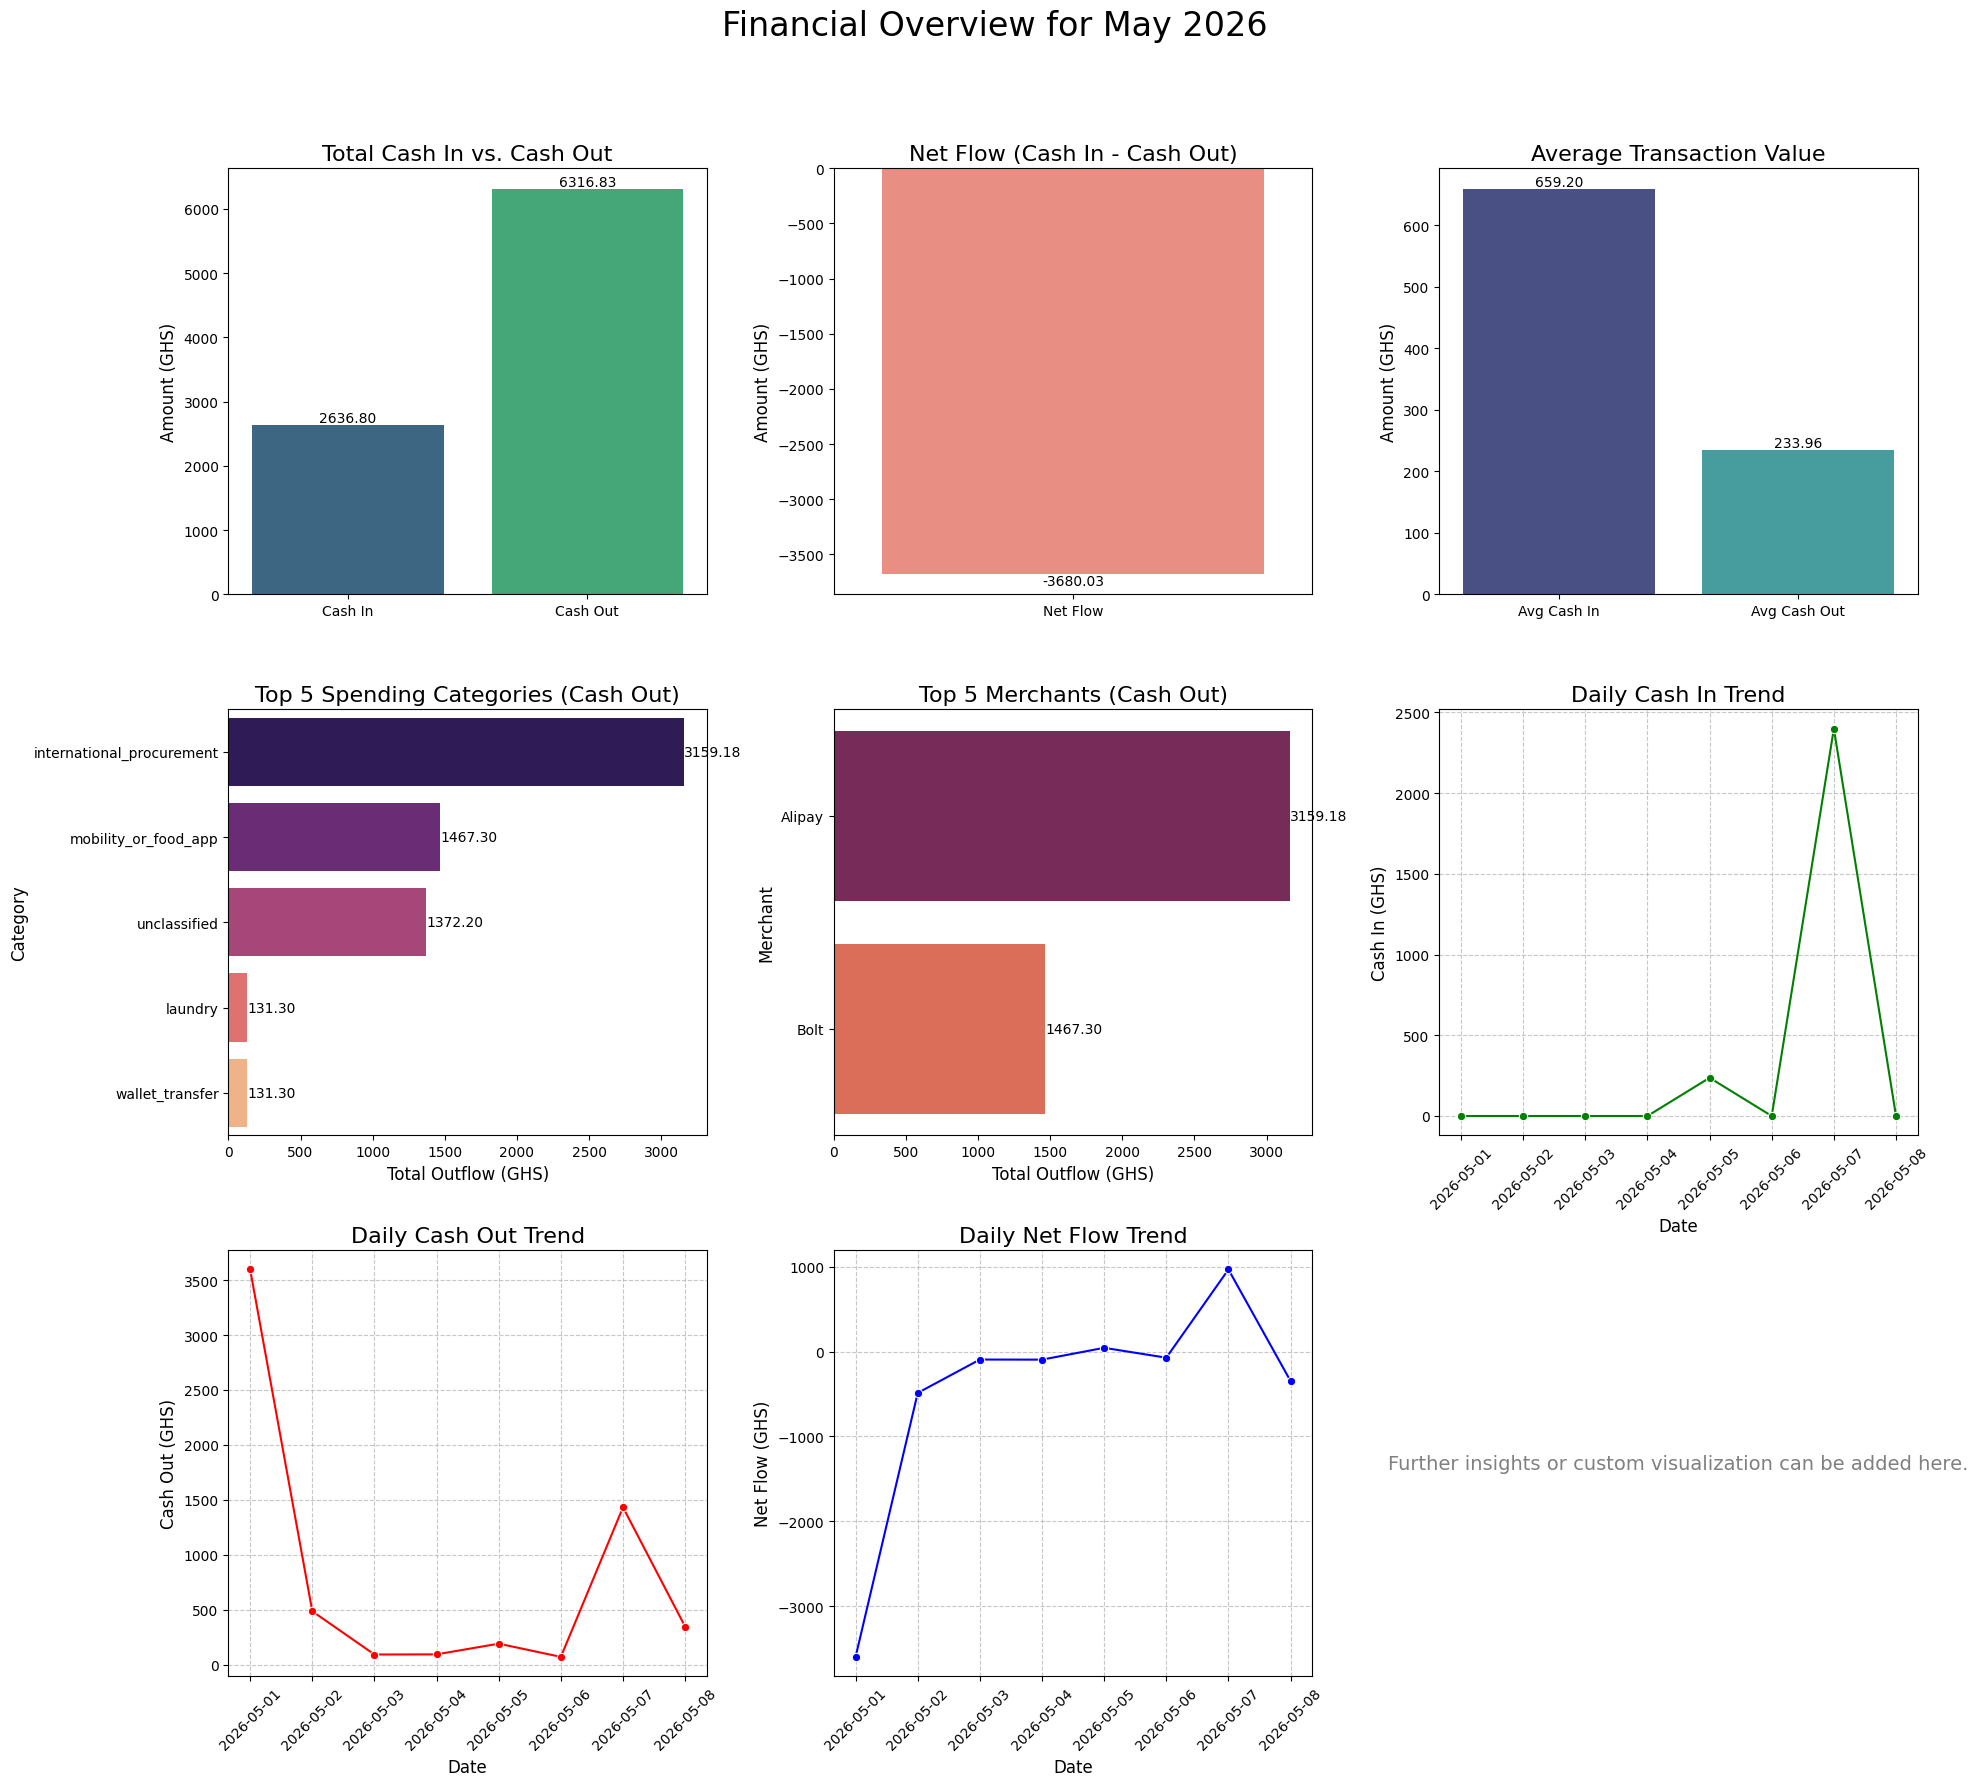

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for daily trends
daily_summary = current_month_df.groupby(current_month_df['transaction_datetime'].dt.date).agg(
    daily_cash_in=('amount_ghs', lambda x: x[current_month_df['direction'] == 'cash_in'].sum()),
    daily_cash_out=('total_outflow_ghs', lambda x: x[current_month_df['direction'] == 'cash_out'].sum())
).fillna(0).reset_index()
daily_summary['daily_net_flow'] = daily_summary['daily_cash_in'] - daily_summary['daily_cash_out']
daily_summary.rename(columns={'transaction_datetime': 'date'}, inplace=True)

# Create a 3x3 grid for plots
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f'Financial Overview for {datetime.now().strftime("%B %Y")}', fontsize=24, y=1.02)

# Plot 1: Total Cash In vs. Total Cash Out
ax = axes[0, 0]
sns.barplot(x=['Cash In', 'Cash Out'], y=[total_cash_in, total_cash_out], ax=ax, palette='viridis')
ax.set_title('Total Cash In vs. Cash Out', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 2: Net Flow
ax = axes[0, 1]
sns.barplot(x=['Net Flow'], y=[net_flow], ax=ax, palette=['salmon' if net_flow < 0 else 'lightgreen'])
ax.set_title('Net Flow (Cash In - Cash Out)', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 3: Average Cash In vs. Cash Out Transaction
ax = axes[0, 2]
sns.barplot(x=['Avg Cash In', 'Avg Cash Out'], y=[avg_cash_in, avg_cash_out], ax=ax, palette='mako')
ax.set_title('Average Transaction Value', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 4: Top 5 Spending Categories (Cash Out)
ax = axes[1, 0]
sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax, palette='magma')
ax.set_title('Top 5 Spending Categories (Cash Out)', fontsize=16)
ax.set_xlabel('Total Outflow (GHS)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 5: Top 5 Merchants (Cash Out)
ax = axes[1, 1]
sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=ax, palette='rocket')
ax.set_title('Top 5 Merchants (Cash Out)', fontsize=16)
ax.set_xlabel('Total Outflow (GHS)', fontsize=12)
ax.set_ylabel('Merchant', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 6: Daily Cash In Trend
ax = axes[1, 2]
sns.lineplot(x='date', y='daily_cash_in', data=daily_summary, marker='o', ax=ax, color='green')
ax.set_title('Daily Cash In Trend', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cash In (GHS)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)

# Plot 7: Daily Cash Out Trend
ax = axes[2, 0]
sns.lineplot(x='date', y='daily_cash_out', data=daily_summary, marker='o', ax=ax, color='red')
ax.set_title('Daily Cash Out Trend', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cash Out (GHS)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)

# Plot 8: Daily Net Flow Trend
ax = axes[2, 1]
sns.lineplot(x='date', y='daily_net_flow', data=daily_summary, marker='o', ax=ax, color='blue')
ax.set_title('Daily Net Flow Trend', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Net Flow (GHS)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)

# Plot 9: Placeholder (if no more specific data, can be left blank or used for overall summary text)
ax = axes[2, 2]
ax.text(0.5, 0.5, 'Further insights or custom visualization can be added here.', horizontalalignment='center', verticalalignment='center', fontsize=14, transform=ax.transAxes, color='gray')
ax.axis('off') # Hide axes for the placeholder

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## Today's Financial Statistics

In [4]:
import gspread
from google.colab import auth
from google.auth import default
from gspread_dataframe import get_as_dataframe
import pandas as pd
from datetime import datetime

# ------------------------------------------------
# 1. INPUT
# ------------------------------------------------
SSOT_GSHEET_URL = "https://docs.google.com/spreadsheets/d/1k4toaIWRj9oUDoXvdqsZQhLl0TgPRCHDY1doJPWjAEA/edit?gid=597024667#gid=597024667"
SOURCE_TAB = "unified_transactions_v1"

# ------------------------------------------------
# 2. AUTHORIZE
# ------------------------------------------------
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open_by_url(SSOT_GSHEET_URL)

# ------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------
ws = sh.worksheet(SOURCE_TAB)
df = get_as_dataframe(ws, evaluate_formulas=True, header=0, dtype=str)
df = df.dropna(how="all").copy()
df.columns = [str(c).strip().lower() for c in df.columns]

# ------------------------------------------------
# 4. CLEAN TYPES AND FILTER FOR TODAY'S TRANSACTIONS
# ------------------------------------------------
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"], errors="coerce")

today = datetime.now().date()
today_df = df[df["transaction_datetime"].dt.date == today].copy()

# Convert relevant columns to numeric
today_df['total_outflow_ghs'] = pd.to_numeric(today_df['total_outflow_ghs'], errors='coerce').fillna(0)
today_df['amount_ghs'] = pd.to_numeric(today_df['amount_ghs'], errors='coerce').fillna(0)
today_df['fees_ghs'] = pd.to_numeric(today_df['fees_ghs'], errors='coerce').fillna(0)

print(f"Transactions for today ({today.strftime('%Y-%m-%d')}):")
display(today_df)

print("\n--- Detailed Statistics for Today ---")

total_cash_in = today_df[today_df['direction'] == 'cash_in']['amount_ghs'].sum()
total_cash_out = today_df[today_df['direction'] == 'cash_out']['total_outflow_ghs'].sum()
net_flow = total_cash_in - total_cash_out

print(f"Total Cash In: GHS {total_cash_in:,.2f}")
print(f"Total Cash Out: GHS {total_cash_out:,.2f}")
print(f"Net Flow (Cash In - Cash Out): GHS {net_flow:,.2f}")

avg_cash_in = today_df[today_df['direction'] == 'cash_in']['amount_ghs'].mean()
avg_cash_out = today_df[today_df['direction'] == 'cash_out']['total_outflow_ghs'].mean()

print(f"Average Cash In Transaction: GHS {avg_cash_in:,.2f}")
print(f"Average Cash Out Transaction: GHS {avg_cash_out:,.2f}")

print("\nTop 5 Spending Categories (Cash Out):")
top_categories = today_df[today_df['direction'] == 'cash_out'].groupby('category_hint')['total_outflow_ghs'].sum().nlargest(5)
display(top_categories)

print("\nTop 5 Merchants (Cash Out):")
top_merchants = today_df[today_df['direction'] == 'cash_out'].groupby('merchant_hint')['total_outflow_ghs'].sum().nlargest(5)
display(top_merchants)

# Prepare data for daily trends (using today's data for consistency, though it's a single day)
daily_summary_today = today_df.groupby(today_df['transaction_datetime'].dt.date).agg(
    daily_cash_in=('amount_ghs', lambda x: x[today_df['direction'] == 'cash_in'].sum()),
    daily_cash_out=('total_outflow_ghs', lambda x: x[today_df['direction'] == 'cash_out'].sum())
).fillna(0).reset_index()
daily_summary_today['daily_net_flow'] = daily_summary_today['daily_cash_in'] - daily_summary_today['daily_cash_out']
daily_summary_today.rename(columns={'transaction_datetime': 'date'}, inplace=True)

Transactions for today (2026-05-09):


,transaction_id,transaction_datetime,email_date,institution,source_channel,source_sheet,direction,amount_ghs,fees_ghs,elevy_ghs,...,description,reference,counterparty_name,counterparty_phone,merchant_hint,category_hint,balance_after_ghs,raw_body,link_type,link_id



--- Detailed Statistics for Today ---
Total Cash In: GHS 0.00
Total Cash Out: GHS 0.00
Net Flow (Cash In - Cash Out): GHS 0.00
Average Cash In Transaction: GHS nan
Average Cash Out Transaction: GHS nan

Top 5 Spending Categories (Cash Out):


,total_outflow_ghs
category_hint,



Top 5 Merchants (Cash Out):


,total_outflow_ghs
merchant_hint,


/tmp/ipykernel_5886/418886491.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Cash In', 'Cash Out'], y=[total_cash_in, total_cash_out], ax=ax, palette='viridis')
/tmp/ipykernel_5886/418886491.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Net Flow'], y=[net_flow], ax=ax, palette=['salmon' if net_flow < 0 else 'lightgreen'])
/tmp/ipykernel_5886/418886491.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Avg Cash In', 'Avg Cash Out'], y=[avg_cash_in, avg_cash_out], ax=ax, palette='mako')


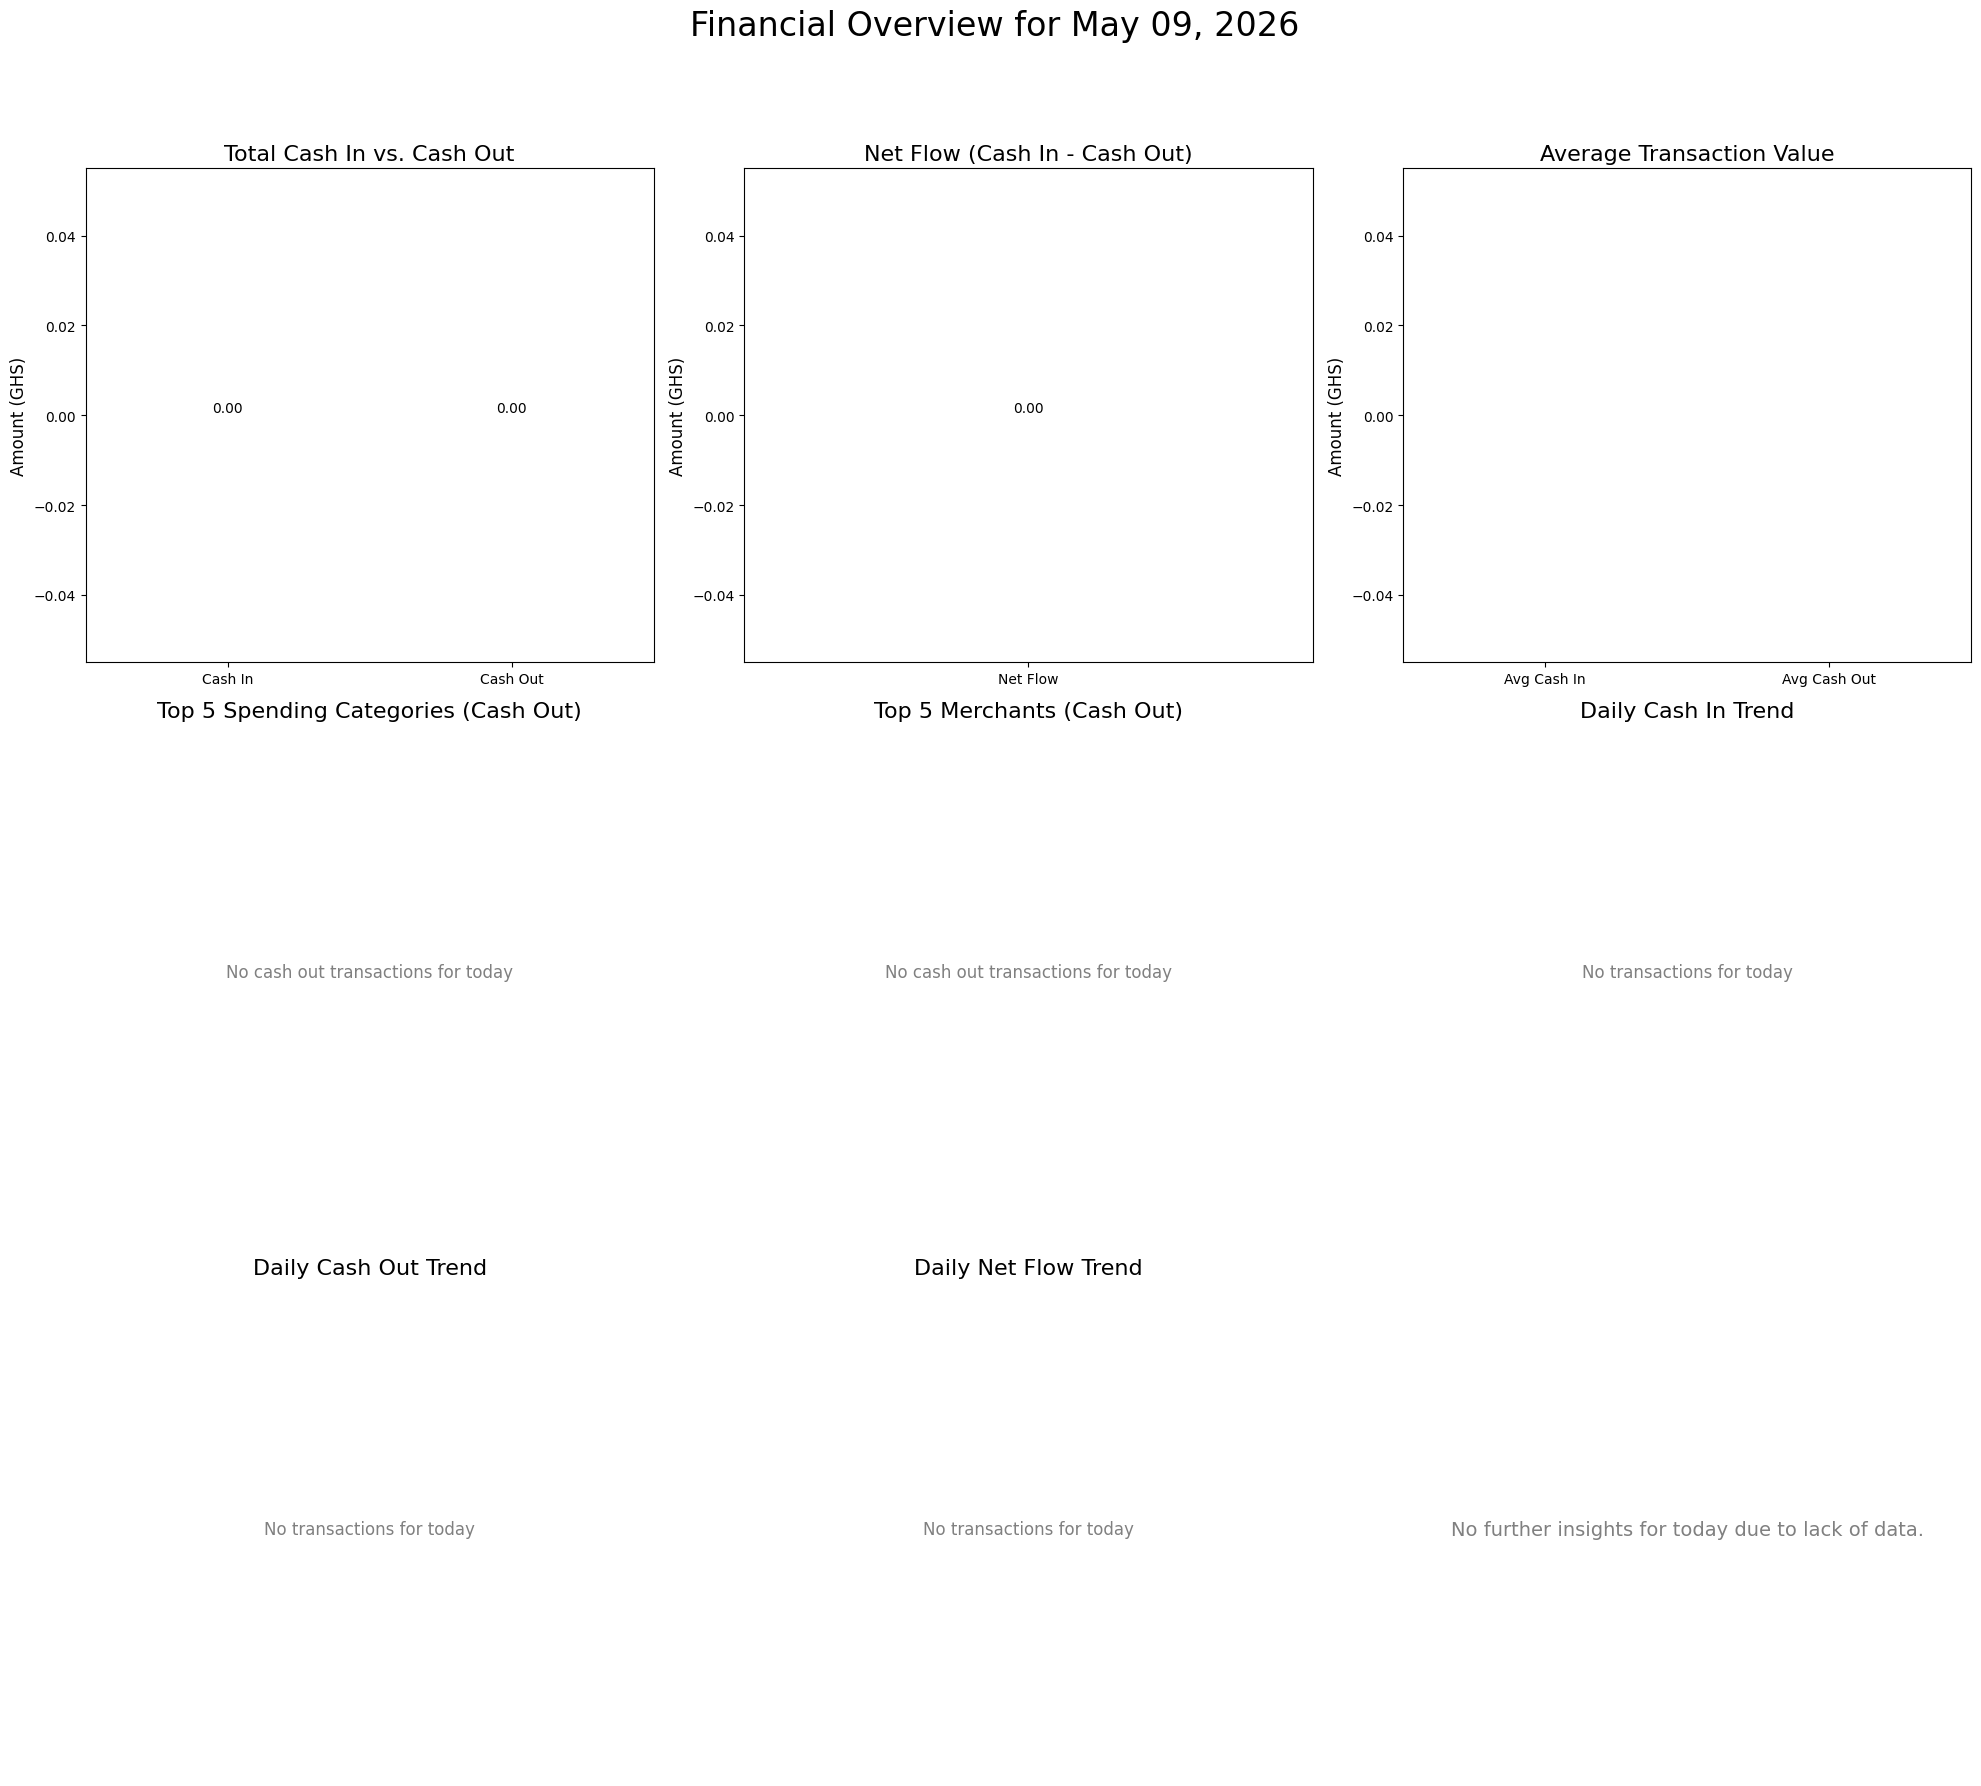

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 3x3 grid for plots
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f'Financial Overview for {today.strftime("%B %d, %Y")}', fontsize=24, y=1.02)

# Plot 1: Total Cash In vs. Total Cash Out
ax = axes[0, 0]
sns.barplot(x=['Cash In', 'Cash Out'], y=[total_cash_in, total_cash_out], ax=ax, palette='viridis')
ax.set_title('Total Cash In vs. Cash Out', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 2: Net Flow
ax = axes[0, 1]
sns.barplot(x=['Net Flow'], y=[net_flow], ax=ax, palette=['salmon' if net_flow < 0 else 'lightgreen'])
ax.set_title('Net Flow (Cash In - Cash Out)', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 3: Average Cash In vs. Cash Out Transaction
ax = axes[0, 2]
sns.barplot(x=['Avg Cash In', 'Avg Cash Out'], y=[avg_cash_in, avg_cash_out], ax=ax, palette='mako')
ax.set_title('Average Transaction Value', fontsize=16)
ax.set_ylabel('Amount (GHS)', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

# Plot 4: Top 5 Spending Categories (Cash Out)
ax = axes[1, 0]
if not top_categories.empty:
    sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax, palette='magma')
    ax.set_title('Top 5 Spending Categories (Cash Out)', fontsize=16)
    ax.set_xlabel('Total Outflow (GHS)', fontsize=12)
    ax.set_ylabel('Category', fontsize=12)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No cash out transactions for today', horizontalalignment='center', verticalalignment='center', fontsize=12, color='gray', transform=ax.transAxes)
    ax.set_title('Top 5 Spending Categories (Cash Out)', fontsize=16)
    ax.axis('off')

# Plot 5: Top 5 Merchants (Cash Out)
ax = axes[1, 1]
if not top_merchants.empty:
    sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=ax, palette='rocket')
    ax.set_title('Top 5 Merchants (Cash Out)', fontsize=16)
    ax.set_xlabel('Total Outflow (GHS)', fontsize=12)
    ax.set_ylabel('Merchant', fontsize=12)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No cash out transactions for today', horizontalalignment='center', verticalalignment='center', fontsize=12, color='gray', transform=ax.transAxes)
    ax.set_title('Top 5 Merchants (Cash Out)', fontsize=16)
    ax.axis('off')

# Plot 6: Daily Cash In Trend (using daily_summary_today)
ax = axes[1, 2]
if not daily_summary_today.empty:
    sns.lineplot(x='date', y='daily_cash_in', data=daily_summary_today, marker='o', ax=ax, color='green')
    ax.set_title('Daily Cash In Trend', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cash In (GHS)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)
else:
    ax.text(0.5, 0.5, 'No transactions for today', horizontalalignment='center', verticalalignment='center', fontsize=12, color='gray', transform=ax.transAxes)
    ax.set_title('Daily Cash In Trend', fontsize=16)
    ax.axis('off')

# Plot 7: Daily Cash Out Trend (using daily_summary_today)
ax = axes[2, 0]
if not daily_summary_today.empty:
    sns.lineplot(x='date', y='daily_cash_out', data=daily_summary_today, marker='o', ax=ax, color='red')
    ax.set_title('Daily Cash Out Trend', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cash Out (GHS)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)
else:
    ax.text(0.5, 0.5, 'No transactions for today', horizontalalignment='center', verticalalignment='center', fontsize=12, color='gray', transform=ax.transAxes)
    ax.set_title('Daily Cash Out Trend', fontsize=16)
    ax.axis('off')

# Plot 8: Daily Net Flow Trend (using daily_summary_today)
ax = axes[2, 1]
if not daily_summary_today.empty:
    sns.lineplot(x='date', y='daily_net_flow', data=daily_summary_today, marker='o', ax=ax, color='blue')
    ax.set_title('Daily Net Flow Trend', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Net Flow (GHS)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)
else:
    ax.text(0.5, 0.5, 'No transactions for today', horizontalalignment='center', verticalalignment='center', fontsize=12, color='gray', transform=ax.transAxes)
    ax.set_title('Daily Net Flow Trend', fontsize=16)
    ax.axis('off')

# Plot 9: Placeholder
ax = axes[2, 2]
ax.text(0.5, 0.5, 'No further insights for today due to lack of data.', horizontalalignment='center', verticalalignment='center', fontsize=14, transform=ax.transAxes, color='gray')
ax.axis('off') # Hide axes for the placeholder

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()